## Load Data

### load package and data

In [8]:
import sys
sys.path.append('/Users/shiyihe/Desktop/ANALYSIS_SCRIPTS')

from data_processor import (
    load_all_data,
    extract_reading_tasks,
    extract_writing_nl_tasks,
    extract_modifying_tasks,
    extract_writing_tasks,
    aggregate_tasks_with_format,
    extract_post_task_questions,
    analyze_nasa_and_post_surveys,
    melt_tlx,
    aggregate_quiz_parts,
    summarize_quiz_parts,
    evaluate_quiz_answers_from_tutorial,
    extract_and_encode_familiarity,
    get_answer_counts,
    plot_answer_distribution,
    extract_survey_items,
    extract_post_task_tlx_responses,
    merge_dfs
)

from time_analysis import (
    time_analysis,
    normalize_typing_time,
    compute_task_time_ratio,
    get_task_group,
    compute_avg_ratio,
    plot_stacked_ratio
)



from statistic import (
    compare_statistically,
    vis_violin_comparison,
    compare_significant_pairs,
    vis_box_comparasion)

from correctness_analysis import (
    annotate_reading_correctness_exact,
    visualize_accuracy_heatmap,
    visualize_score_distribution_heatmap,
    plot_binary_response_vs_metric_heatmap,
    plot_nasatlx_correct,
    plot_time_vs_response_heatmap,
    plot_duration_vs_correct_with_stats
)


from format_check import (
    process_dataframe_with_validation,
    add_overall_rows)


Total number of valid participants: 107


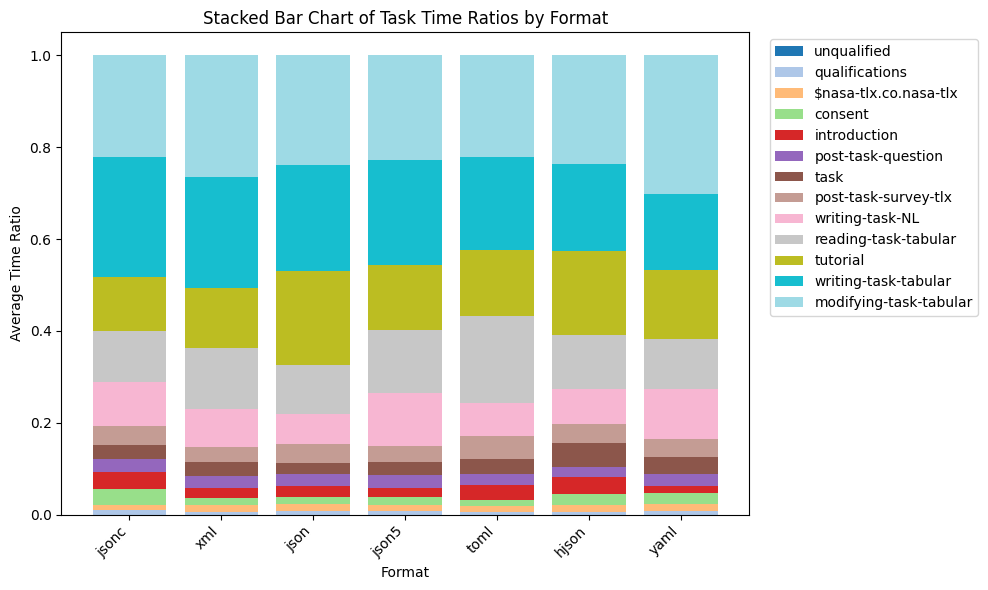

In [9]:
folder = '/Users/shiyihe/Desktop/ANALYSIS_SCRIPT/tabular'
all_data = load_all_data(folder, ignore_completed=True)
df_task, df_part, format_stat= time_analysis(all_data)
df_writing_nl = extract_writing_nl_tasks(all_data)
df_writing = extract_writing_tasks(all_data)
df_modifying = extract_modifying_tasks(all_data)
df_reading = extract_reading_tasks(all_data)
df_ratio_writing, df_format_avg_ratio = compute_task_time_ratio(df_part, df_writing)
df_writing_norm = normalize_typing_time(df_writing_nl, df_writing, keep_baseline=False)
df_ratio, wide_avg = compute_avg_ratio(df_task, tasks=None)
fig, ax = plot_stacked_ratio(
    wide_avg,
    sort_formats_by='writing-task-tabular',
    stack_order_by='json'
)


In [10]:
format_stat

format
json     17
hjson    16
json5    15
yaml     15
toml     15
jsonc    15
xml      14
Name: count, dtype: int64

### writing time ratio 

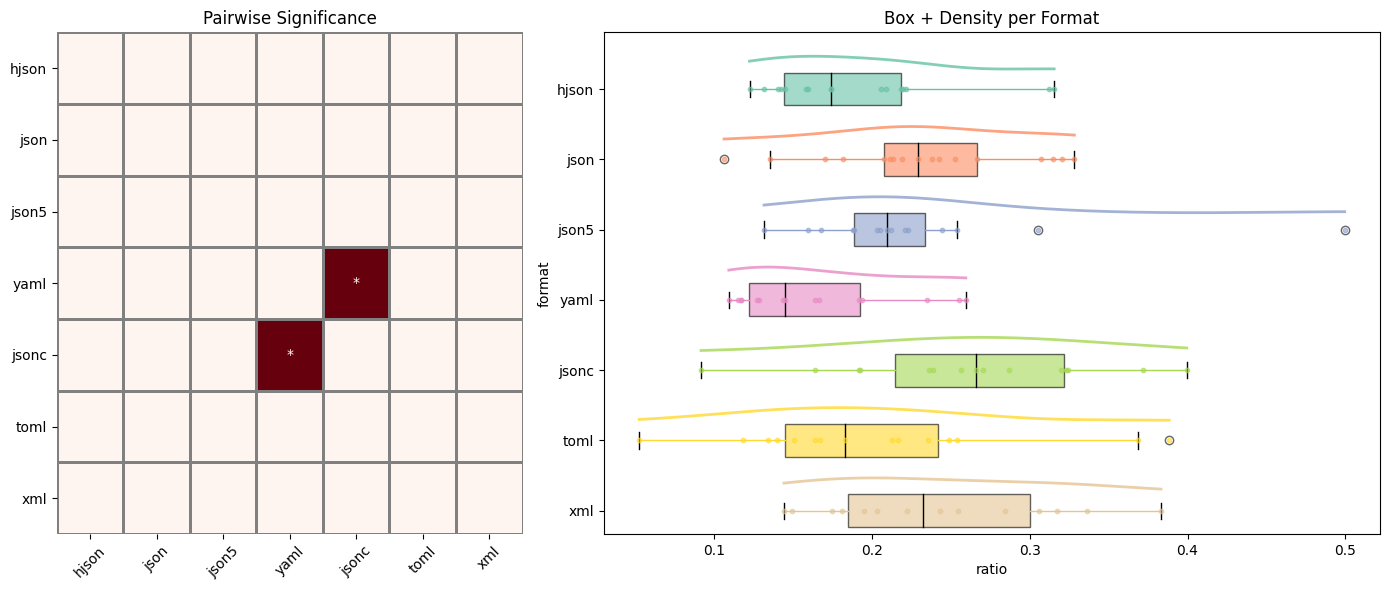

In [11]:
vis_box_comparasion(
    df_ratio_writing,
    group_col='format',
    value_col='ratio',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)

ModuleNotFoundError: No module named 'ptitprince'

## Time Analysis

### writing

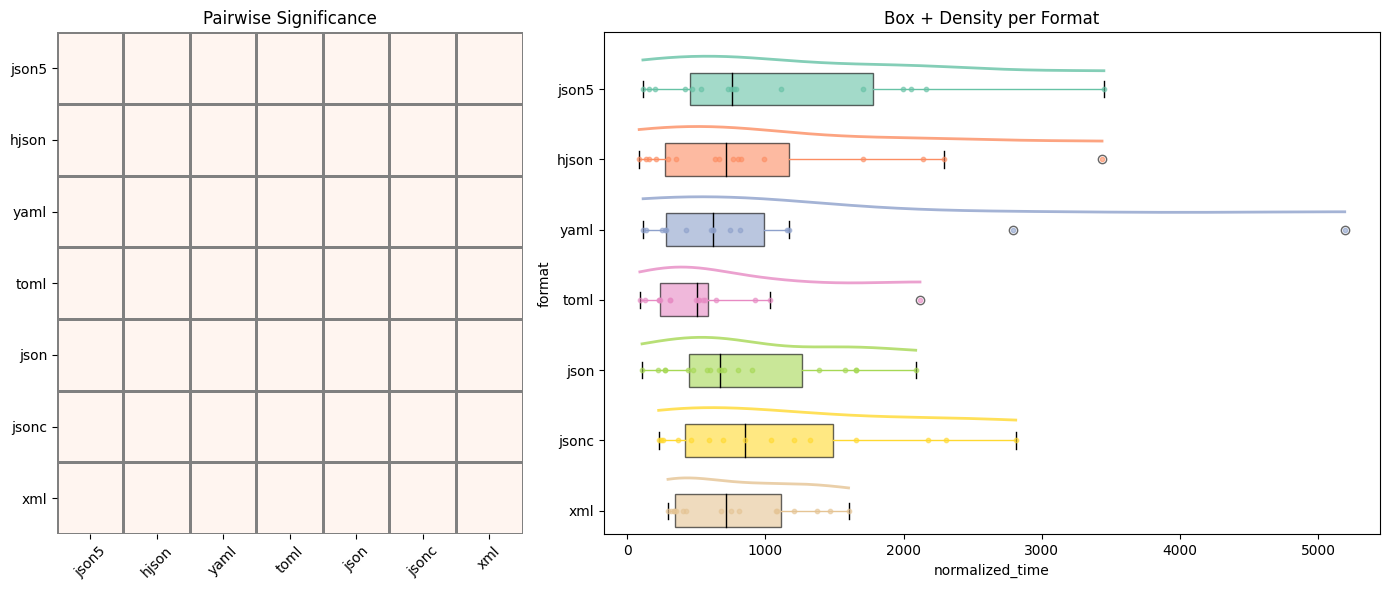

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count         mean          std      median         min          max
 format                                                                      
 hjson      16   968.901520   951.510081  714.579899   86.511038  3436.390655
 json       18   838.105560   583.372827  672.595905  107.249734  2087.991110
 json5      16  1088.765112   932.167337  761.052172  113.520269  3449.811245
 jsonc      15  1080.743229   825.343966  849.303868  227.517860  2811.811924
 toml       16   556.210254   493.752340  504.206151   91.407111  2118.917651
 xml        16   782.313501   459.541965  714.336049  295.010644  1601.885347
 yaml       15  1013.558313  1332.013302  620.507137  114.999609  5193.004023,
 'overall_p': 0.5456770666882567,
 'effect_size': 0.04553285695785511,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning

In [4]:
## writing_task

vis_box_comparasion(
    df_writing_norm,
    group_col='format',
    value_col='normalized_time',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

w_time_results = compare_statistically(
    df_writing_norm,
    group_col='format',
    value_col='normalized_time',
    method='anova',
    task_col='task'
)


w_time_results

### reading

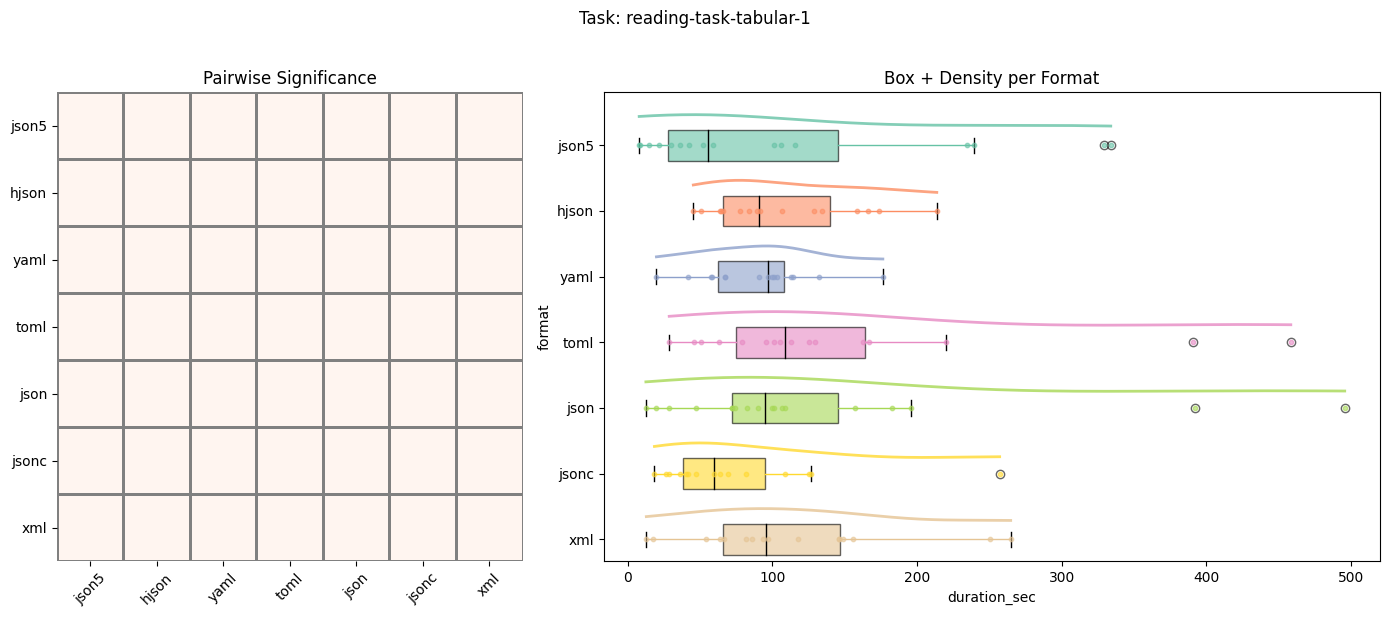

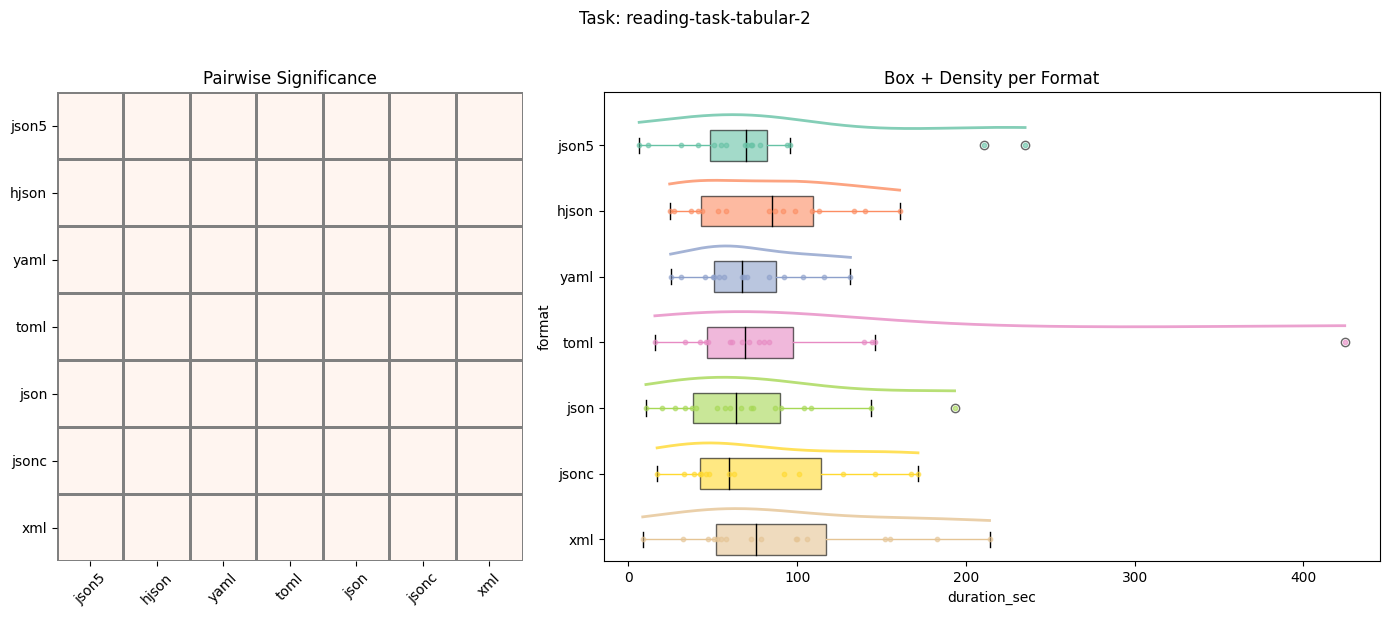

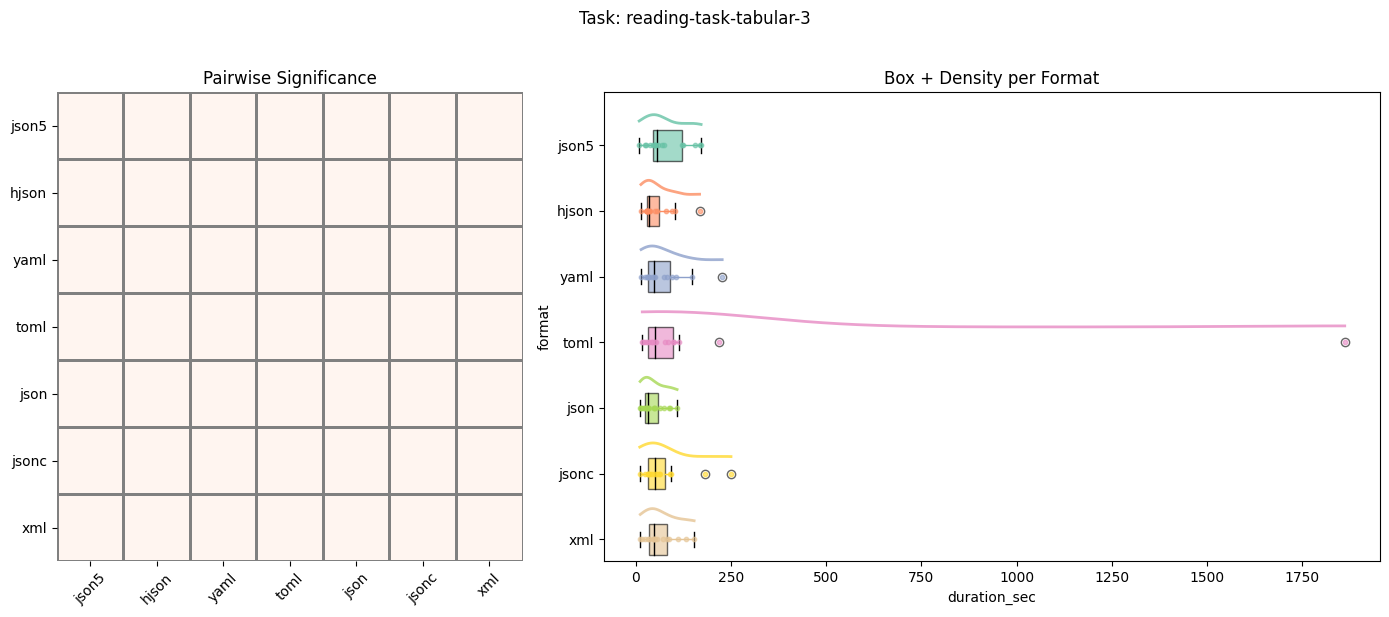

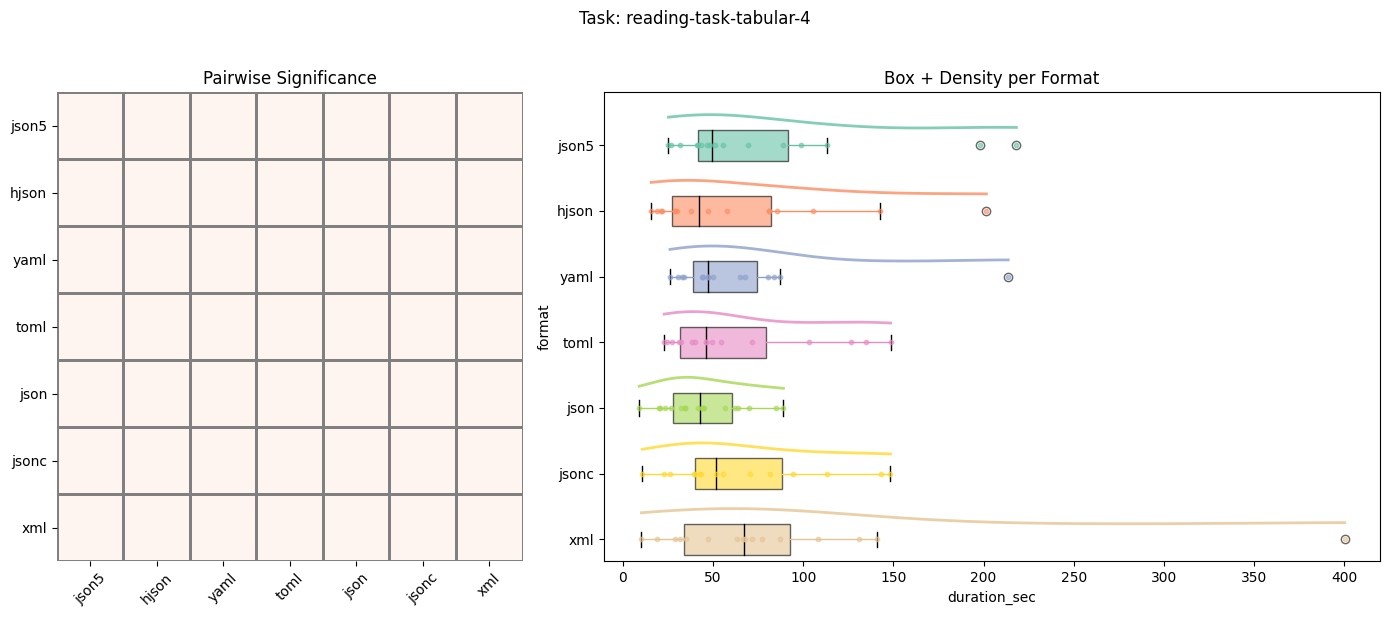

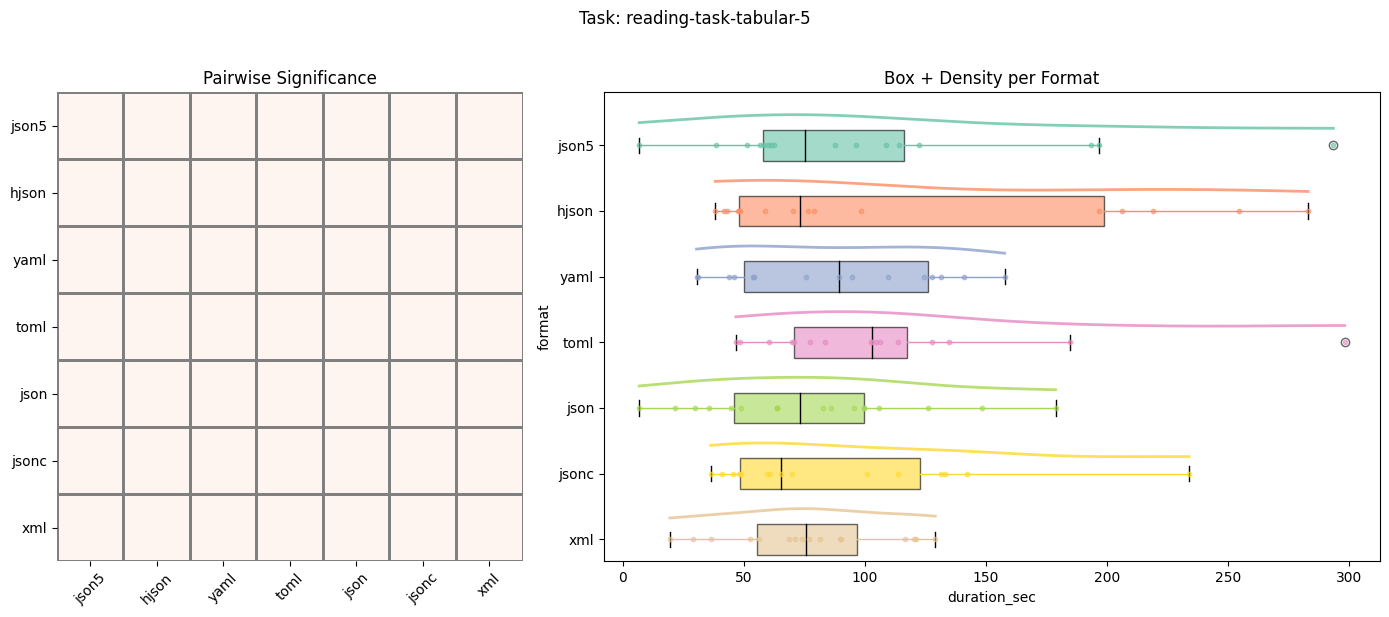

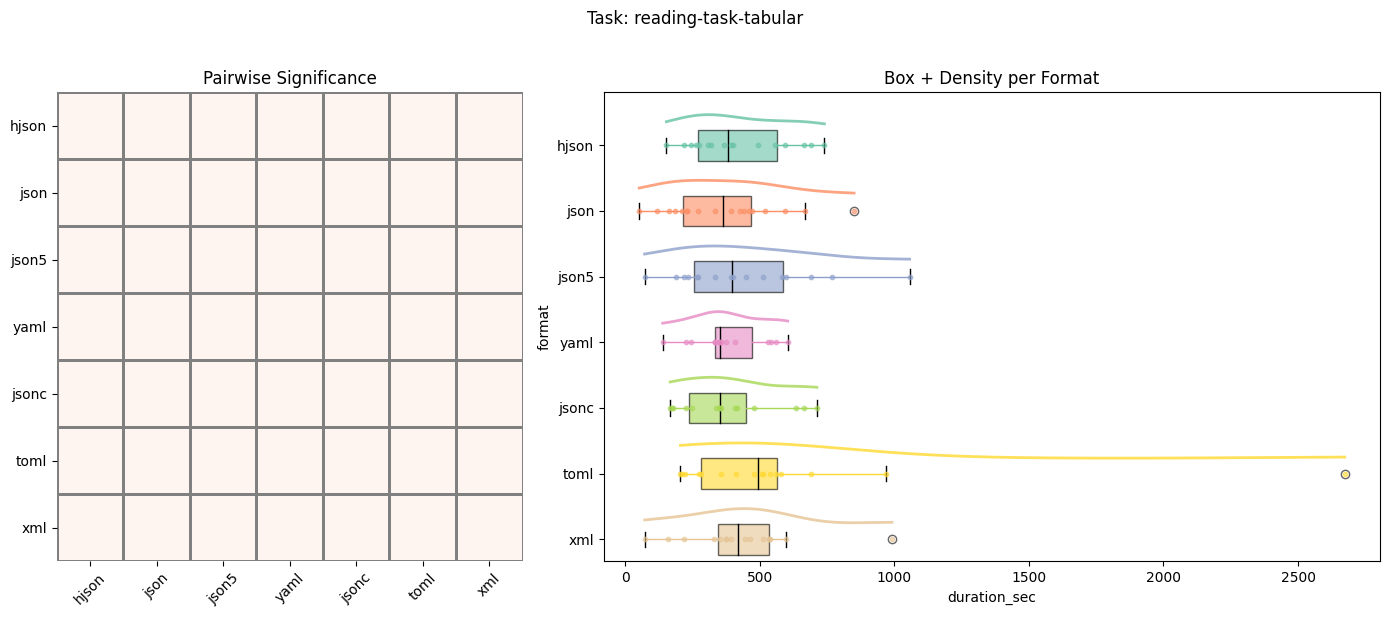

{'reading-task-tabular': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count        mean         std    median      min       max
  format                                                            
  hjson      16  417.607562  183.040753  380.6980  153.313   740.306
  json       18  368.143389  208.238761  363.4135   52.157   850.377
  json5      16  439.432125  253.782472  397.4835   72.253  1056.874
  jsonc      15  380.034467  177.984847  351.8110  167.403   712.323
  toml       16  592.323125  590.342260  493.0305  205.611  2673.430
  xml        16  430.848062  208.833953  419.9515   72.610   991.248
  yaml       15  379.617933  130.896014  353.0620  139.514   603.879,
  'overall_p': 0.3461701853343572,
  'effect_size': 0.061005852625329135,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'reading-task-tabular-1': {'method'

In [5]:
## reading tasks

df_reading_clean = aggregate_tasks_with_format(
    df_reading,
    participant_col='participantId',
    task_col='task',
    format_col = 'format',
    metrics=['duration_sec','help_count']
)

vis_box_comparasion(
    df_reading_clean,
    group_col='format',
    value_col='duration_sec',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['reading-task-tabular-1','reading-task-tabular-2','reading-task-tabular-3','reading-task-tabular-4', 'reading-task-tabular-5','reading-task-tabular']
)

r_time_results = compare_statistically(
    df_reading_clean,
    group_col='format',
    value_col='duration_sec',
    method='anova',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['reading-task-tabular-1','reading-task-tabular-2','reading-task-tabular-3','reading-task-tabular-4', 'reading-task-tabular-5','reading-task-tabular']
)

r_time_results


### modifying

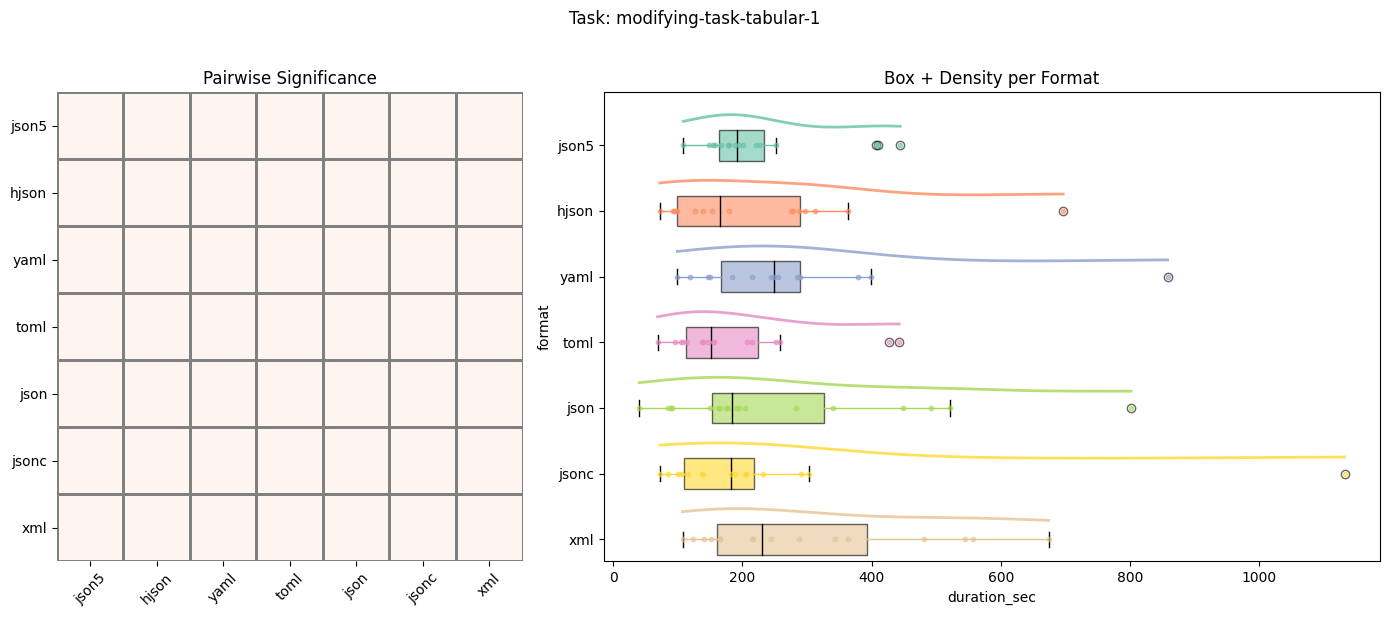

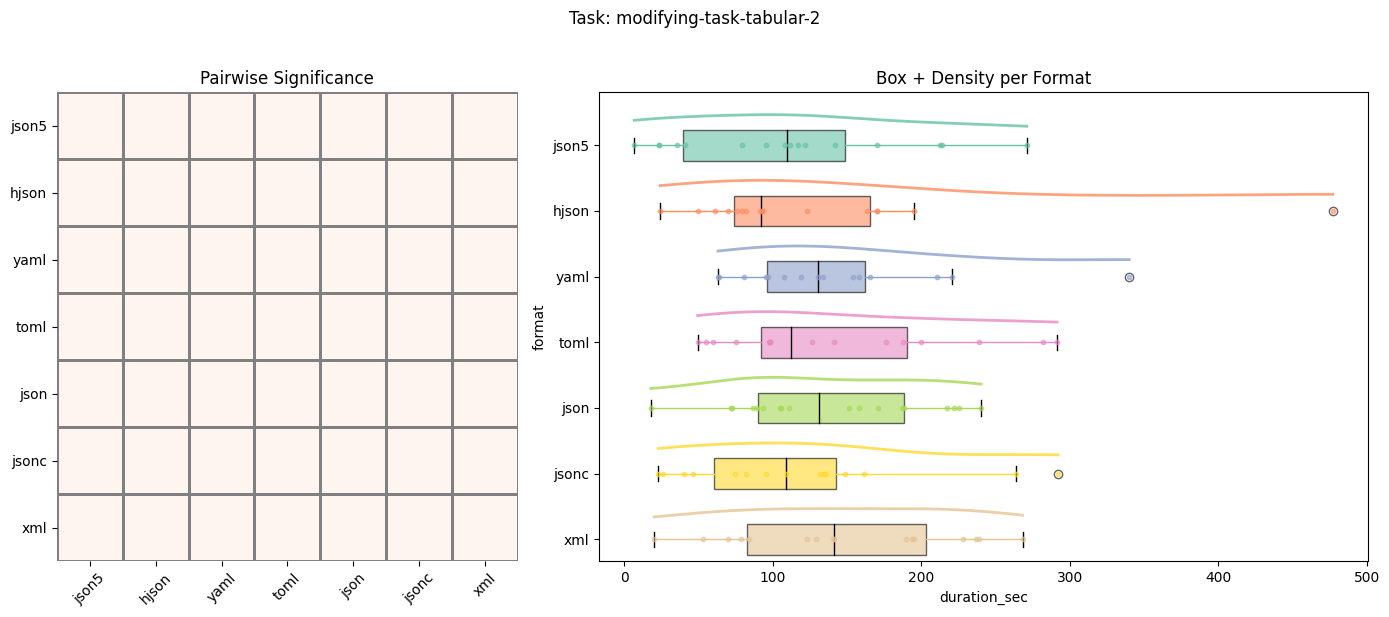

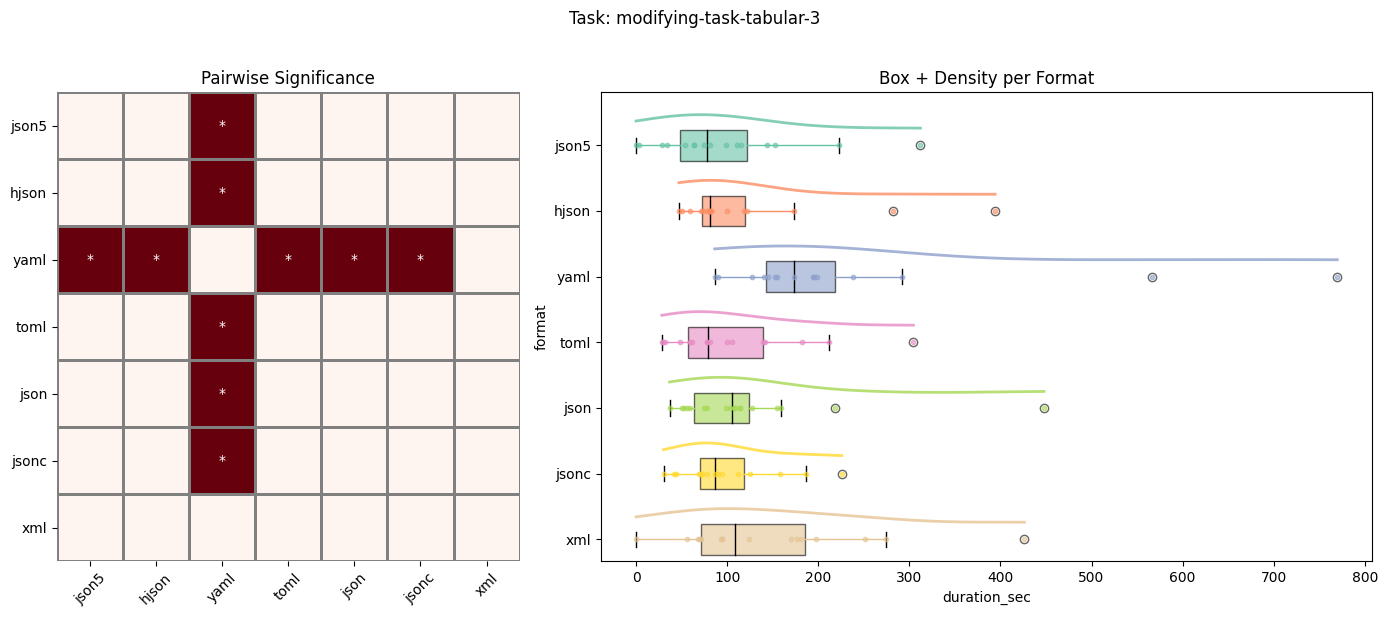

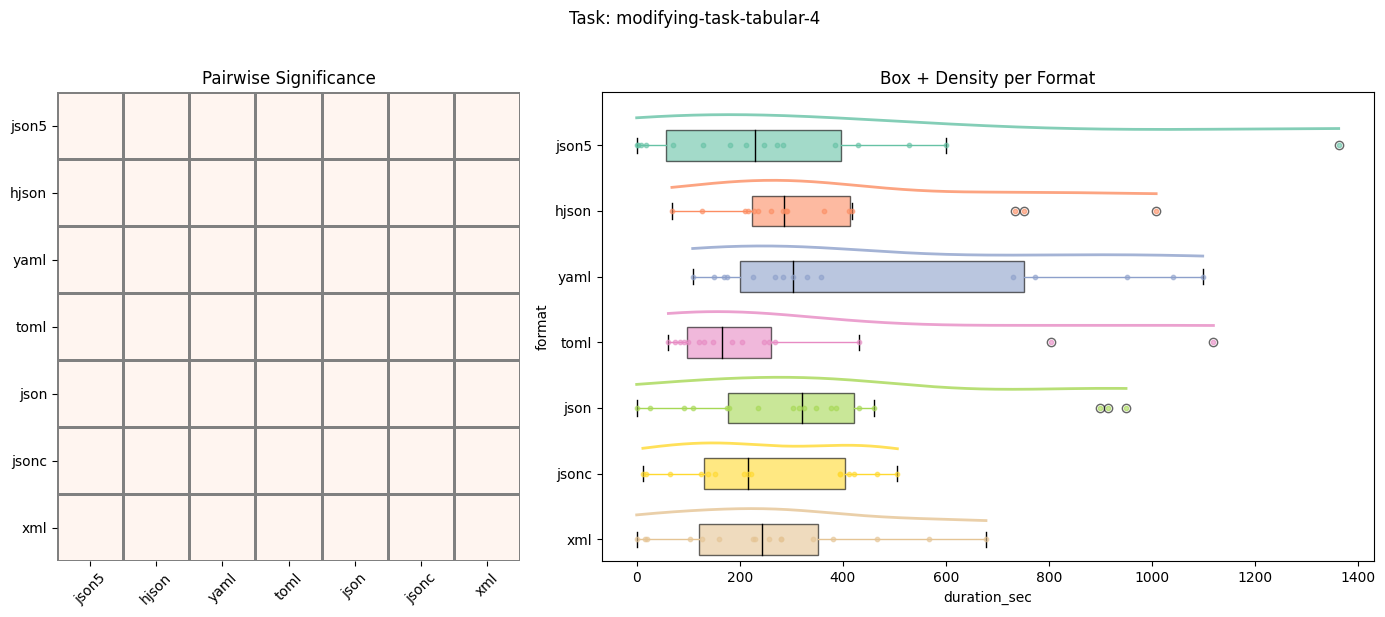

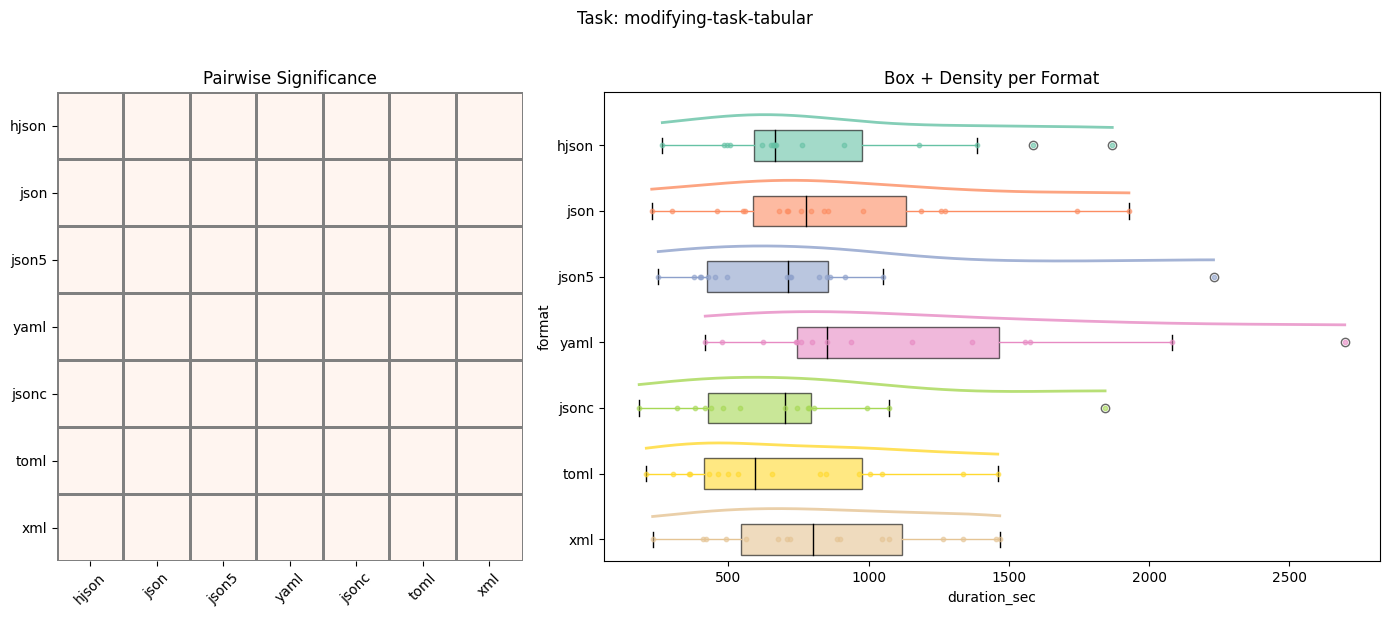

{'modifying-task-tabular': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count         mean         std    median      min       max
  format                                                             
  hjson      16   835.697250  442.286007  665.4905  264.638  1868.826
  json       18   878.715278  455.031505  777.4065  226.965  1928.169
  json5      16   730.929250  463.636810  713.8835  250.193  2229.780
  jsonc      15   699.356333  405.031533  703.7280  182.170  1843.204
  toml       16   706.814000  377.113480  596.2505  207.687  1460.563
  xml        16   852.876937  390.633979  803.6500  230.238  1467.659
  yaml       15  1119.221733  635.599273  850.1800  417.694  2697.613,
  'overall_p': 0.16709468554755036,
  'effect_size': 0.08169755538391493,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'modifying-task-tabular-

In [6]:
## modifying tasks
df_modifying_clean = aggregate_tasks_with_format(
    df_modifying,
    participant_col='participantId',
    task_col='task',
    format_col = 'format',
    metrics=['duration_sec','help_count']
)

vis_box_comparasion(
    df_modifying_clean,
    group_col='format',
    value_col='duration_sec',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['modifying-task-tabular-1','modifying-task-tabular-2','modifying-task-tabular-3','modifying-task-tabular-4', 'modifying-task-tabular']
)

m_time_results = compare_statistically(
    df_modifying_clean,
    group_col='format',
    value_col='duration_sec',
    method='anova',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['modifying-task-tabular-1','modifying-task-tabular-2','modifying-task-tabular-3','modifying-task-tabular-4', 'modifying-task-tabular']
)
    
m_time_results

## Help Button Clicks Analysis

### writing

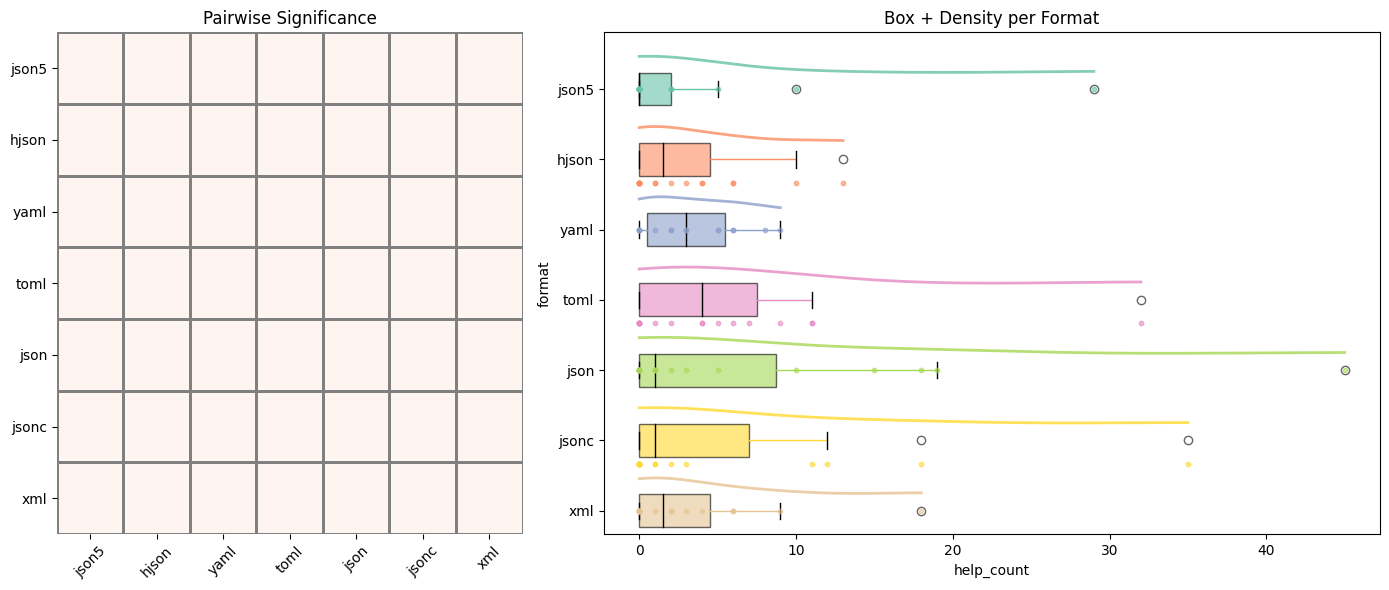

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean        std  median  min  max
 format                                              
 hjson      16  3.125000   3.930649     1.5    0   13
 json       18  6.666667  11.570754     1.0    0   45
 json5      16  3.000000   7.438638     0.0    0   29
 jsonc      15  5.533333   9.891314     1.0    0   35
 toml       16  5.750000   8.020806     4.0    0   32
 xml        16  3.187500   4.819665     1.5    0   18
 yaml       15  3.333333   3.015831     3.0    0    9,
 'overall_p': 0.6662021856811619,
 'effect_size': 0.03739611233194849,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [7]:
## writing_task

vis_box_comparasion(
    df_writing_norm,
    group_col='format',
    value_col='help_count',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)

w_hlep_results = compare_statistically(
    df_writing_norm,
    group_col='format',
    value_col='help_count',
    method='anova',
    task_col='task'
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)


w_hlep_results

### reading

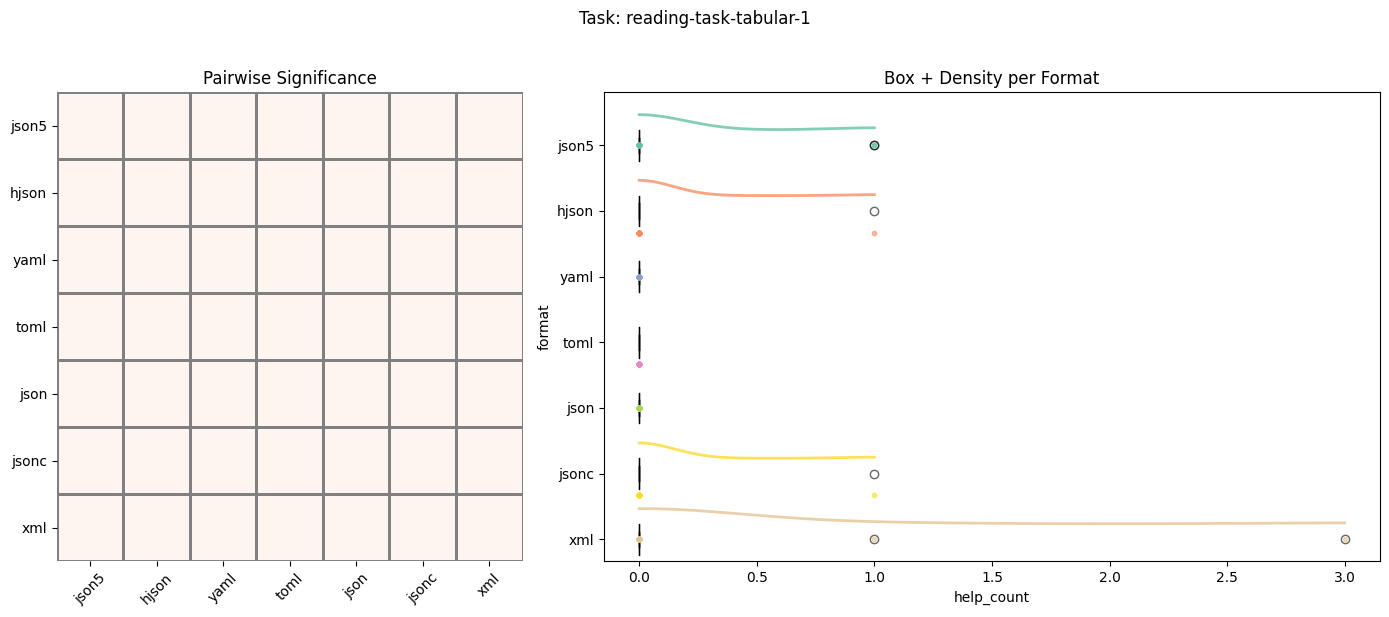

/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))


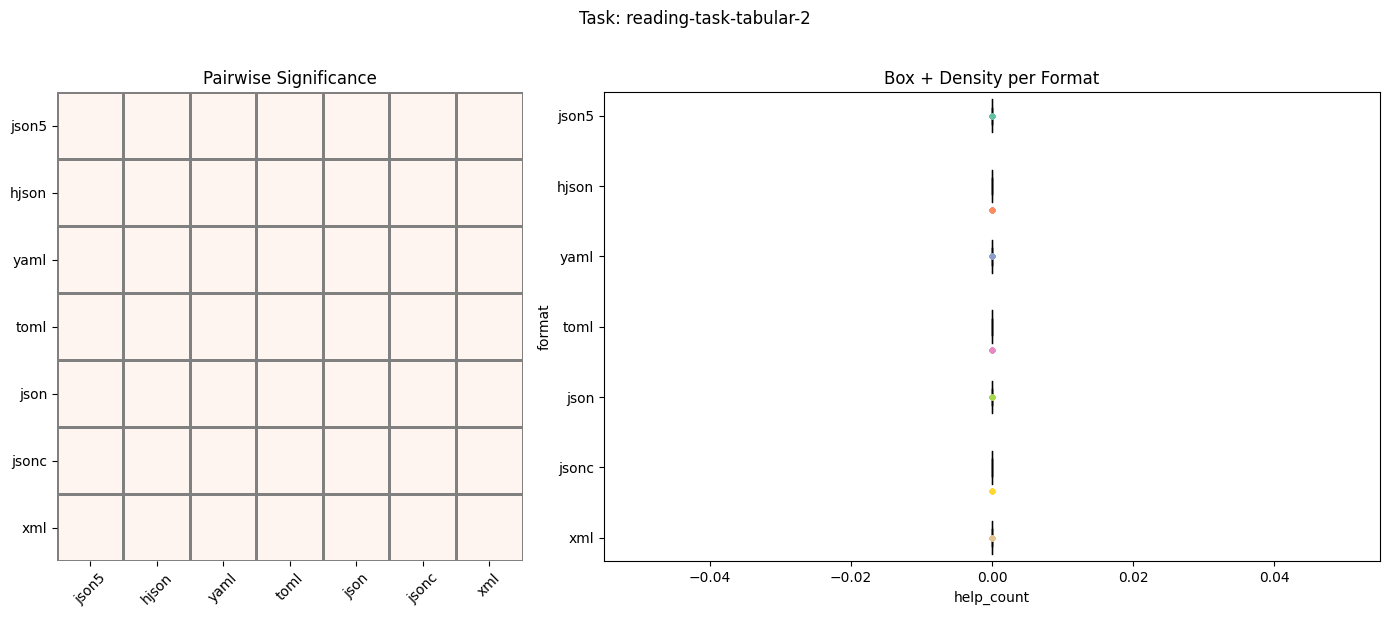

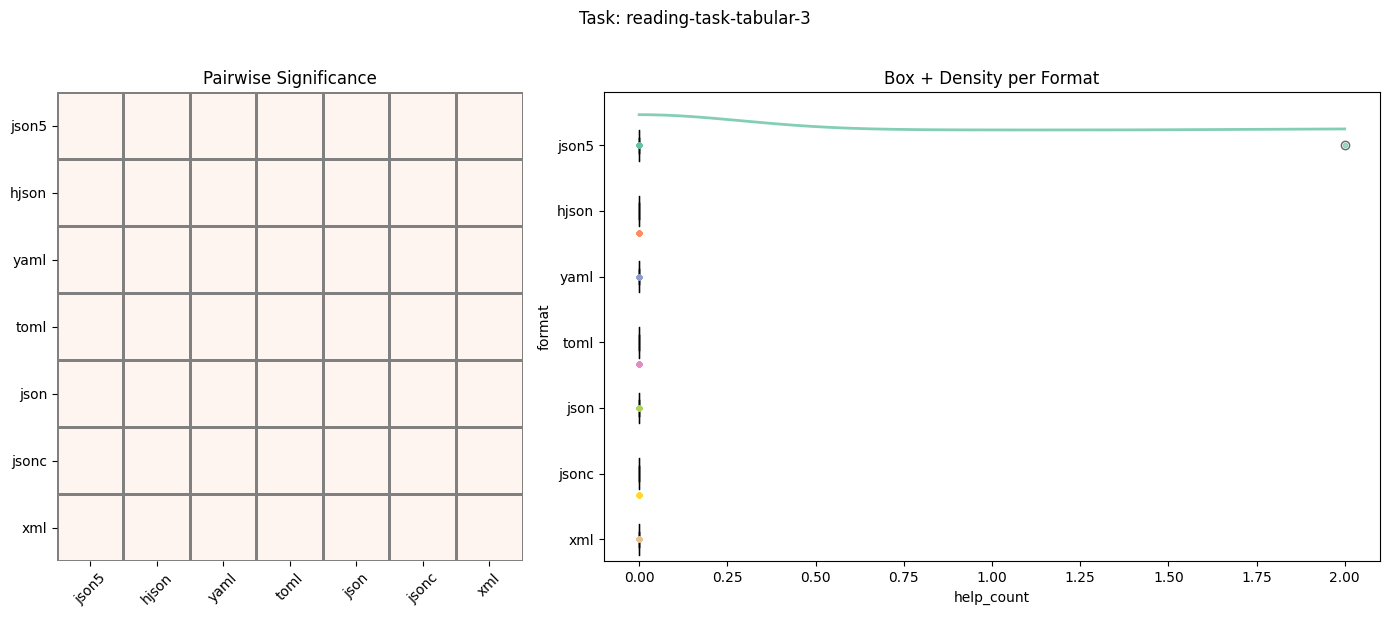

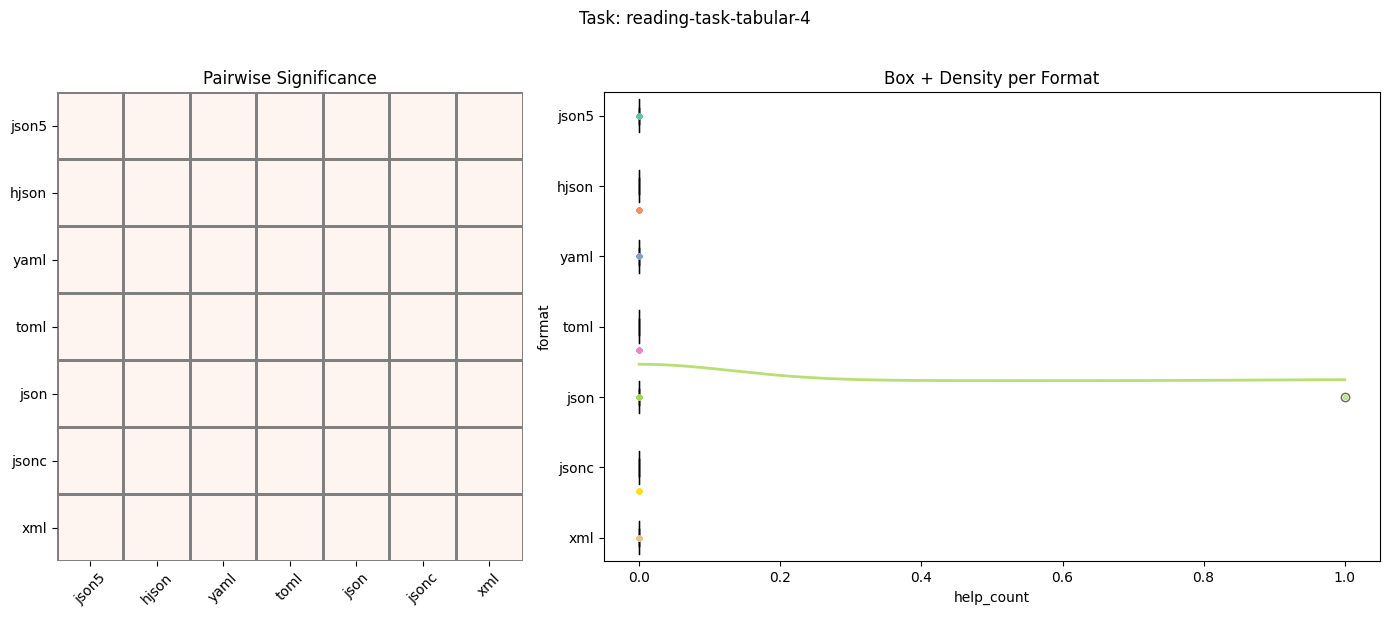

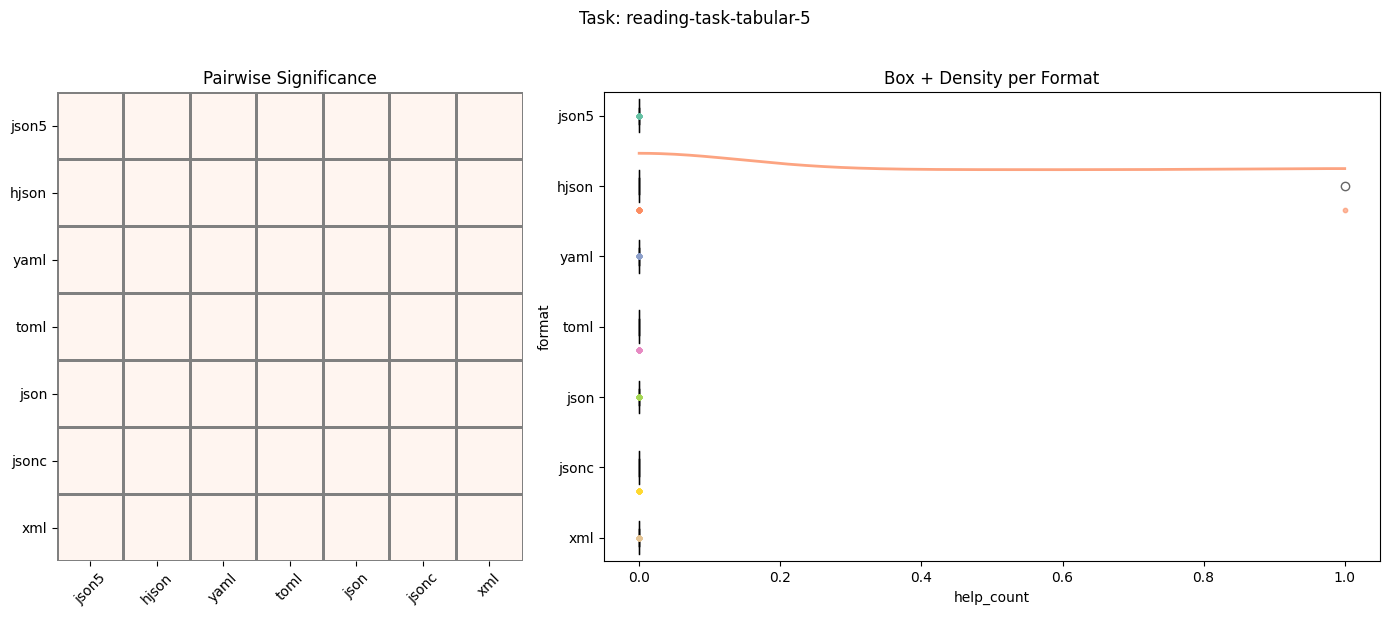

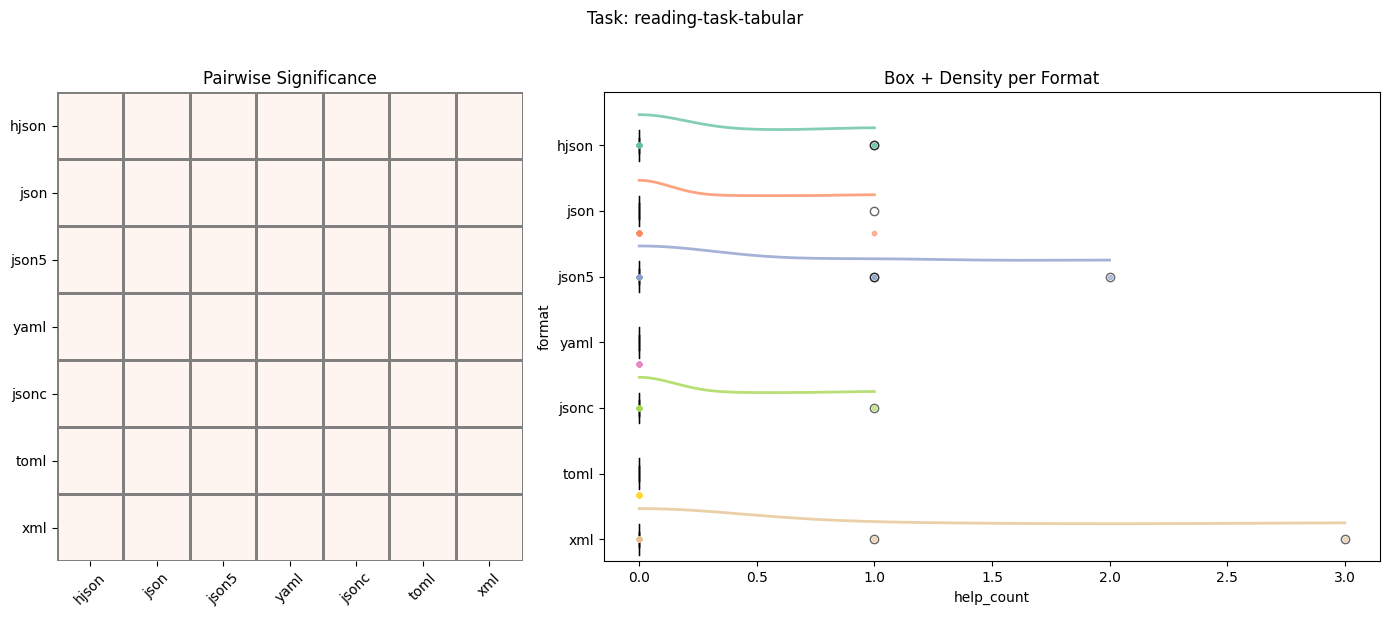

/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))


{'reading-task-tabular': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      16  0.125000  0.341565     0.0    0    1
  json       18  0.055556  0.235702     0.0    0    1
  json5      16  0.250000  0.577350     0.0    0    2
  jsonc      15  0.066667  0.258199     0.0    0    1
  toml       16  0.000000  0.000000     0.0    0    0
  xml        16  0.250000  0.774597     0.0    0    3
  yaml       15  0.000000  0.000000     0.0    0    0,
  'overall_p': 0.3800644232491674,
  'effect_size': 0.0580576759966073,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'reading-task-tabular-1': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  for

In [8]:
## reading_task

vis_box_comparasion(
    df_reading_clean,
    group_col='format',
    value_col='help_count',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['reading-task-tabular-1','reading-task-tabular-2','reading-task-tabular-3','reading-task-tabular-4', 'reading-task-tabular-5','reading-task-tabular']
)

r_hlep_results = compare_statistically(
    df_reading_clean,
    group_col='format',
    value_col='help_count',
    method='anova',
    task_col='task',
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['reading-task-tabular-1','reading-task-tabular-2','reading-task-tabular-3','reading-task-tabular-4', 'reading-task-tabular-5','reading-task-tabular']
)

r_hlep_results

### modifying

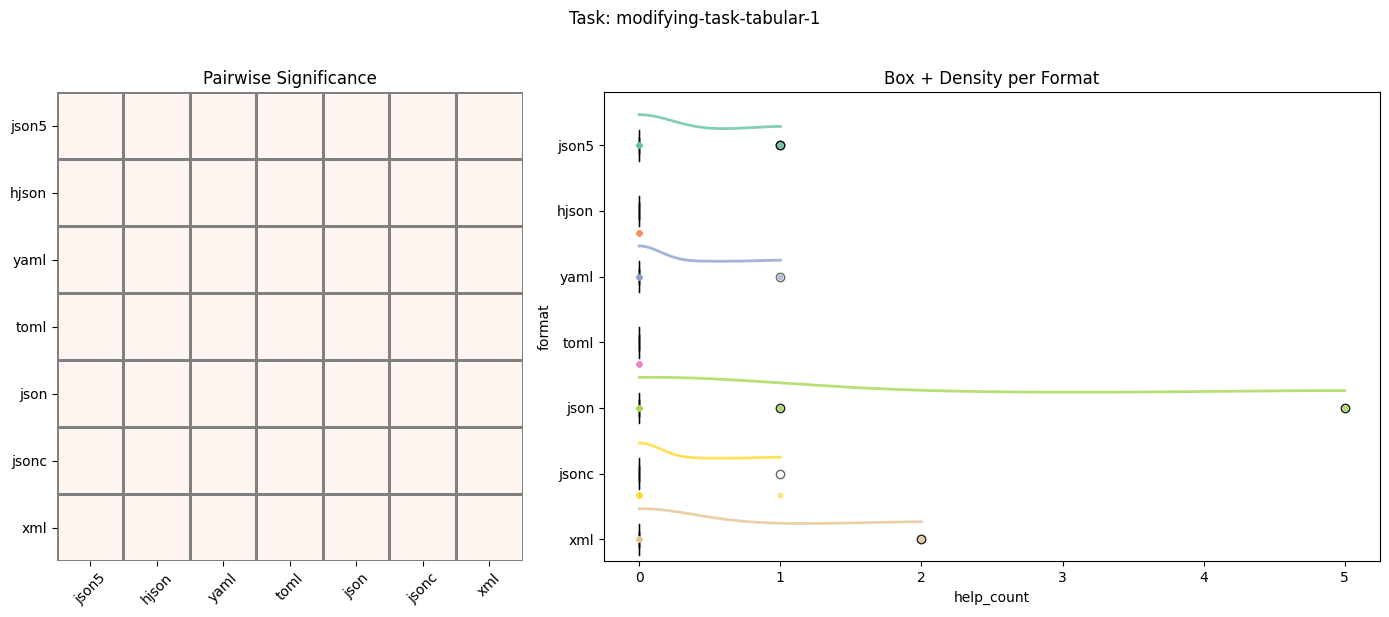

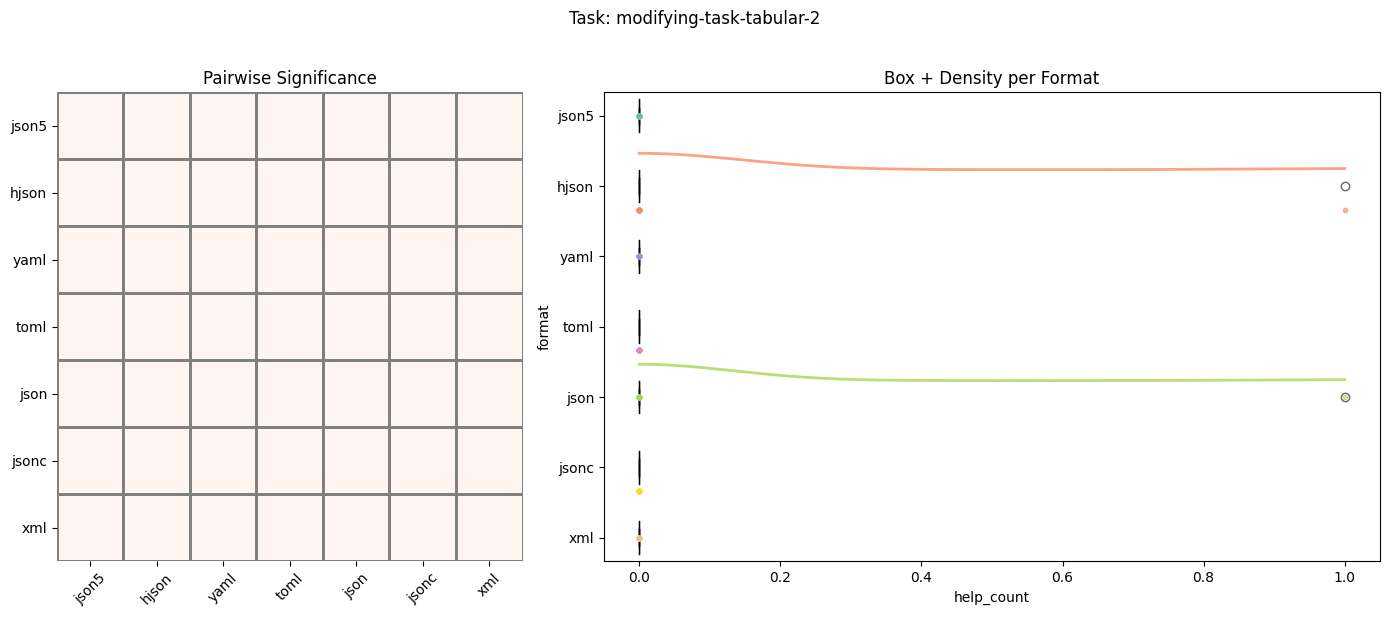

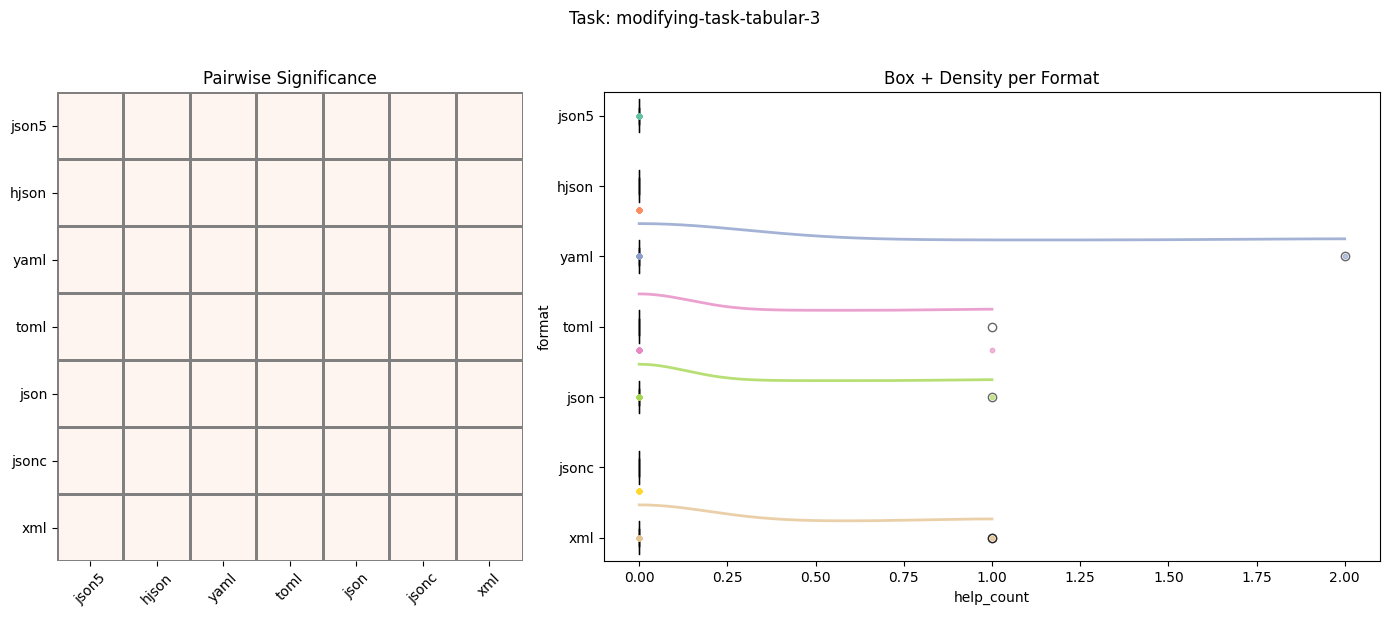

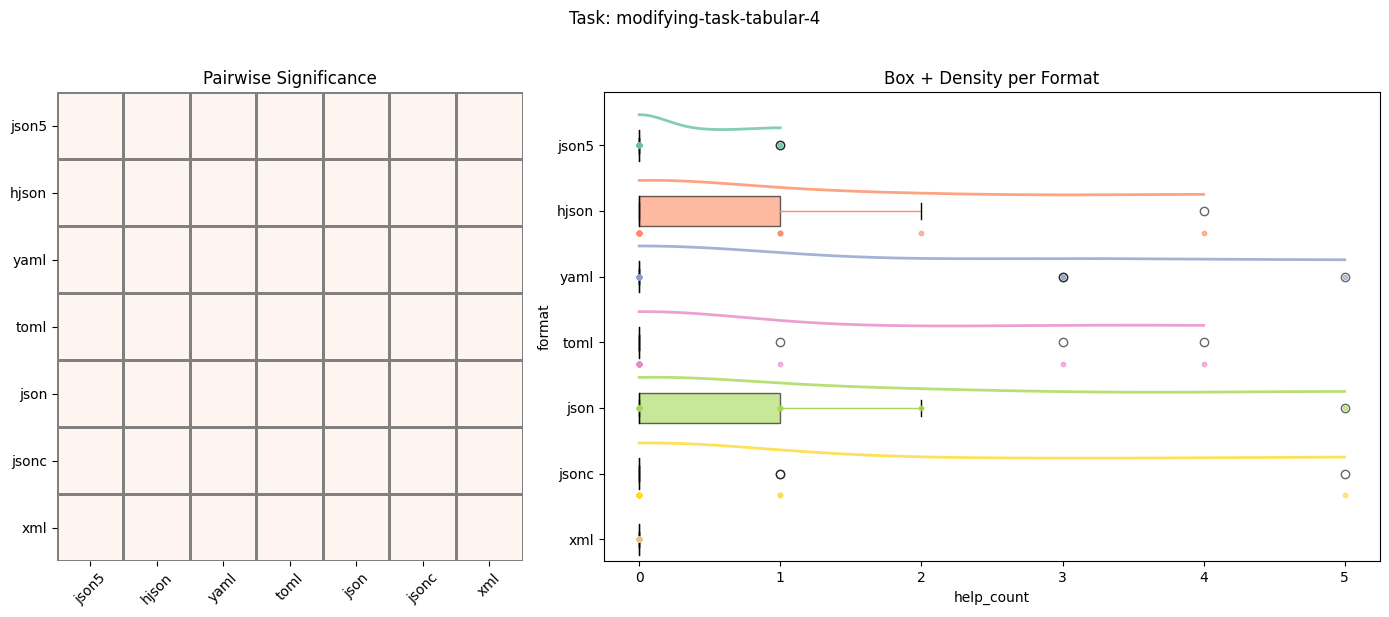

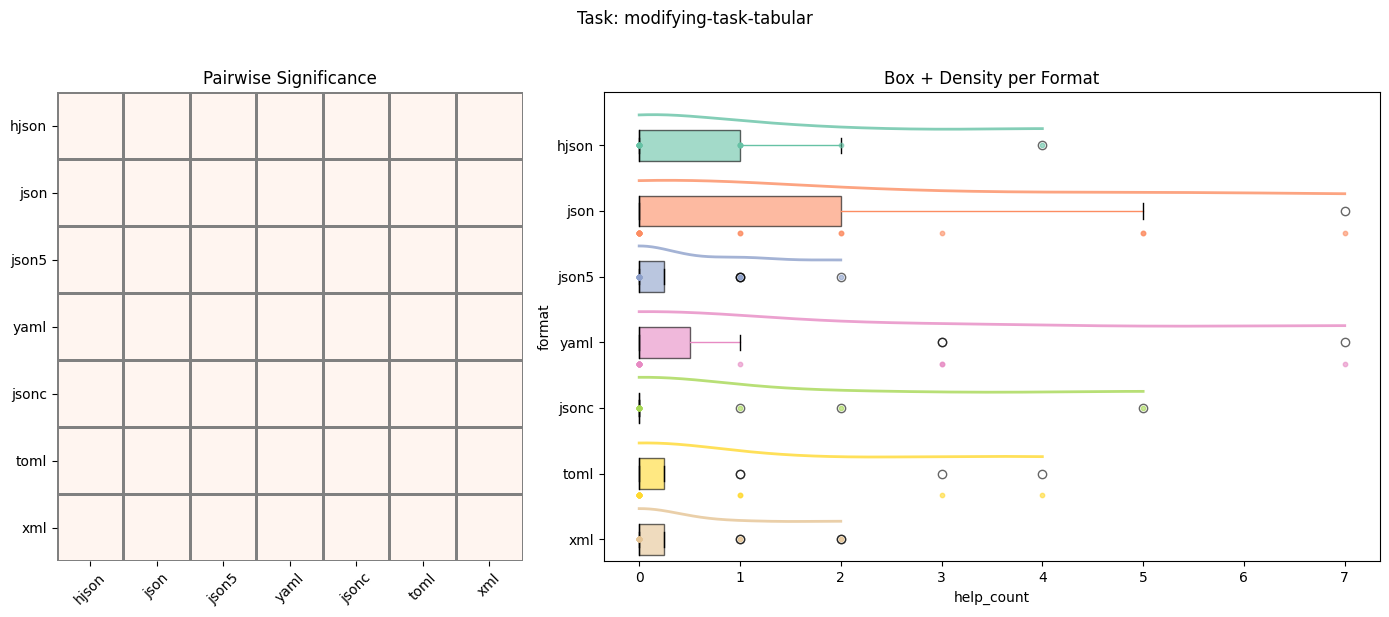

{'modifying-task-tabular': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      16  0.625000  1.087811     0.0    0    4
  json       18  1.444444  2.175322     0.0    0    7
  json5      16  0.312500  0.602080     0.0    0    2
  jsonc      15  0.533333  1.355764     0.0    0    5
  toml       16  0.562500  1.209339     0.0    0    4
  xml        16  0.375000  0.718795     0.0    0    2
  yaml       15  0.933333  1.980861     0.0    0    7,
  'overall_p': 0.2712758542867054,
  'effect_size': 0.06832357158900465,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'modifying-task-tabular-1': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max


In [9]:
## modifying tasks
vis_box_comparasion(
    df_modifying_clean,
    group_col='format',
    value_col='help_count',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['modifying-task-tabular-1','modifying-task-tabular-2','modifying-task-tabular-3','modifying-task-tabular-4', 'modifying-task-tabular']
)

m_help_results = compare_statistically(
    df_modifying_clean,
    group_col='format',
    value_col='help_count',
    method='anova',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['modifying-task-tabular-1','modifying-task-tabular-2','modifying-task-tabular-3','modifying-task-tabular-4', 'modifying-task-tabular']
)

m_help_results

In [10]:
# sig_pairs = compare_significant_pairs(
#     df_writing_norm,
#     group_col='format',
#     value_col='normalized_time',
#     method='anova',
#     task_col=None
# )
# print(sig_pairs)


# # 多任务，返回 dict
# sig_by_task = compare_significant_pairs(
#     df_modifying_clean,
#     group_col='format',
#     value_col='help_count',
#     method='anova',
#     task_col='task',
#     # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
#     continuous_tasks=['modifying-task-config-1','modifying-task-config-2','modifying-task-config-3','modifying-task-config-4', 'modifying-task']
# )
# for task, df_sig in sig_by_task.items():
#     print(task, df_sig)

## Reading Correctness Analysis

### statistical test

In [11]:
correct_answers_tabular = {
    'reading-task-tabular-1': 87,
    'reading-task-tabular-2': 'quiz2',
    'reading-task-tabular-3': 4,
    'reading-task-tabular-4': 'Bob',
    'reading-task-tabular-5': ['[Bob, Eve]', '[Alice]']
}


df_reading_result = annotate_reading_correctness_exact(
    df_reading,
    correct_answers_tabular,
    task_col='task',
    format_col='format',
    response_col='response'
)

df_reading_agg = aggregate_tasks_with_format(
    df_reading_result,
    participant_col='participantId',
    task_col='task',
    format_col = 'format',
    metrics=['duration_sec','help_count','correct']
)
df_reading_agg

,participantId,task,format,response,start_time,end_time,duration_sec,help_count,correct_answer,correct
0,64457bc906c125cebd4bf66b,reading-task-tabular-1,json5,9,1.746560e+12,1.746560e+12,14.824,0,87,0
1,64457bc906c125cebd4bf66b,reading-task-tabular-2,json5,quiz2,1.746560e+12,1.746560e+12,72.466,0,quiz2,1
2,64457bc906c125cebd4bf66b,reading-task-tabular-3,json5,4,1.746560e+12,1.746560e+12,24.606,0,4,1
3,64457bc906c125cebd4bf66b,reading-task-tabular-4,json5,Bob,1.746560e+12,1.746560e+12,26.410,0,Bob,1
4,64457bc906c125cebd4bf66b,reading-task-tabular-5,json5,[Eve],1.746560e+12,1.746560e+12,96.426,0,"[Bob, Eve], [Alice]",0
...,...,...,...,...,...,...,...,...,...,...
667,67f1a4f8dd44e7cd5adffa29,reading-task-tabular,json5,NaN,NaN,NaN,1056.874,0,NaN,5
668,67f1c7bd6f1c4a3d8deae02f,reading-task-tabular,toml,NaN,NaN,NaN,577.437,0,NaN,4
669,67f3619e16d4ca195fbd1bd0,reading-task-tabular,yaml,NaN,NaN,NaN,603.879,0,NaN,3
670,67f5bb69760b211cdfe8021c,reading-task-tabular,jsonc,NaN,NaN,NaN,173.583,0,NaN,4


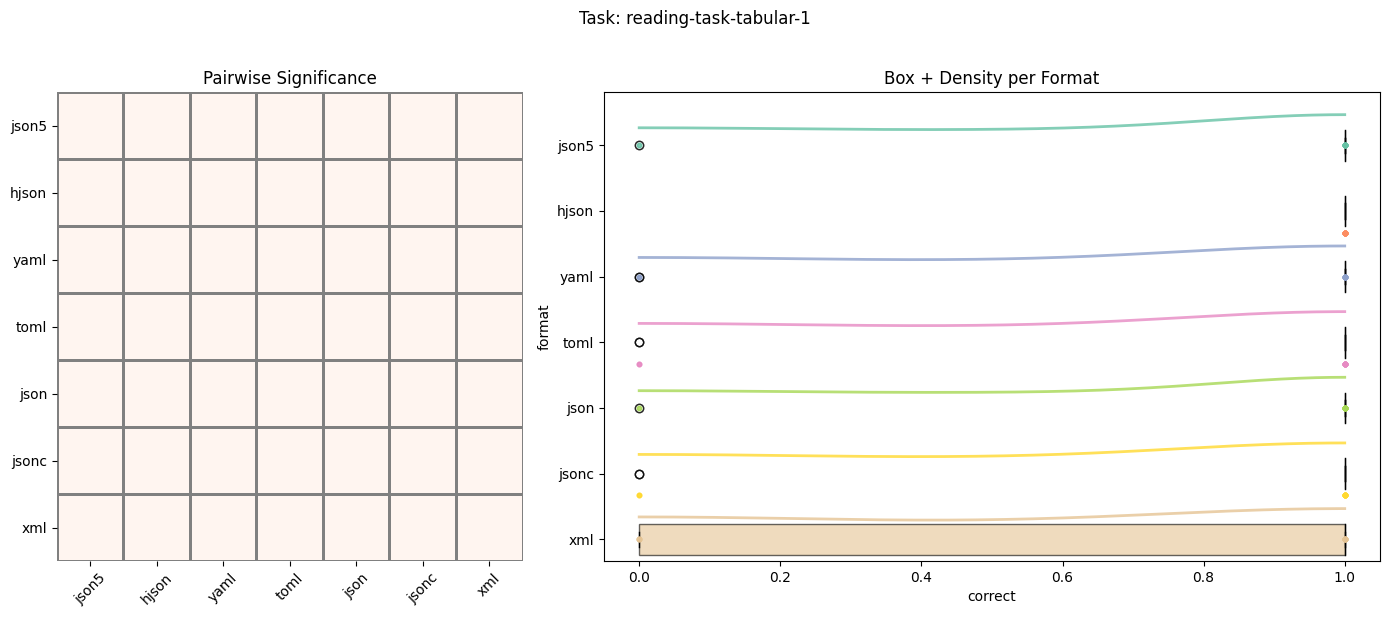

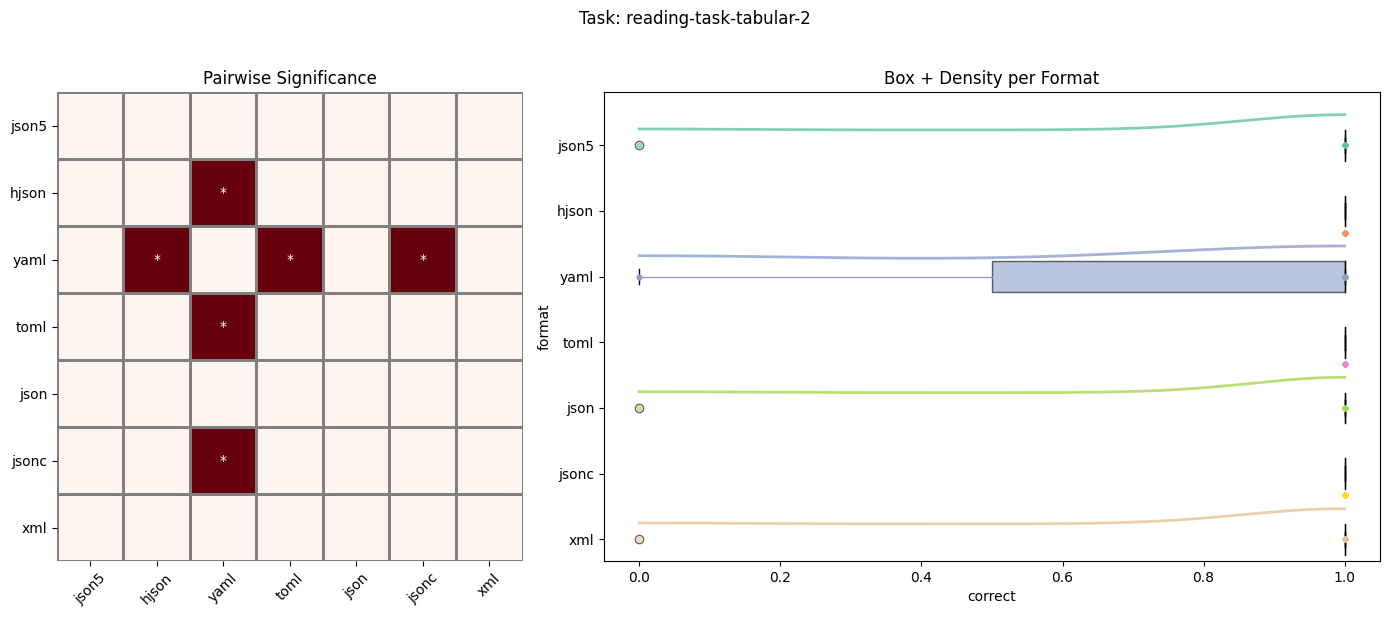

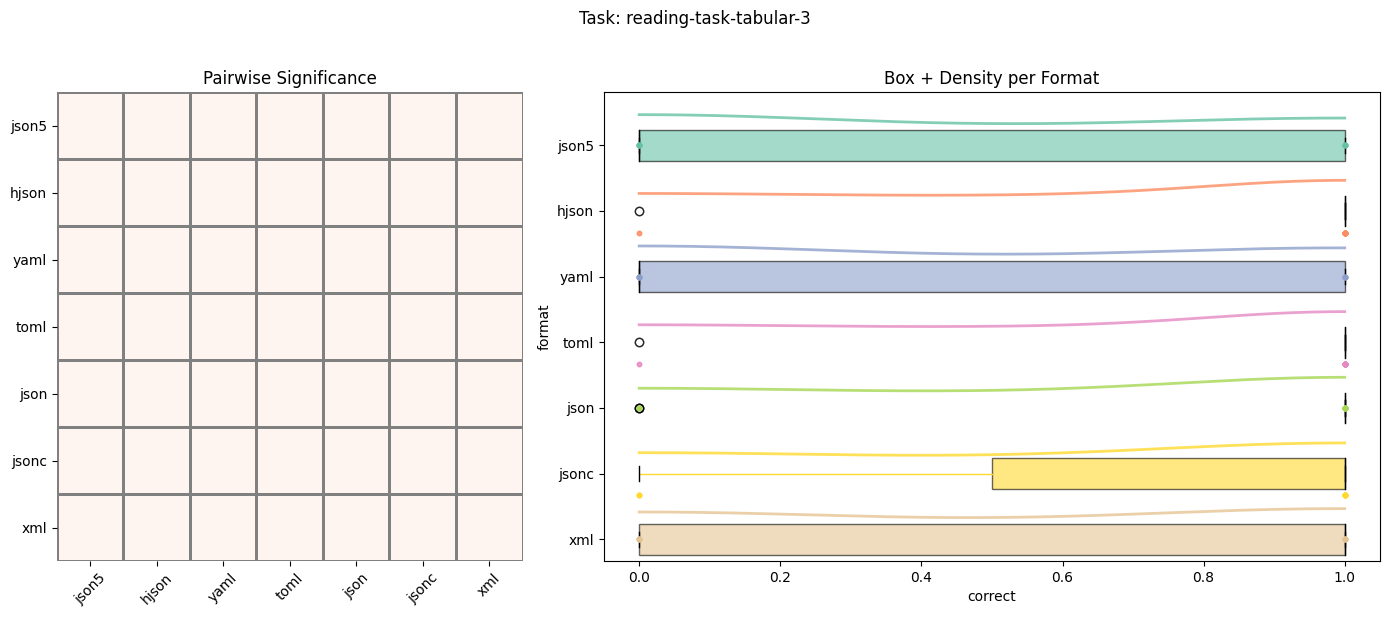

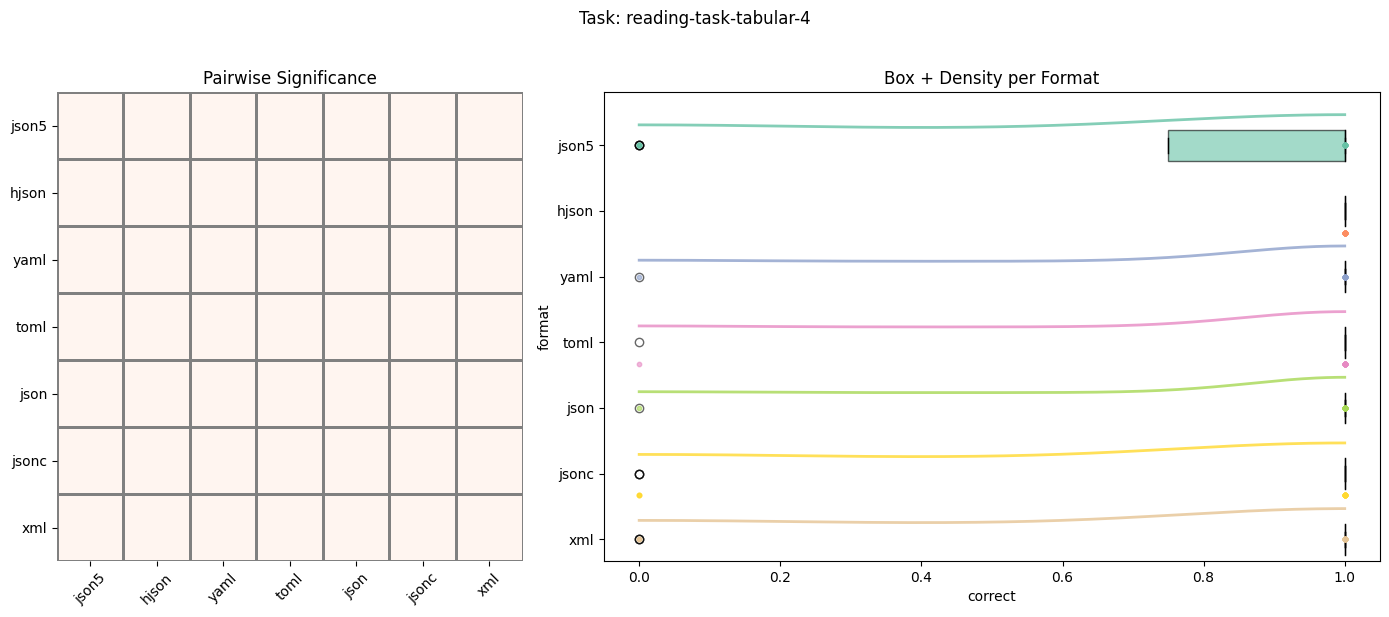

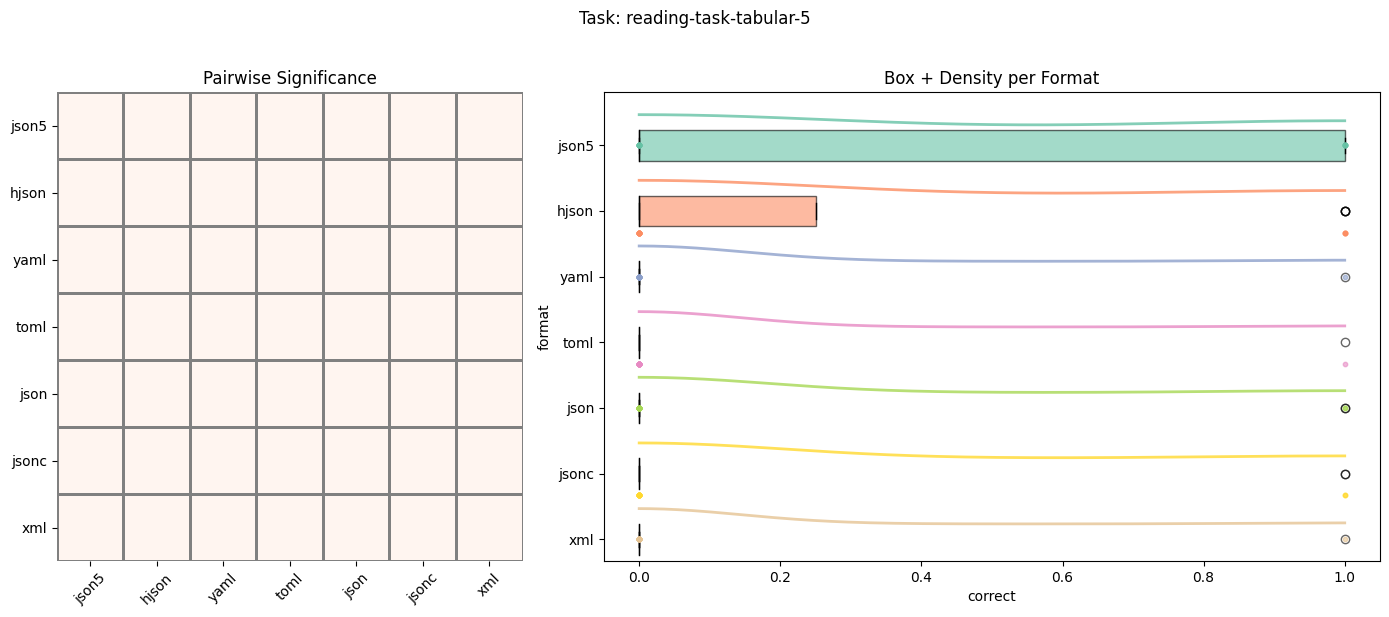

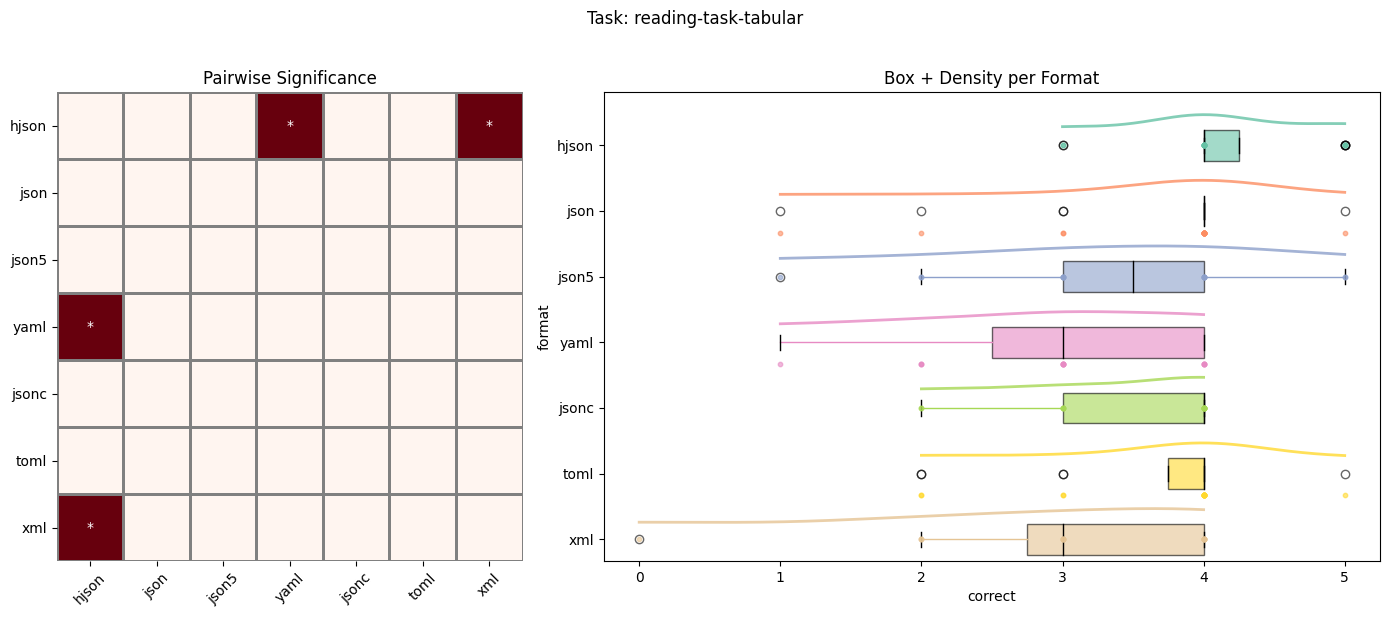

{'reading-task-tabular': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      16  4.125000  0.619139     4.0    3    5
  json       18  3.666667  0.907485     4.0    1    5
  json5      16  3.375000  1.087811     3.5    1    5
  jsonc      15  3.466667  0.743223     4.0    2    4
  toml       16  3.687500  0.793200     4.0    2    5
  xml        16  3.062500  1.123610     3.0    0    4
  yaml       15  3.000000  0.925820     3.0    1    4,
  'overall_p': 0.01082455277047015,
  'effect_size': 0.14384022382950853,
  'is_significant': True,
  'pairwise':    group1 group2  p_value  significant                     interpretation
  0   hjson   json   0.7575        False   hjson vs json is not significant
  1   hjson  json5   0.2310        False  hjson vs json5 is not significant
  2   hjson  jsonc   0.4032        False  hjson vs jsonc is n

In [12]:
## reading tasks
vis_box_comparasion(
    df_reading_agg,
    group_col='format',
    value_col='correct',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    discrete_tasks=['reading-task-tabular-1','reading-task-tabular-2','reading-task-tabular-3','reading-task-tabular-4', 'reading-task-tabular-5'],
    continuous_tasks=['reading-task-tabular']
)

r_correct_results = compare_statistically(
    df_reading_agg,
    group_col='format',
    value_col='correct',
    method='anova',
    task_col='task',
    discrete_tasks=['reading-task-tabular-1','reading-task-tabular-2','reading-task-tabular-3','reading-task-tabular-4', 'reading-task-tabular-5'],
    continuous_tasks=['reading-task-tabular']
)

r_correct_results

In [13]:
sig_by_task = compare_significant_pairs(
    df_reading_agg,
    group_col='format',
    value_col='correct',
    method='anova',
    task_col='task',
    discrete_tasks=['reading-task-tabular-1','reading-task-tabular-2','reading-task-tabular-3','reading-task-tabular-4', 'reading-task-tabular-5'],
    continuous_tasks=['reading-task-tabular']
)
for task, df_sig in sig_by_task.items():
    print(task, df_sig)

reading-task-tabular-1 Empty DataFrame
Columns: [group1, group2, p_value, significant, interpretation]
Index: []
reading-task-tabular-2   group1 group2  p_value  significant                interpretation
0  hjson   yaml   0.0318         True  hjson vs yaml is significant
1  jsonc   yaml   0.0366         True  jsonc vs yaml is significant
2   toml   yaml   0.0318         True   toml vs yaml is significant
reading-task-tabular-3 Empty DataFrame
Columns: [group1, group2, p_value, significant, interpretation]
Index: []
reading-task-tabular-4 Empty DataFrame
Columns: [group1, group2, p_value, significant, interpretation]
Index: []
reading-task-tabular-5 Empty DataFrame
Columns: [group1, group2, p_value, significant, interpretation]
Index: []
reading-task-tabular   group1 group2  p_value  significant                interpretation
0  hjson    xml   0.0200         True   hjson vs xml is significant
1  hjson   yaml   0.0131         True  hjson vs yaml is significant


### correctness distribution

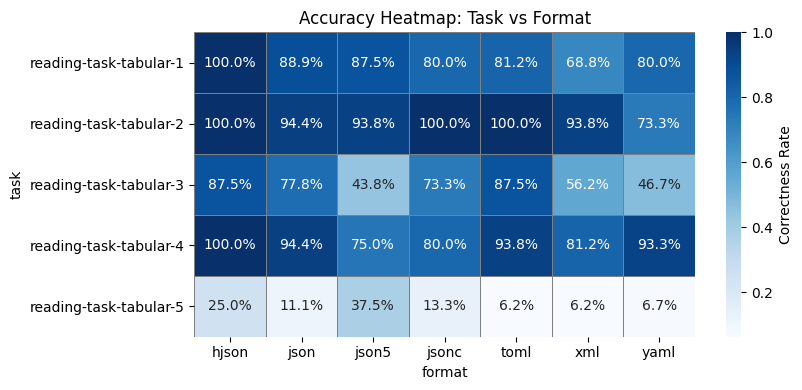

In [14]:
# 只看 task1, task3, task5 三个任务：
visualize_accuracy_heatmap(
    df_reading_agg,
    task_col='task',
    format_col='format',
    accuracy_col='correct',
    task_list=['reading-task-tabular-1','reading-task-tabular-2','reading-task-tabular-3','reading-task-tabular-4','reading-task-tabular-5'],
    cmap='Blues',
    annot=True,
    fmt='.1%', 
    cbar_label='Correctness Rate'
)

# # 只看 yaml 和 xml 两种格式：
# visualize_accuracy_heatmap(
#     df_reading_clean,
#     task_col='task',
#     format_col='format',
#     accuracy_col='correctness',
#     format_list=['yaml','xml'],
#     cmap='YlGnBu'
# )

# # 既过滤任务，也过滤格式
# visualize_accuracy_heatmap(
#     df_reading_clean,
#     task_col='task',
#     format_col='format',
#     accuracy_col='correctness',
#     task_list=['reading-task-config-2','reading-task-config-4'],
#     format_list=['json','json5'],
#     cmap='Purples'
# )


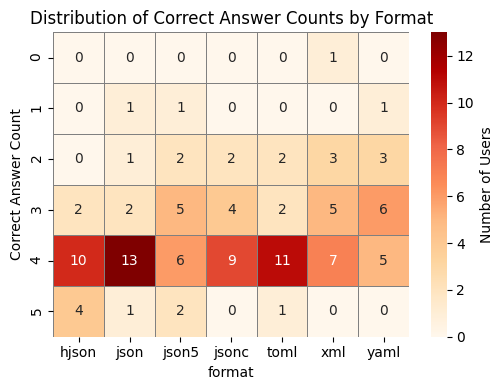

In [15]:
visualize_score_distribution_heatmap(
    df_reading_result,
    participant_col='participantId',
    task_col='task',
    format_col='format',
    correct_col='correct',
    cmap='OrRd',
    annot=True,
    fmt='d',
    cbar_label='Number of Users'
)


## Post Task Question Analysis

### statistical test

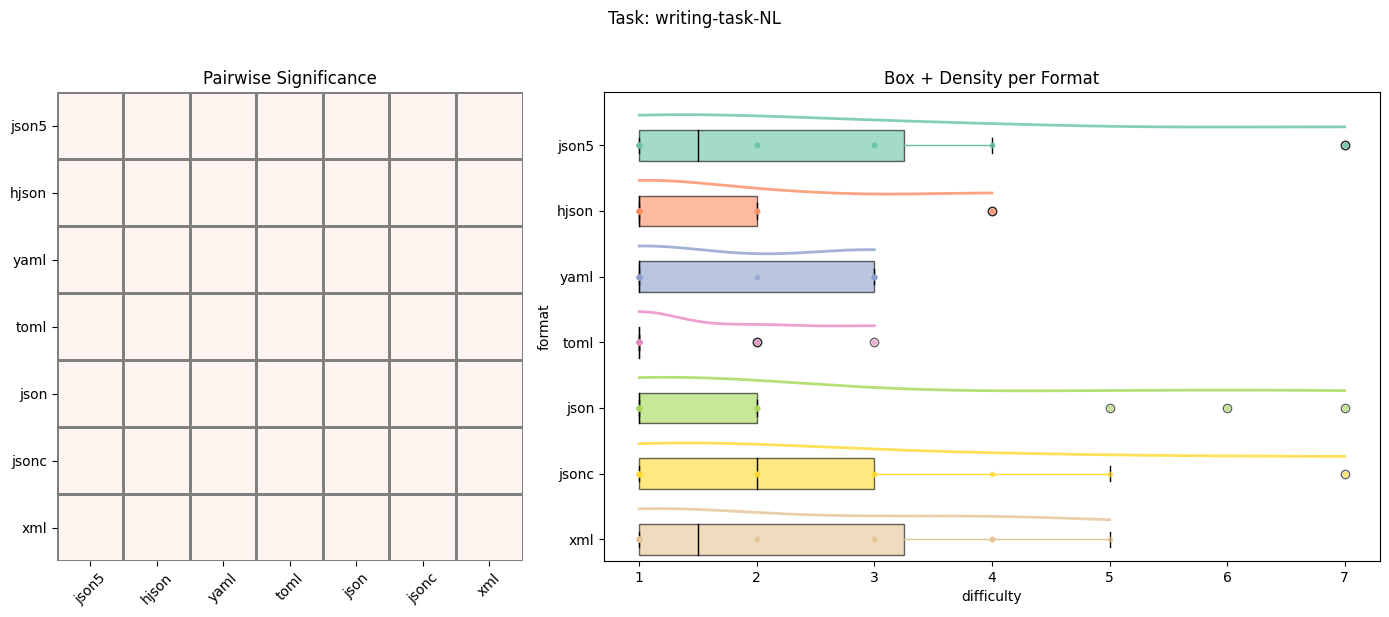

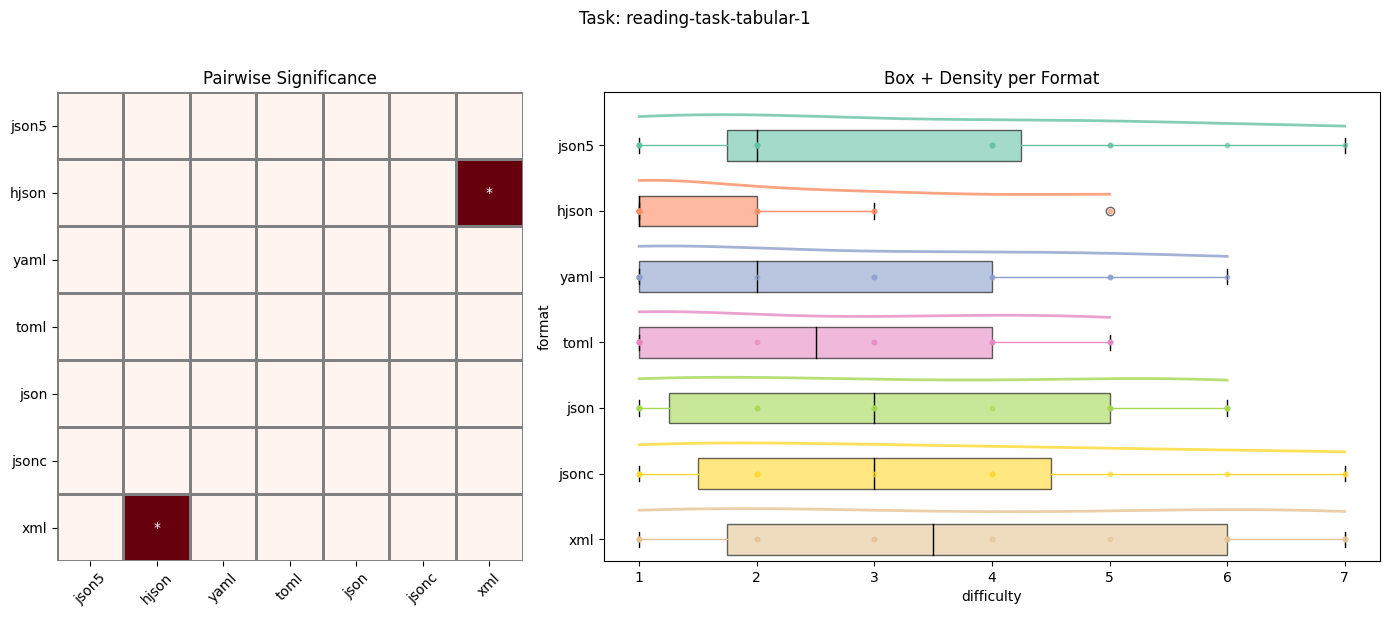

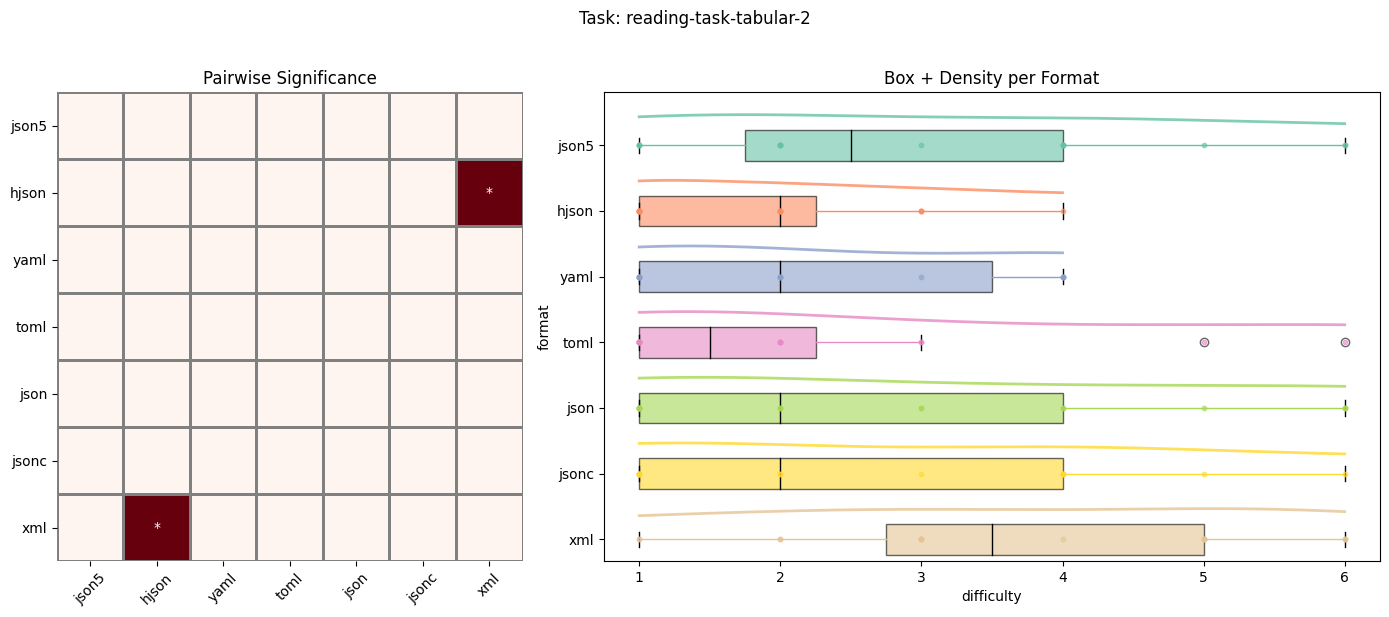

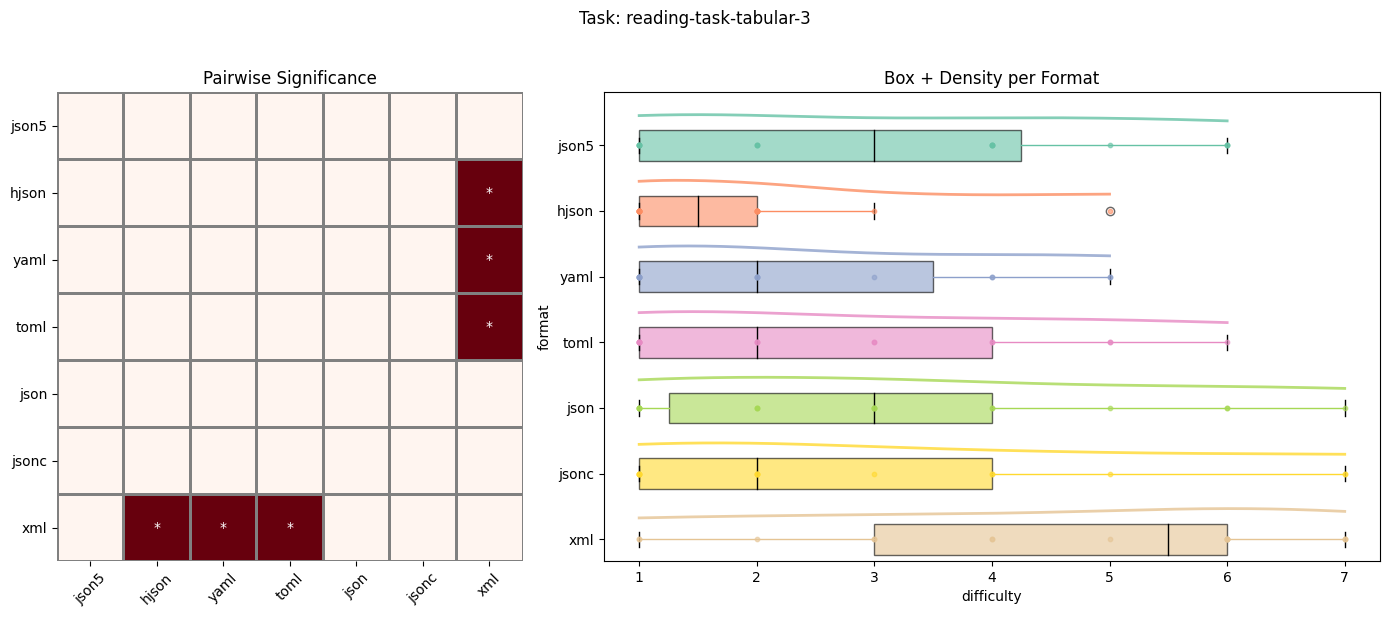

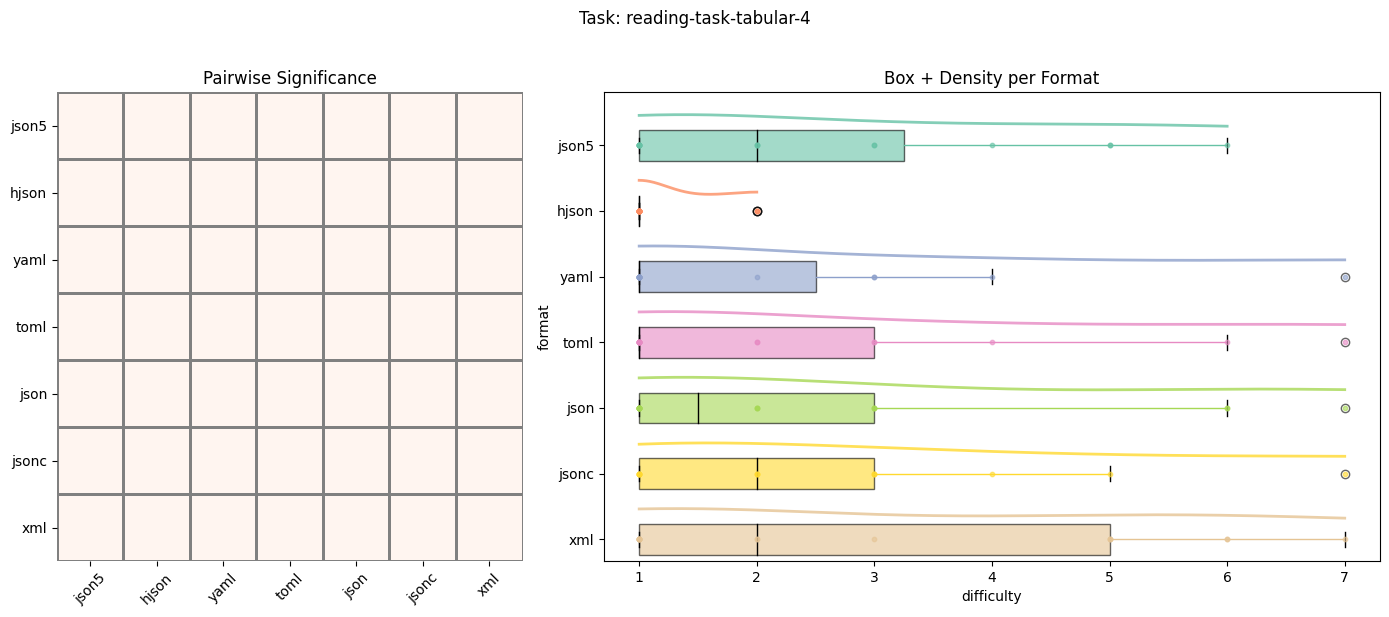

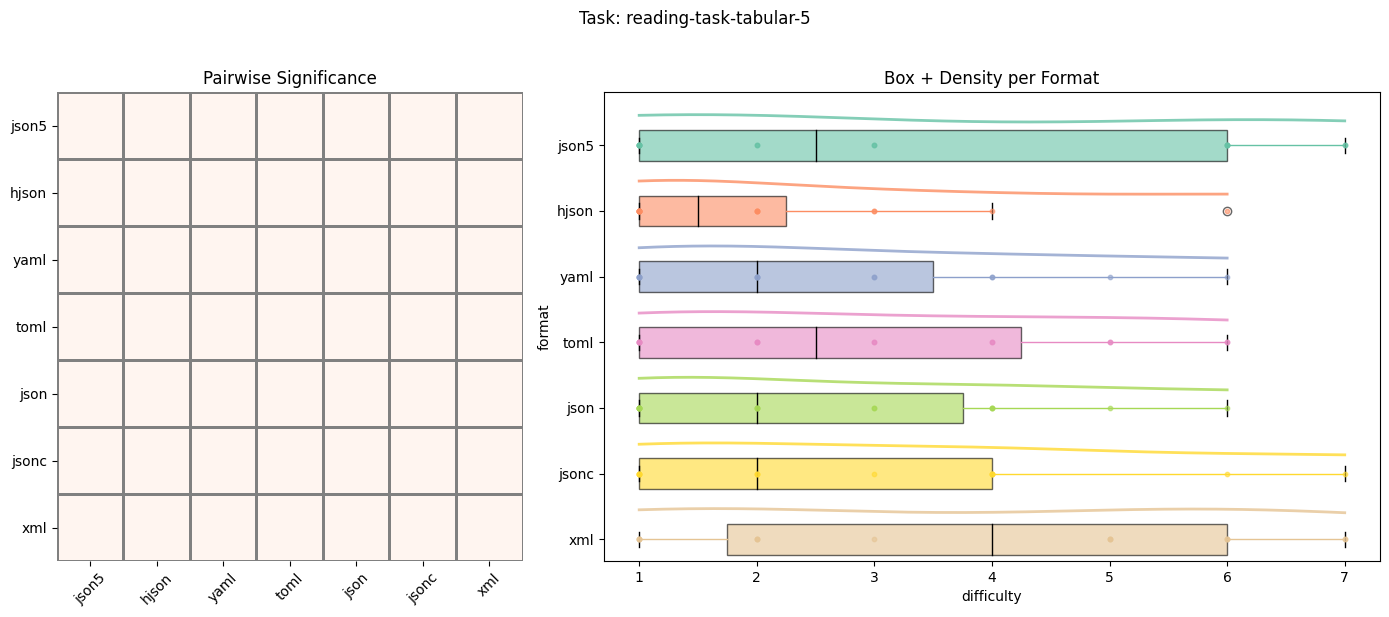

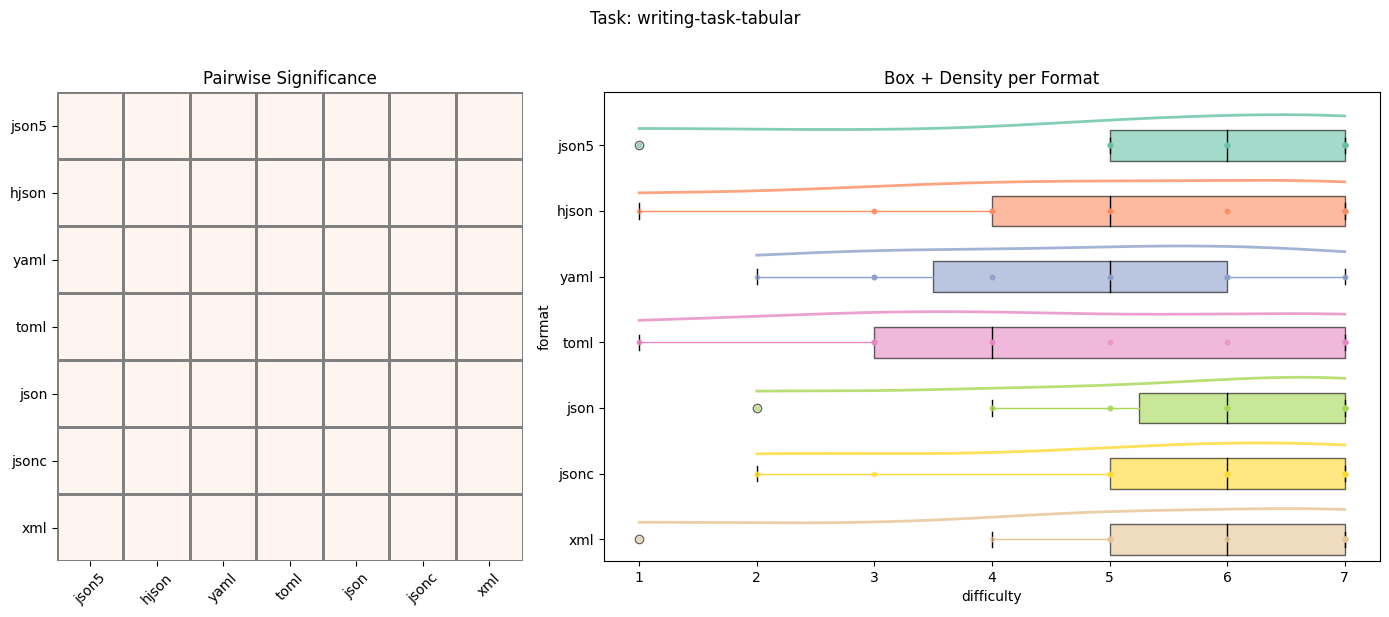

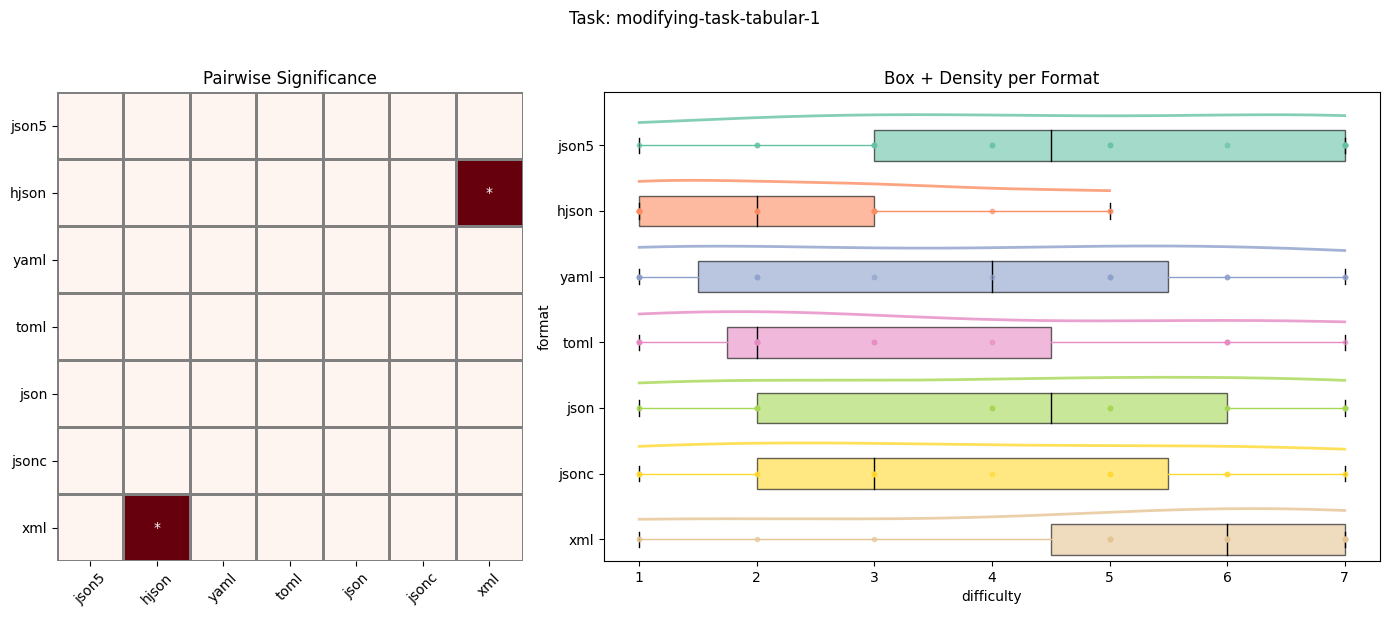

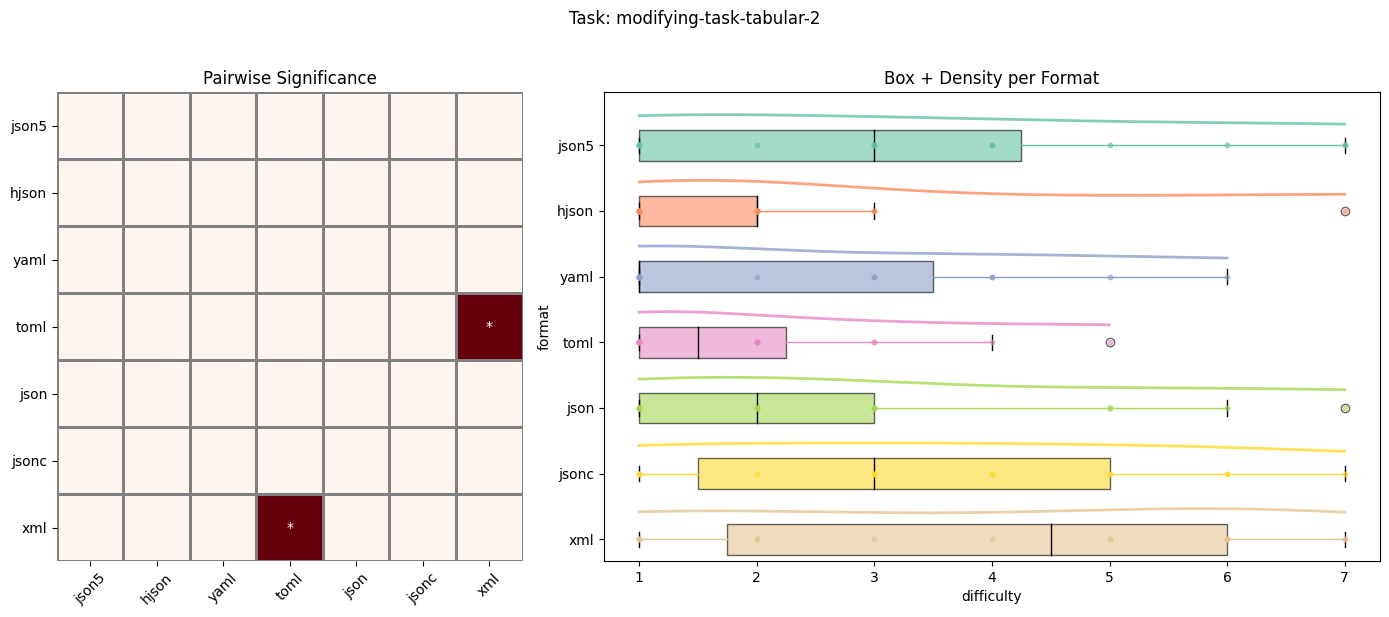

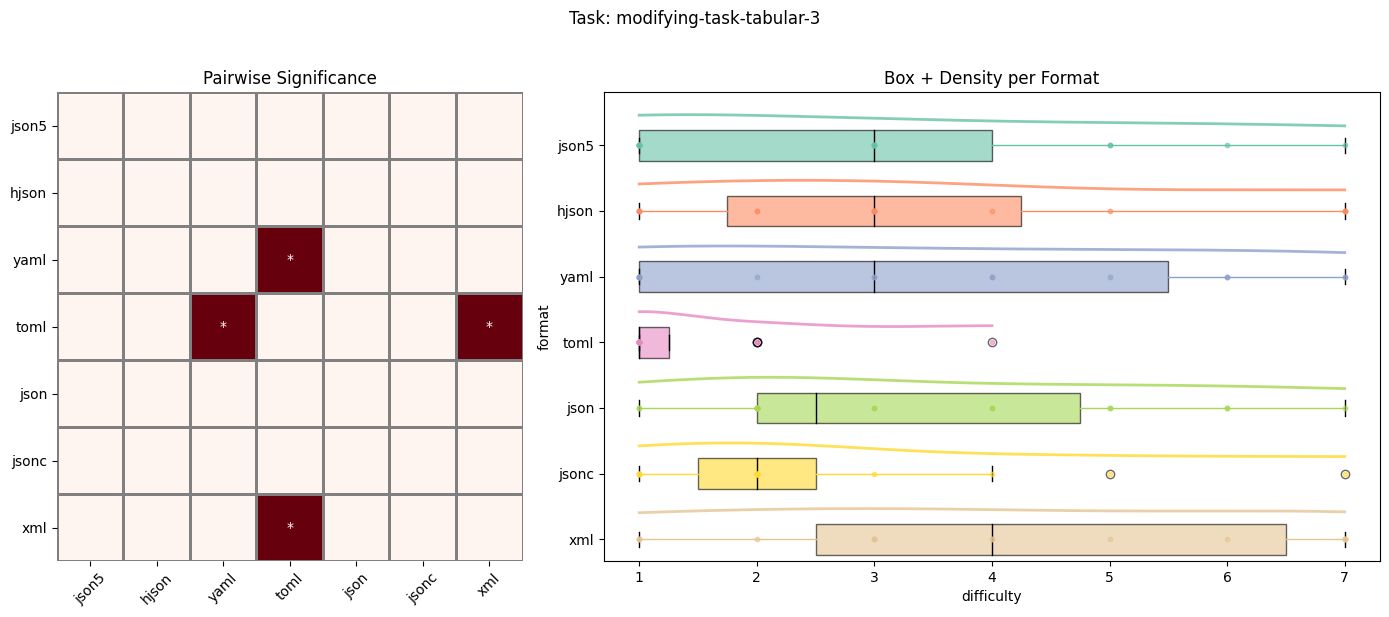

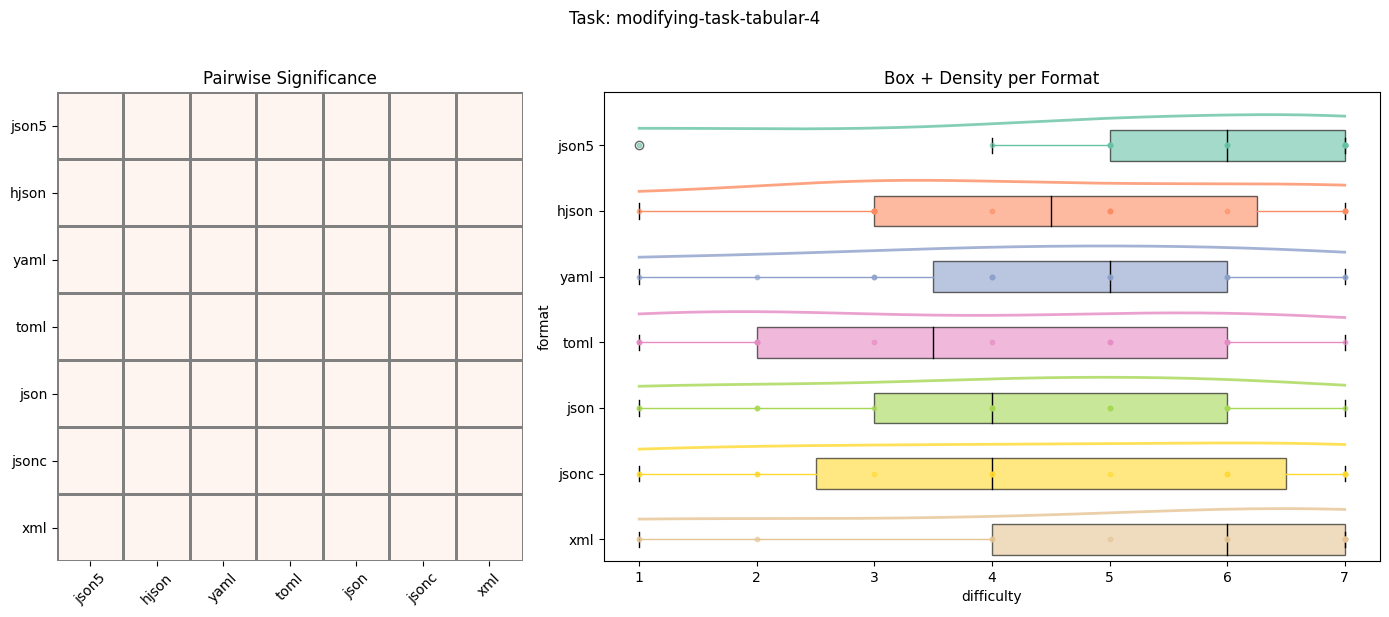

{'modifying-task-tabular-1': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      16  2.375000  1.408309     2.0  1.0  5.0
  json       18  4.277778  2.164026     4.5  1.0  7.0
  json5      16  4.562500  2.096624     4.5  1.0  7.0
  jsonc      15  3.733333  2.153624     3.0  1.0  7.0
  toml       16  3.062500  2.080665     2.0  1.0  7.0
  xml        16  5.062500  2.143789     6.0  1.0  7.0
  yaml       15  3.733333  2.282438     4.0  1.0  7.0,
  'overall_p': 0.00724899218497417,
  'effect_size': 0.15189865317583998,
  'is_significant': True,
  'pairwise':    group1 group2  p_value  significant                     interpretation
  0   hjson   json   0.1126        False   hjson vs json is not significant
  1   hjson  json5   0.0510        False  hjson vs json5 is not significant
  2   hjson  jsonc   0.5300        False  hjson vs jsonc 

In [16]:
df_post = extract_post_task_questions(all_data)

vis_box_comparasion(
    df_post,
    group_col='format',
    value_col='difficulty',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
    # discrete_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5'],
    # continuous_tasks=['reading-task']
)

post_d_results = compare_statistically(
    df_post,
    group_col='format',
    value_col='difficulty',
    method='anova',
    task_col='task'
    # discrete_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5'],
    # continuous_tasks=['reading-task']
)

post_d_results

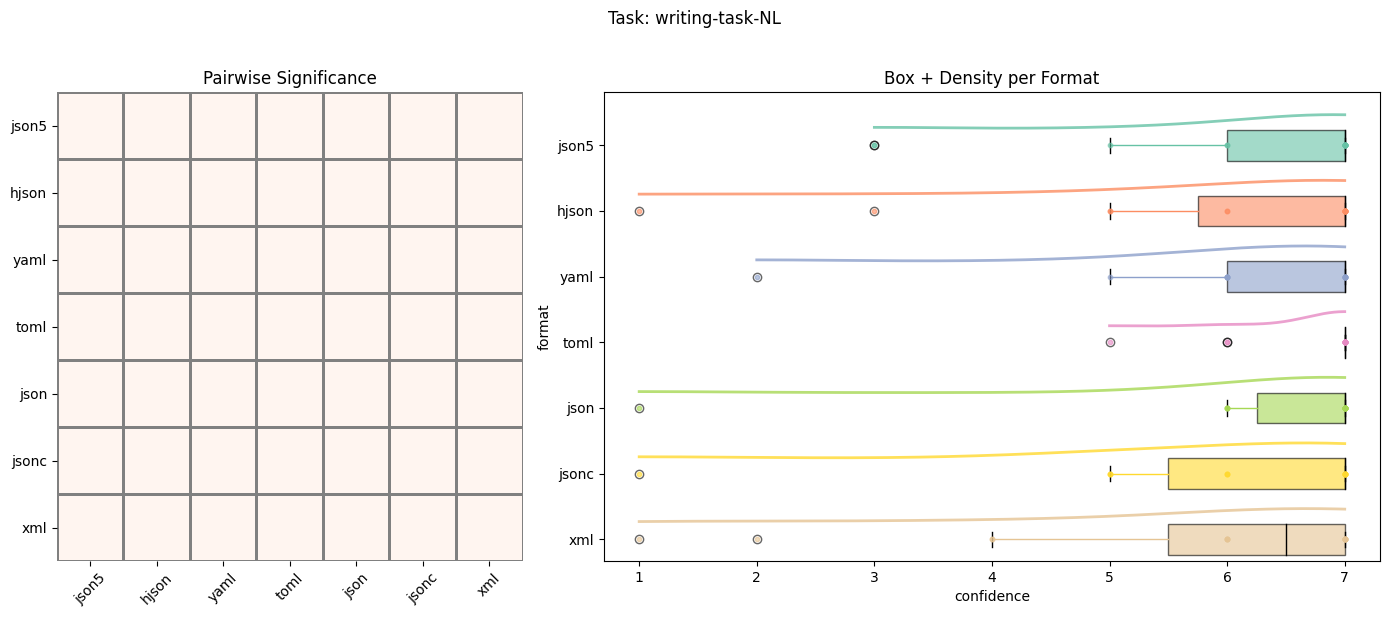

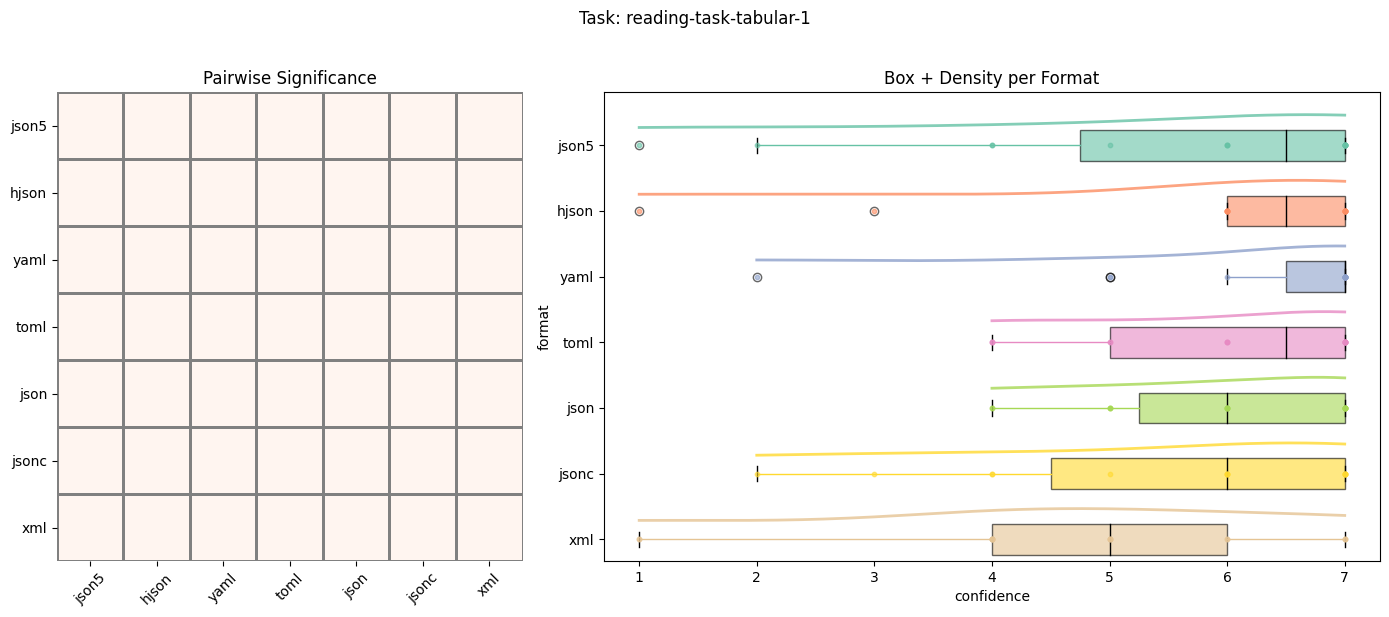

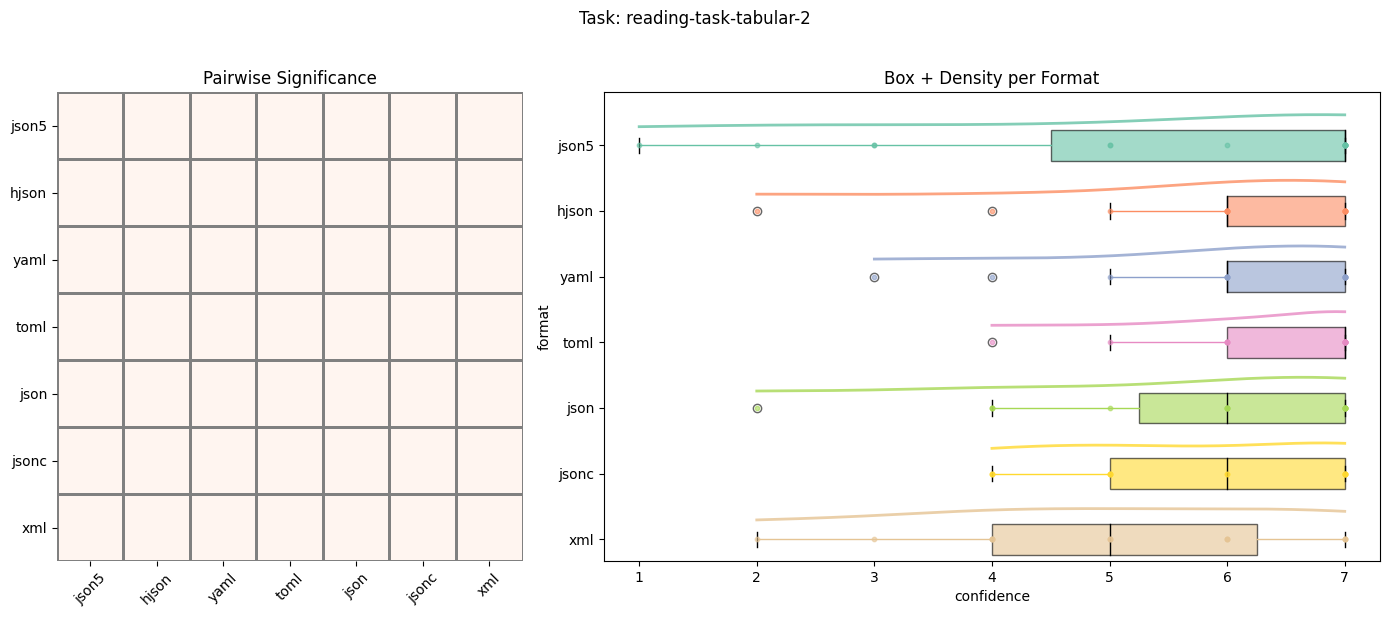

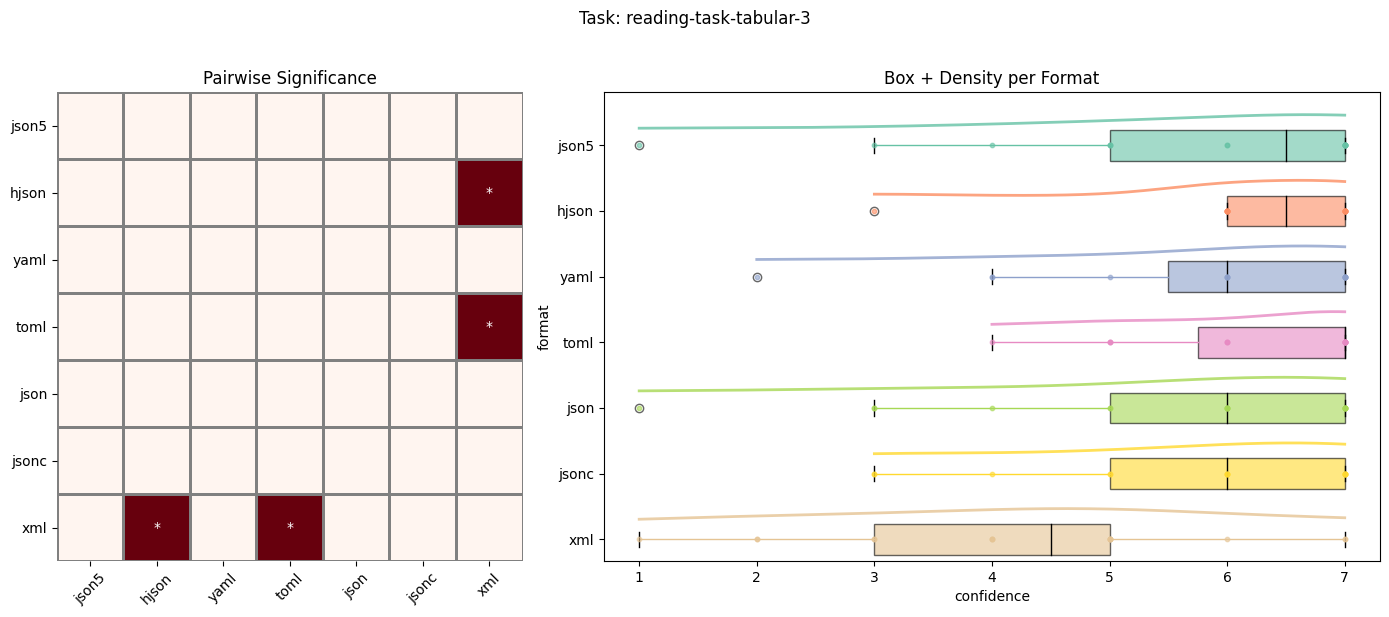

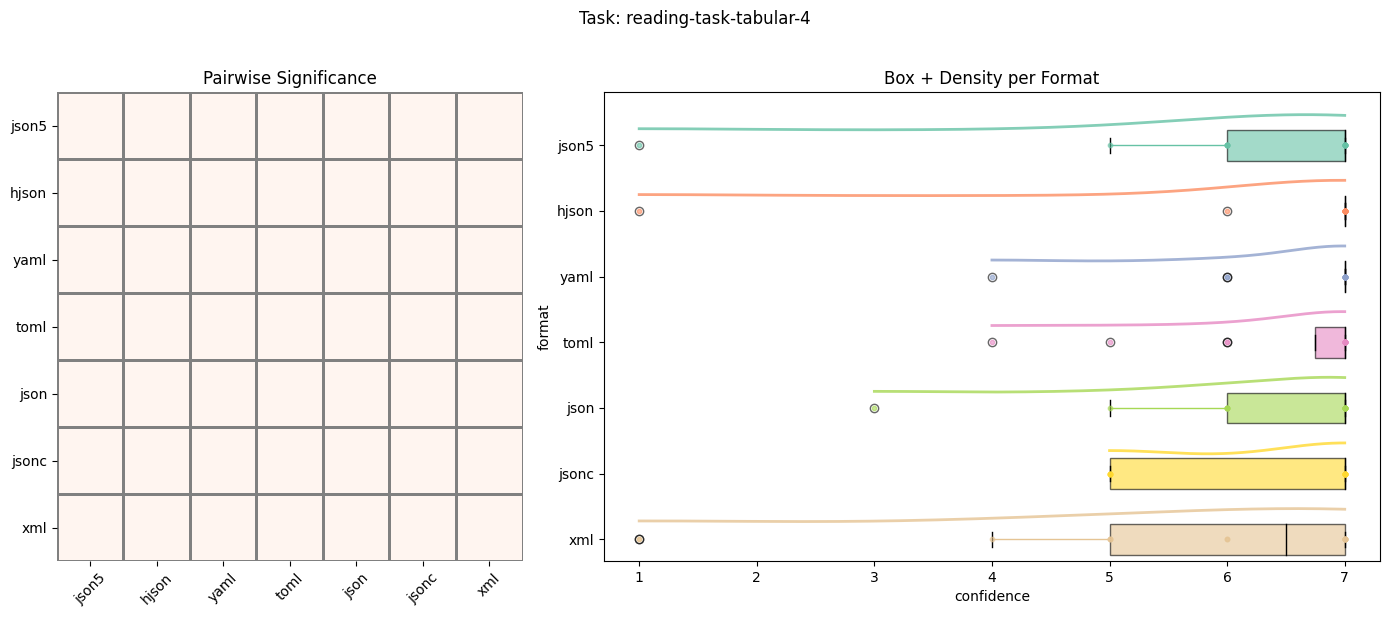

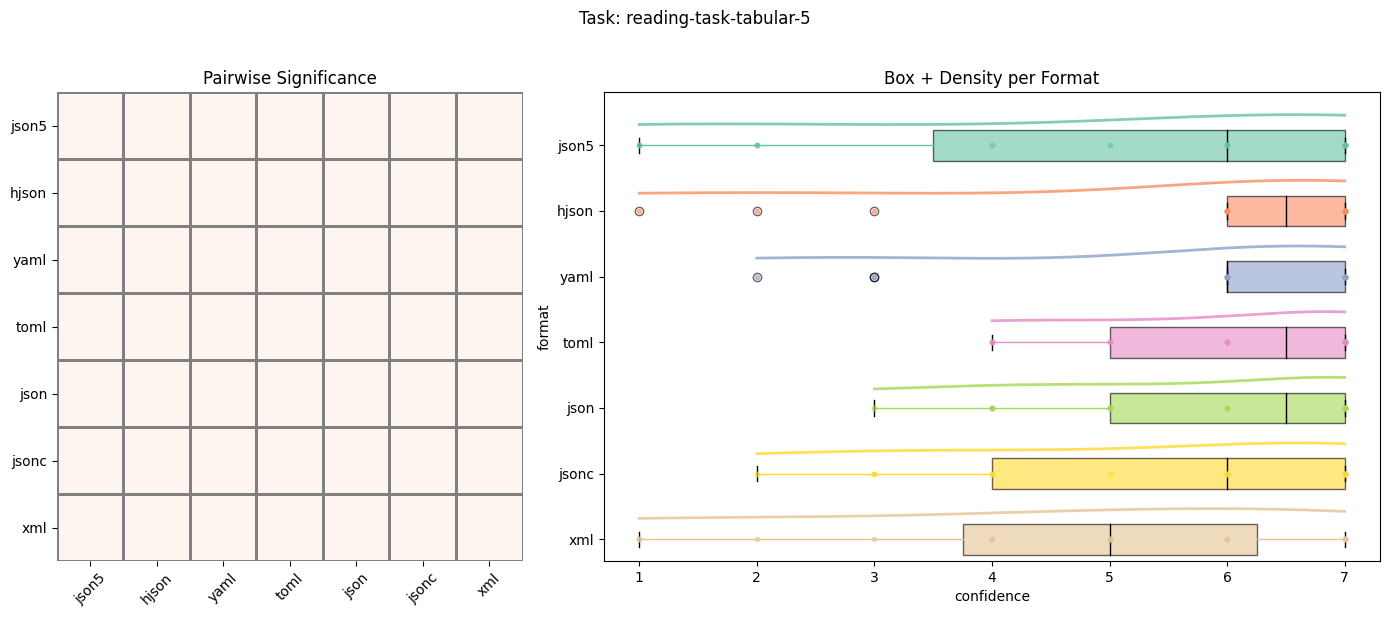

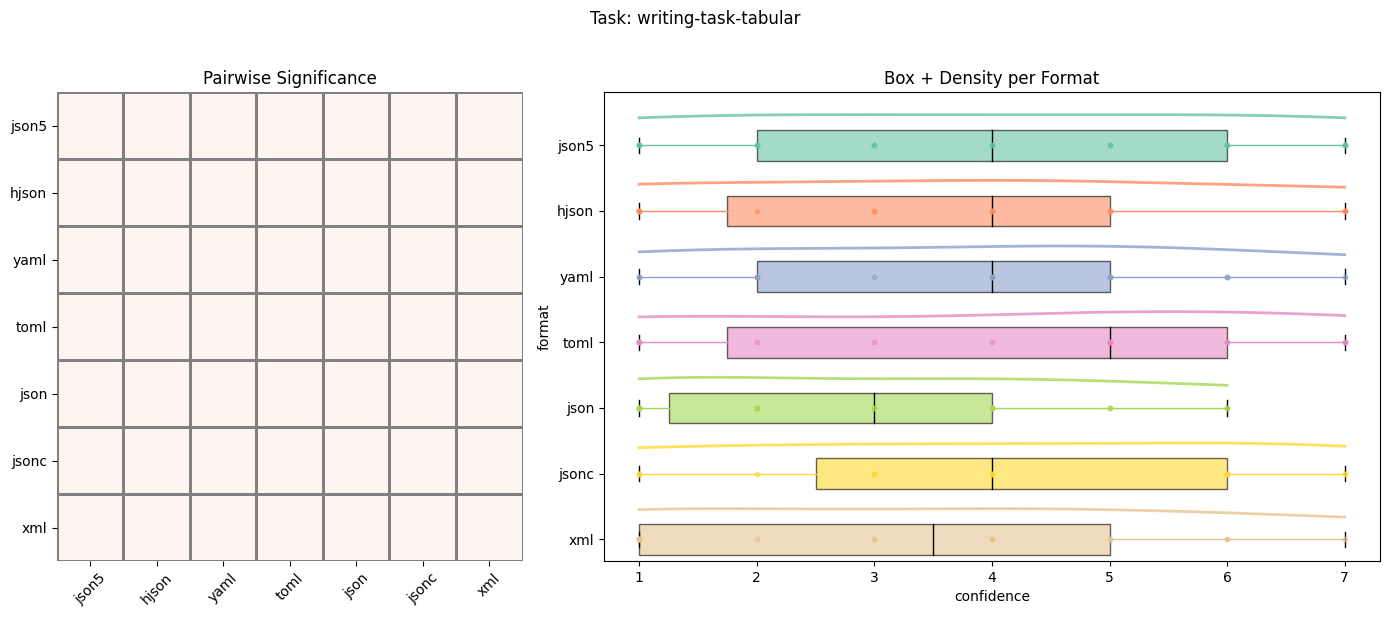

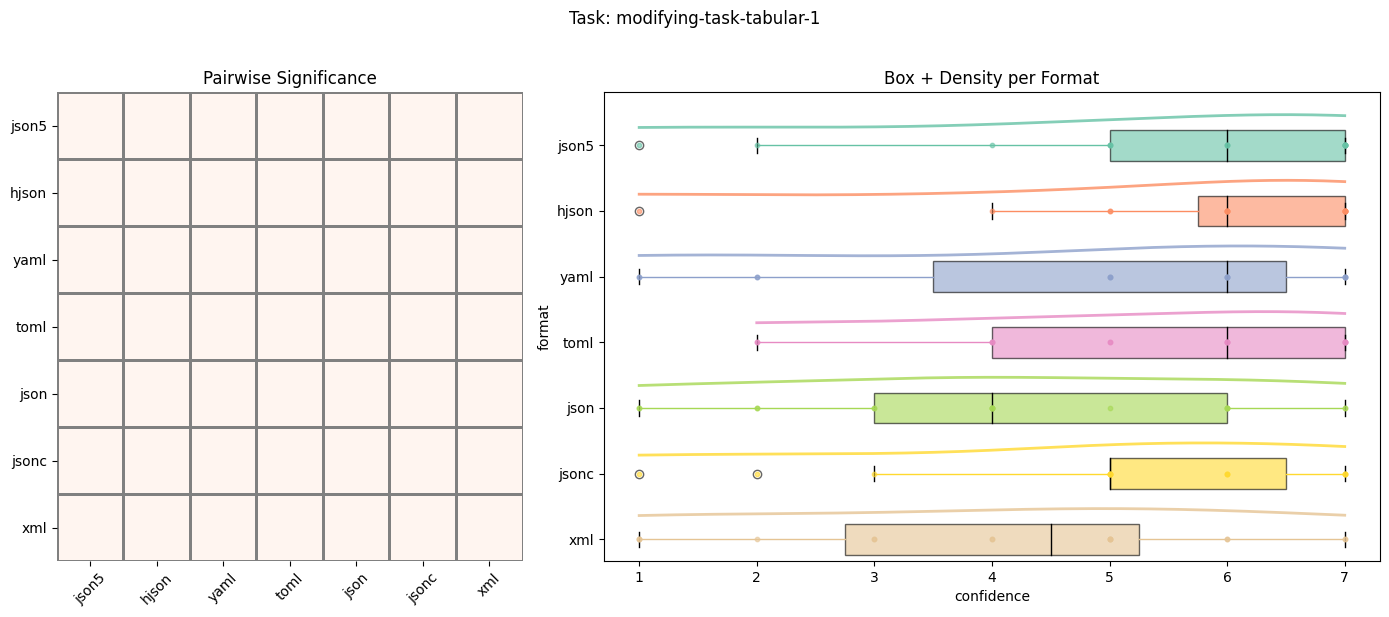

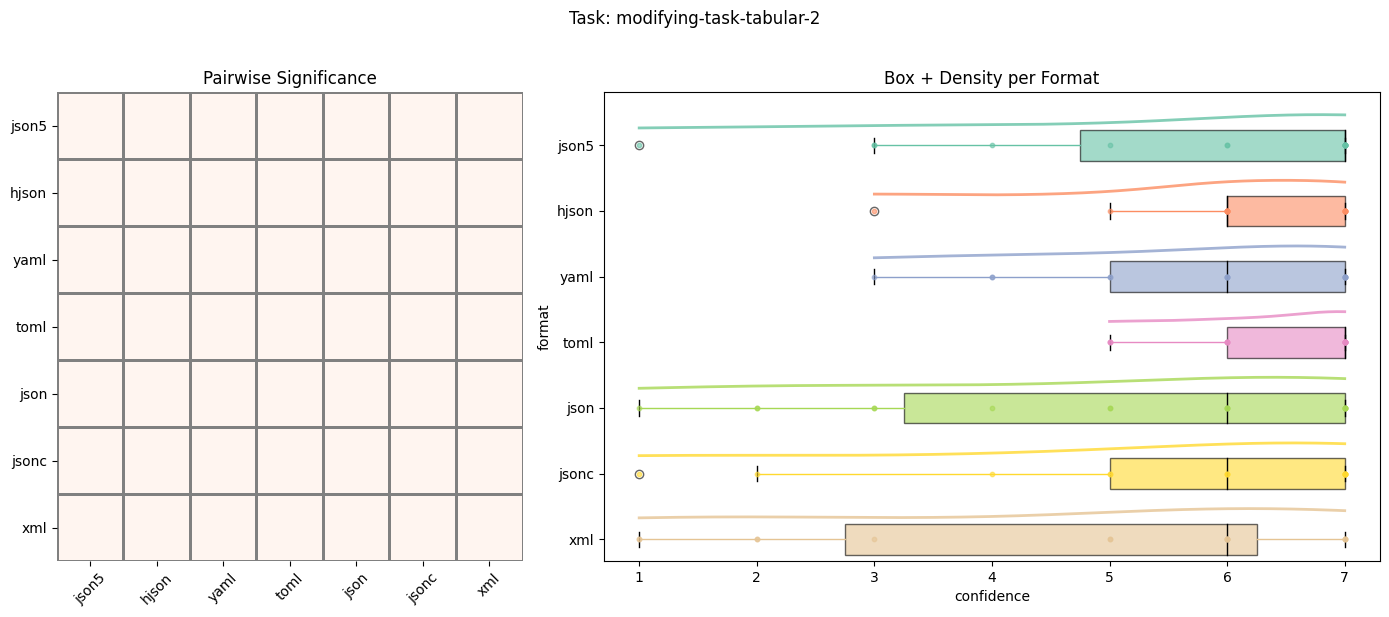

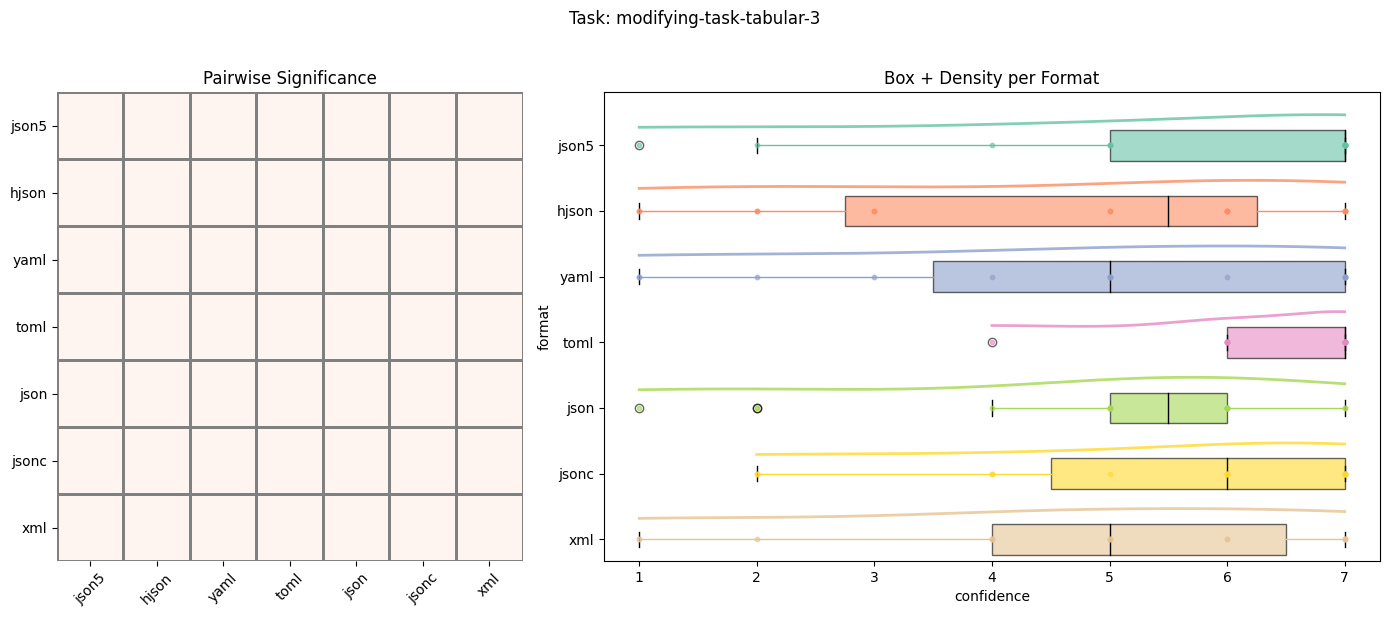

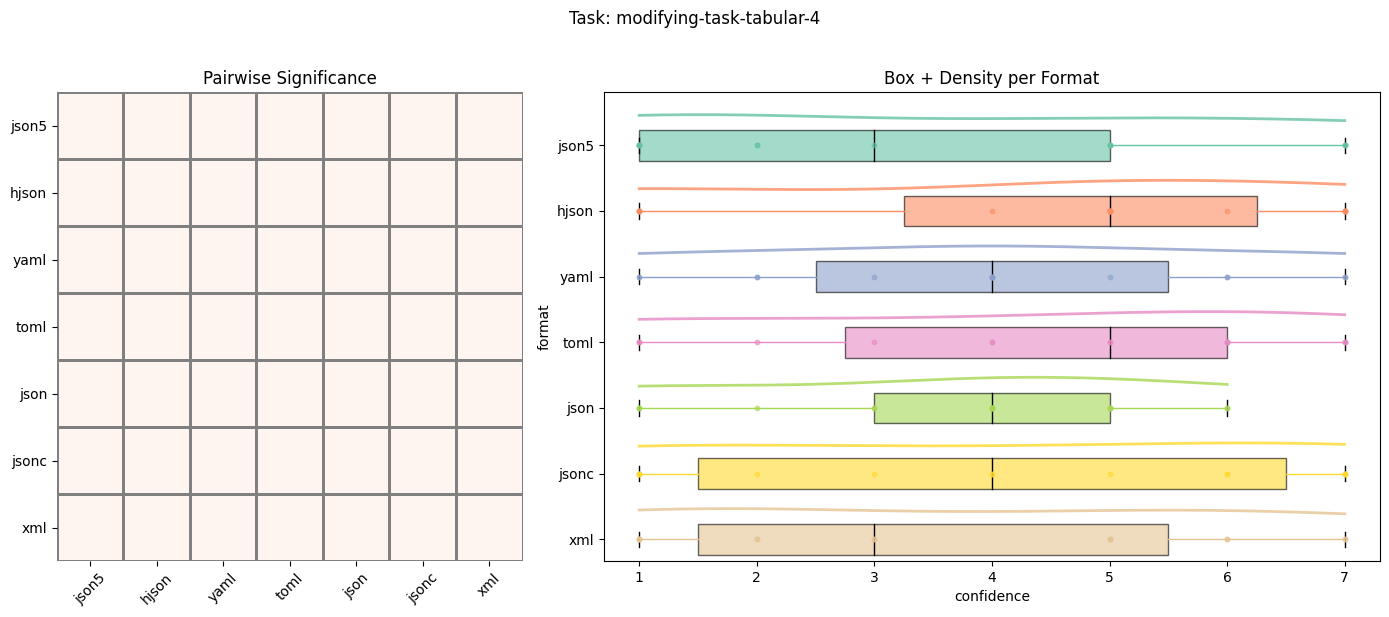

{'modifying-task-tabular-1': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      16  5.875000  1.586401     6.0  1.0  7.0
  json       18  4.166667  1.917412     4.0  1.0  7.0
  json5      16  5.562500  1.860779     6.0  1.0  7.0
  jsonc      15  5.133333  1.846490     5.0  1.0  7.0
  toml       16  5.312500  1.701715     6.0  2.0  7.0
  xml        16  4.062500  2.048373     4.5  1.0  7.0
  yaml       15  4.866667  2.231805     6.0  1.0  7.0,
  'overall_p': 0.05502852056984612,
  'effect_size': 0.10886020595288473,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'modifying-task-tabular-2': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  m

In [87]:
vis_box_comparasion(
    df_post,
    group_col='format',
    value_col='confidence',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
    # discrete_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5'],
    # continuous_tasks=['reading-task']
)

post_c_results = compare_statistically(
    df_post,
    group_col='format',
    value_col='confidence',
    method='anova',
    task_col='task'
    # discrete_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5'],
    # continuous_tasks=['reading-task']
)

post_c_results

In [18]:
df_post_reading= df_post[df_post['task'].str.contains('reading-task')]
df_post_reading

,participantId,format,task,startTime,endTime,duration_sec,difficulty,confidence
1,64457bc906c125cebd4bf66b,json5,reading-task-tabular-1,1746560035266,1746560041262,5.996,4.0,4.0
2,64457bc906c125cebd4bf66b,json5,reading-task-tabular-2,1746560114063,1746560124630,10.567,4.0,3.0
3,64457bc906c125cebd4bf66b,json5,reading-task-tabular-3,1746560149554,1746560157039,7.485,5.0,3.0
4,64457bc906c125cebd4bf66b,json5,reading-task-tabular-4,1746560183791,1746560189177,5.386,3.0,5.0
5,64457bc906c125cebd4bf66b,json5,reading-task-tabular-5,1746560285964,1746560293926,7.962,6.0,2.0
...,...,...,...,...,...,...,...,...
1222,6675c40cdc52b37294f0514e,hjson,reading-task-tabular-1,1746233901886,1746233907086,5.200,1.0,7.0
1223,6675c40cdc52b37294f0514e,hjson,reading-task-tabular-2,1746233960319,1746233966574,6.255,1.0,7.0
1224,6675c40cdc52b37294f0514e,hjson,reading-task-tabular-3,1746233996159,1746234000741,4.582,1.0,6.0
1225,6675c40cdc52b37294f0514e,hjson,reading-task-tabular-4,1746234202776,1746234212235,9.459,2.0,6.0


### correct vs difficulty/confidence

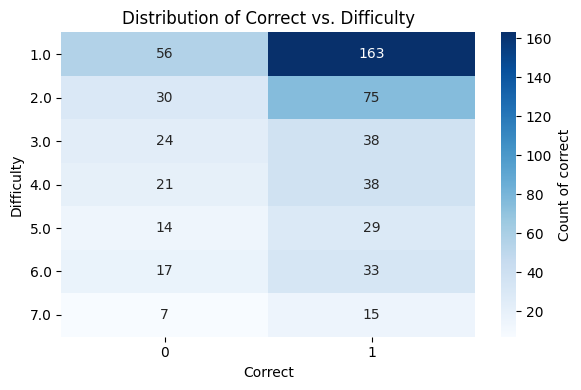

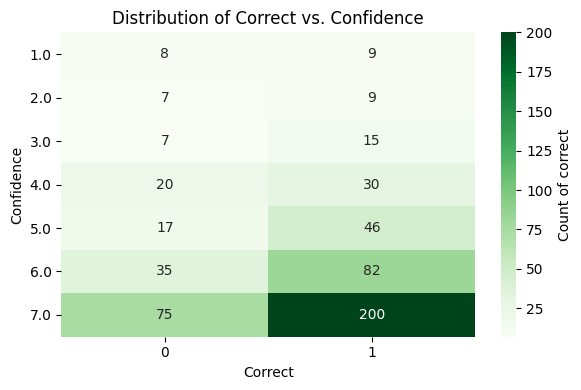

In [19]:
# 比较 correct(0/1) vs difficulty
df_post_reading= df_post[df_post['task'].str.contains('reading-task')]

plot_binary_response_vs_metric_heatmap(
    df_post      = df_post_reading,
    df_result    = df_reading_result,
    participant_col='participantId',
    format_col     ='format',
    task_col       ='task',
    response_col   ='correct',
    metric_col     ='difficulty',
    response_values=[0,1],    # 二元回答
    cmap='Blues'
)

# 比较 correct(0/1) vs confidence
plot_binary_response_vs_metric_heatmap(
    df_post      = df_post_reading,
    df_result    = df_reading_result,
    participant_col='participantId',
    format_col     ='format',
    task_col       ='task',
    response_col   ='correct',
    metric_col     ='confidence',
    response_values=[0,1],
    cmap='Greens'
)


##  Nasa TlX Analysis

### statistical test

In [20]:
df_nasa = analyze_nasa_and_post_surveys(all_data)
df_nasa['task']='nasaltx'
df_nasa_tidy = melt_tlx(df_nasa)
df_nasa_tidy

,participantId,format,startTime,endTime,duration_sec,task,score
0,64457bc906c125cebd4bf66b,json5,1746562427809,1746562451027,23.218,mental-demand,93.0
1,6697c8b6d9d7baa7edd8c4d3,hjson,1745933947314,1745933980430,33.116,mental-demand,90.0
2,67e25388d573ec2d5f1c8442,yaml,1746148170240,1746148206380,36.140,mental-demand,90.0
3,67e5cf90b79d0874e1cf16b0,toml,1746147492250,1746147510048,17.798,mental-demand,97.0
4,67d00f24466a67ba7e41228e,toml,1745933364792,1745933382986,18.194,mental-demand,79.0
...,...,...,...,...,...,...,...
667,67ab650c320eccf6141d4010,jsonc,1746147500734,1746147519483,18.749,frustration,62.0
668,65fad673a546ab14baf2f8d3,json5,1745932106163,1745932137658,31.495,frustration,75.0
669,67f1c7bd6f1c4a3d8deae02f,toml,1746146632834,1746146718970,86.136,frustration,10.0
670,67adb27bd5f5776fcb16da62,hjson,1746147510098,1746147559334,49.236,frustration,55.0


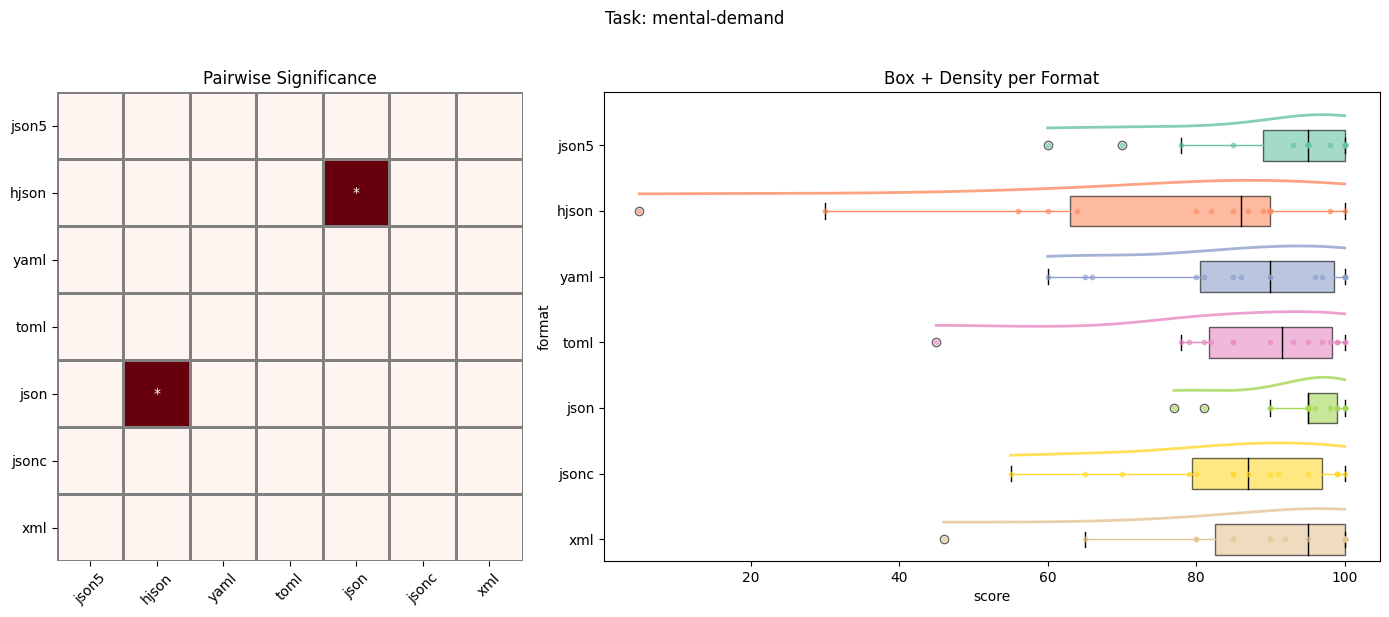

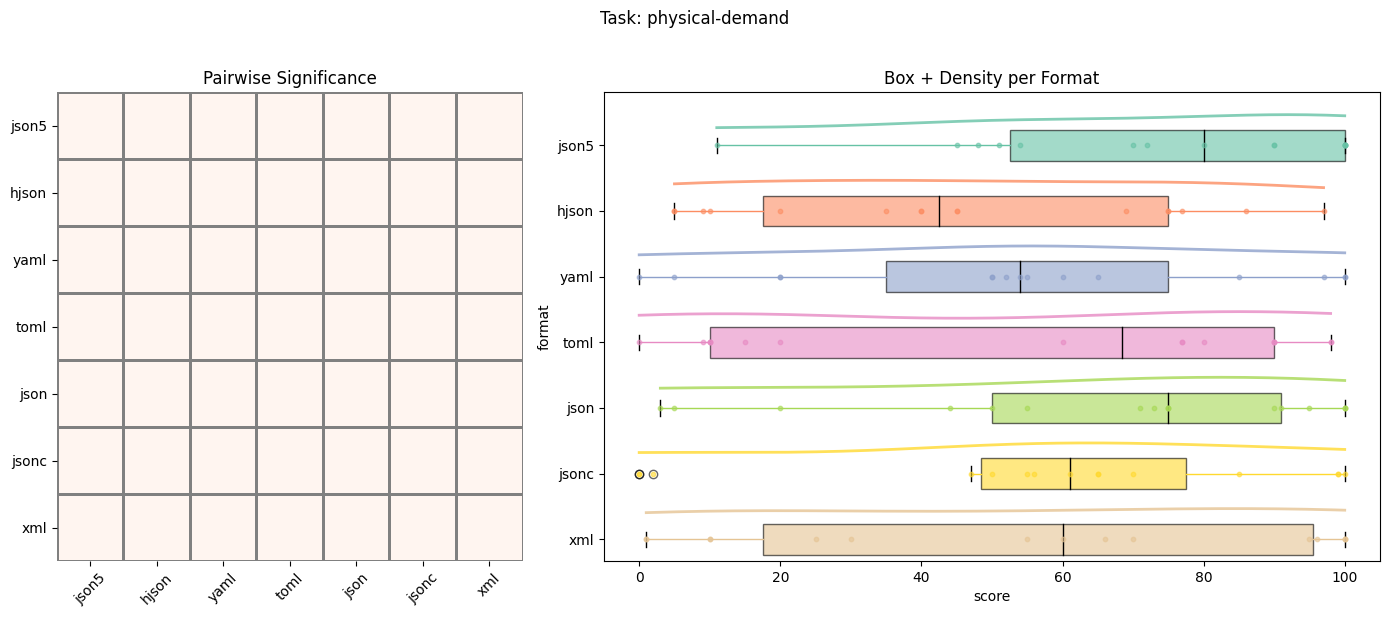

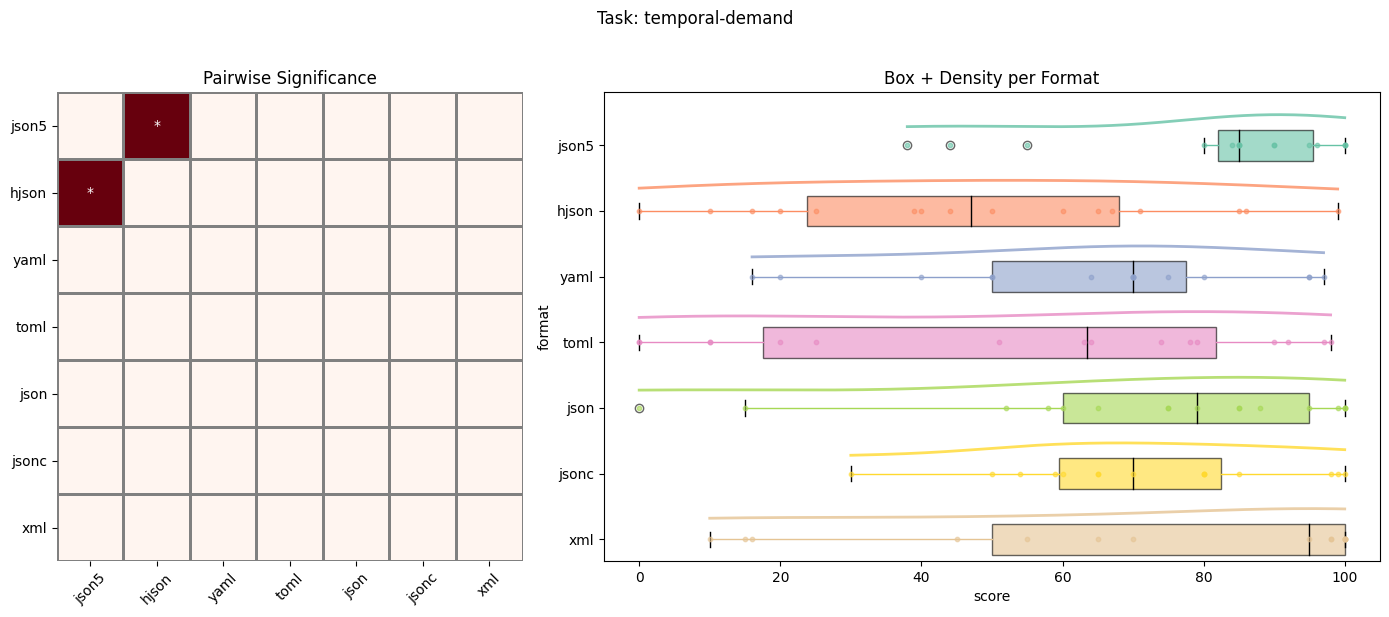

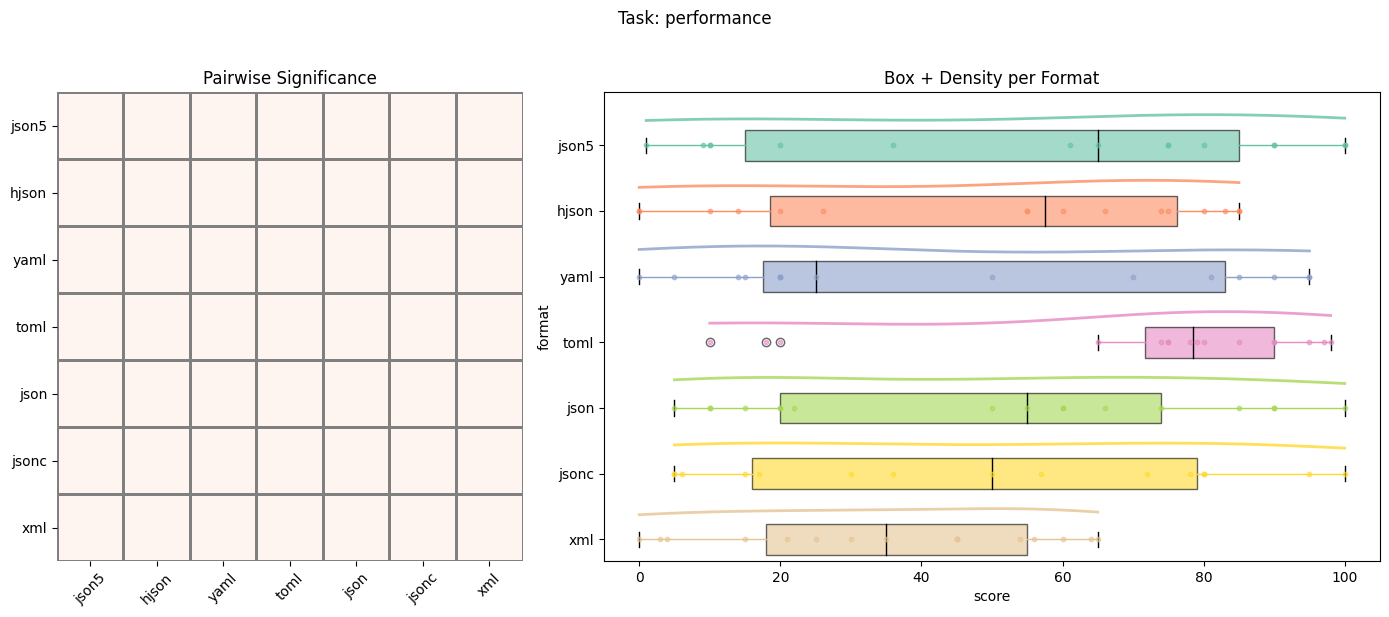

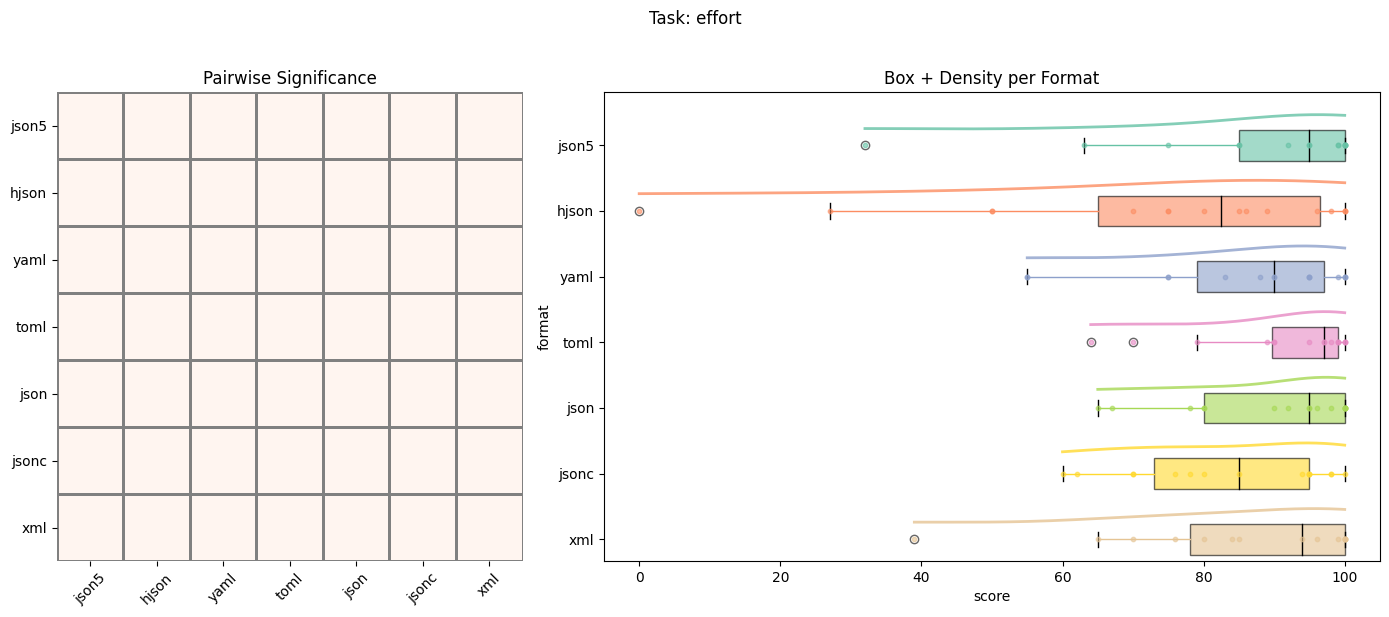

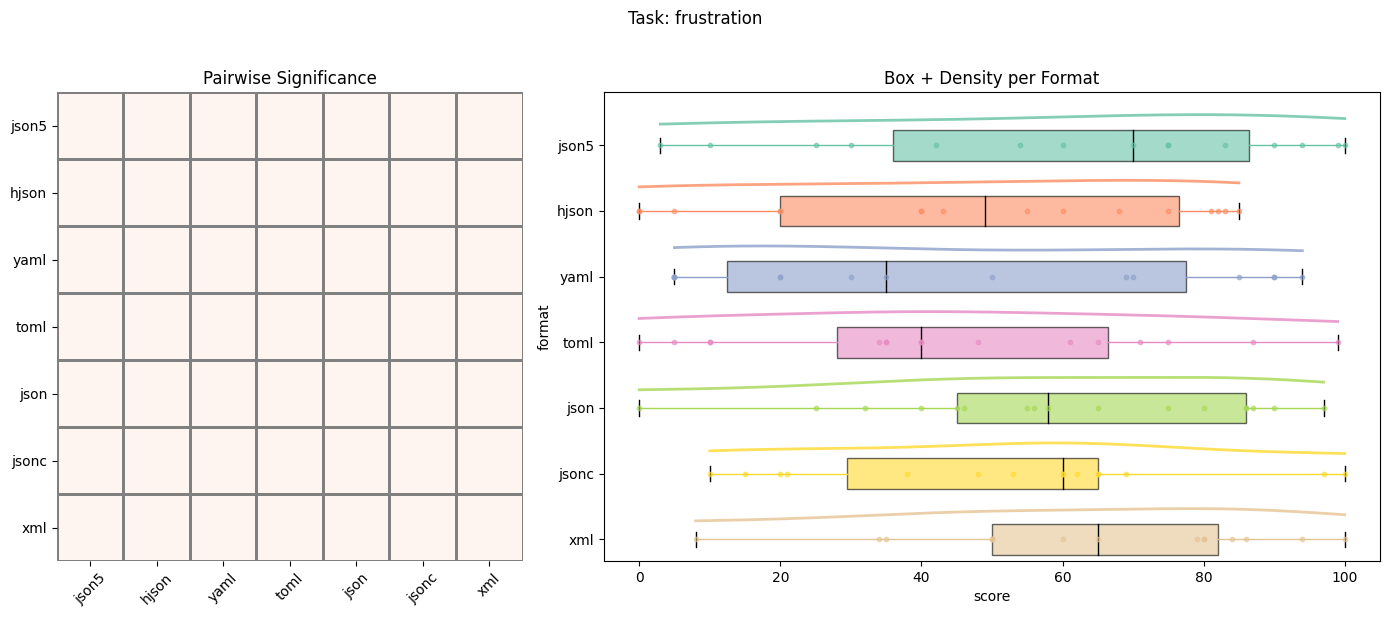

{'effort': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count       mean        std  median   min    max
  format                                                  
  hjson      16  73.812500  28.831045    82.5   0.0  100.0
  json       17  90.352941  11.858231    95.0  65.0  100.0
  json5      15  88.000000  18.943525    95.0  32.0  100.0
  jsonc      15  83.733333  13.833018    85.0  60.0  100.0
  toml       16  91.625000  11.212344    97.0  64.0  100.0
  xml        15  85.866667  17.646799    94.0  39.0  100.0
  yaml       15  86.333333  15.135892    90.0  55.0  100.0,
  'overall_p': 0.11086136660012118,
  'effect_size': 0.09470797277703996,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'frustration': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count       mean        std

In [21]:
vis_box_comparasion(
    df_nasa_tidy,
    group_col='format',
    value_col='score',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

nasa_results = compare_statistically(
    df_nasa_tidy,
    group_col='format',
    value_col='score',
    method='anova',
    task_col='task'
)

nasa_results

### correct vs nasa metrics

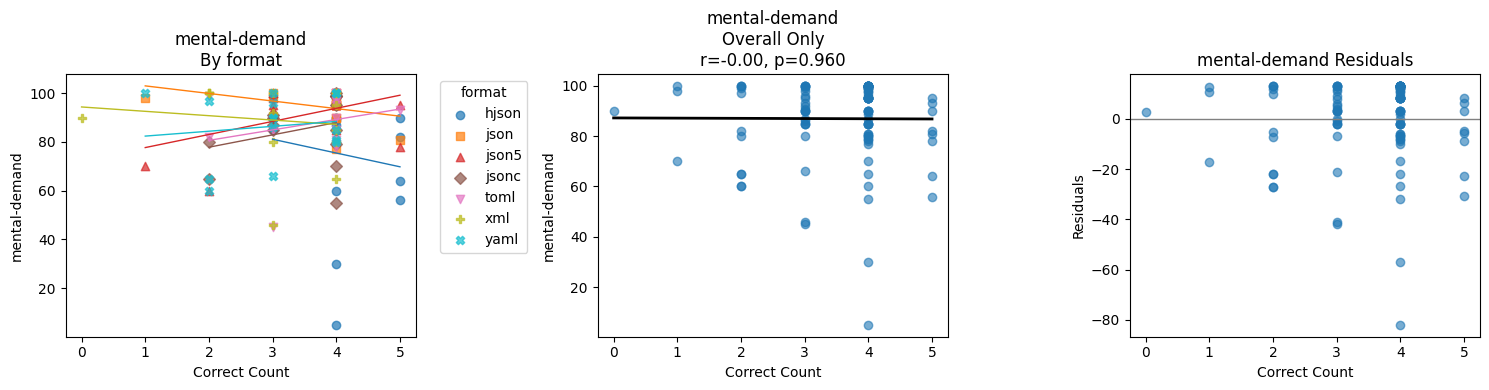

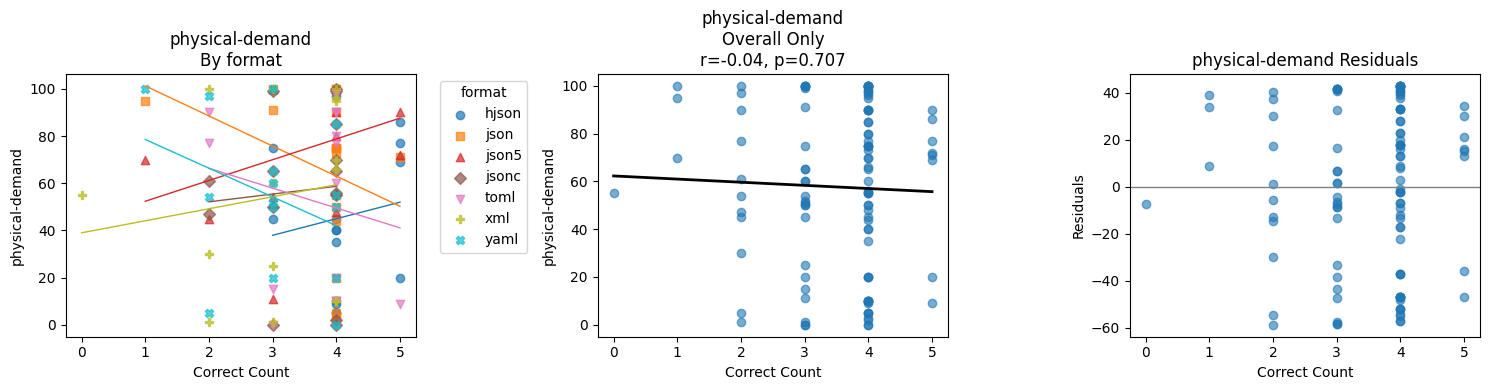

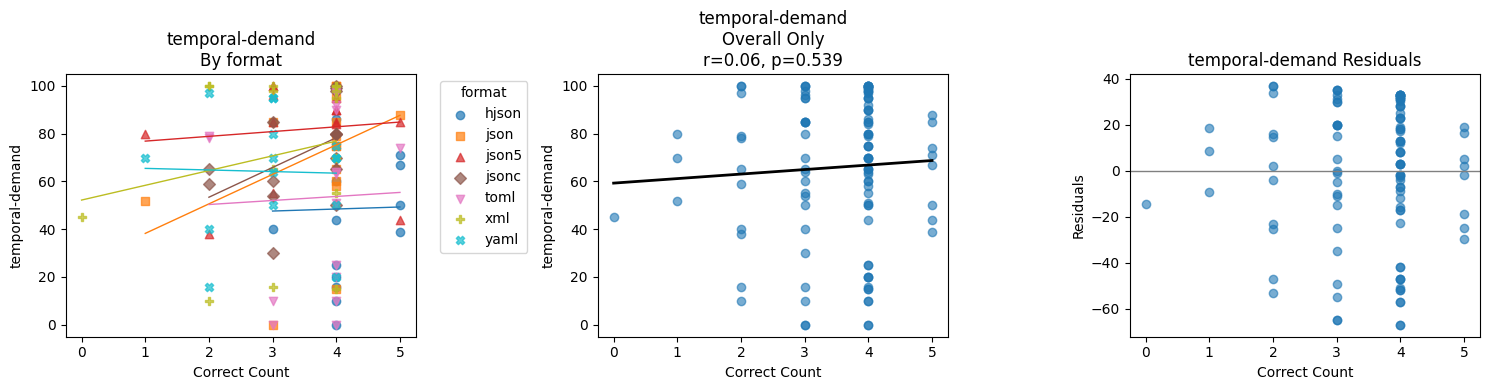

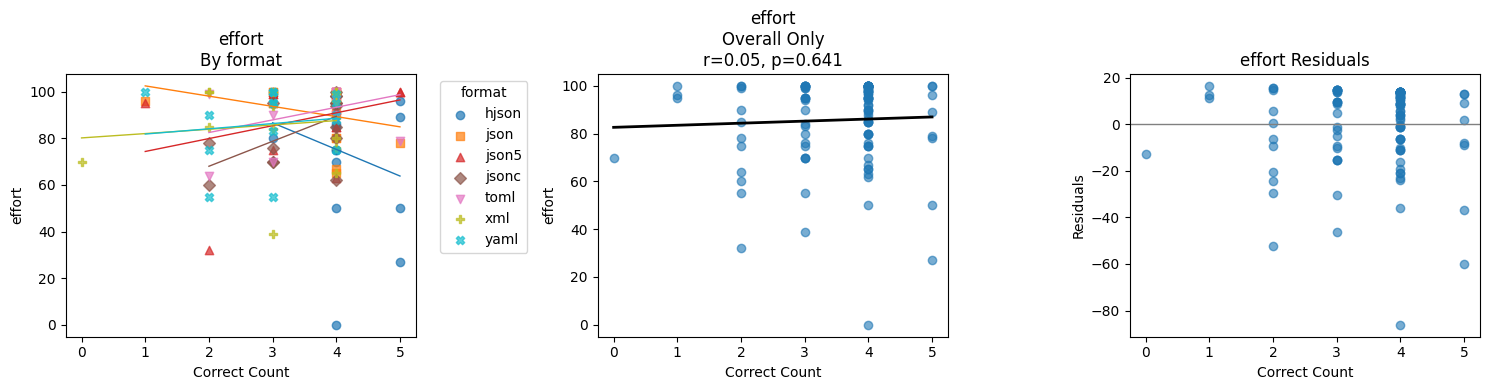

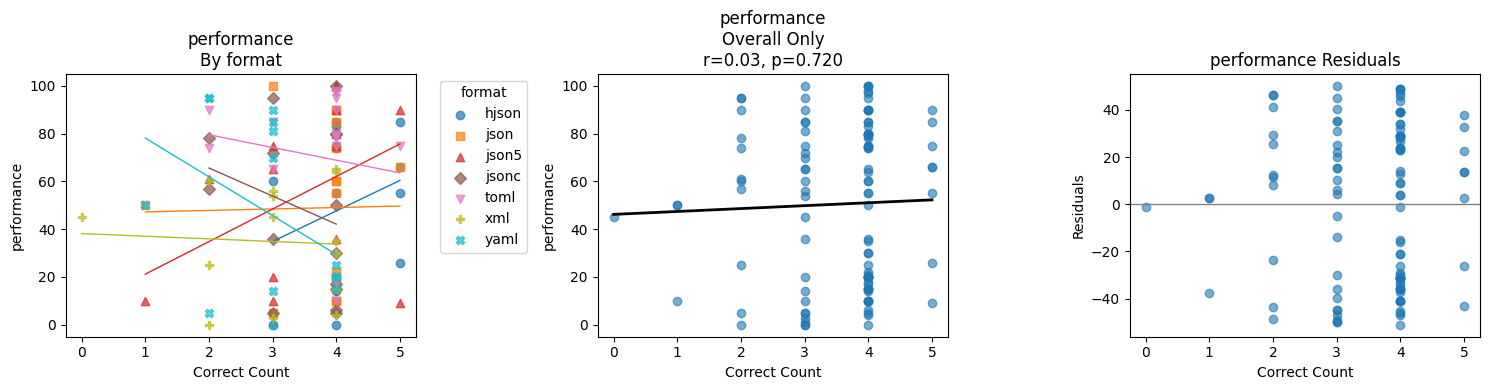

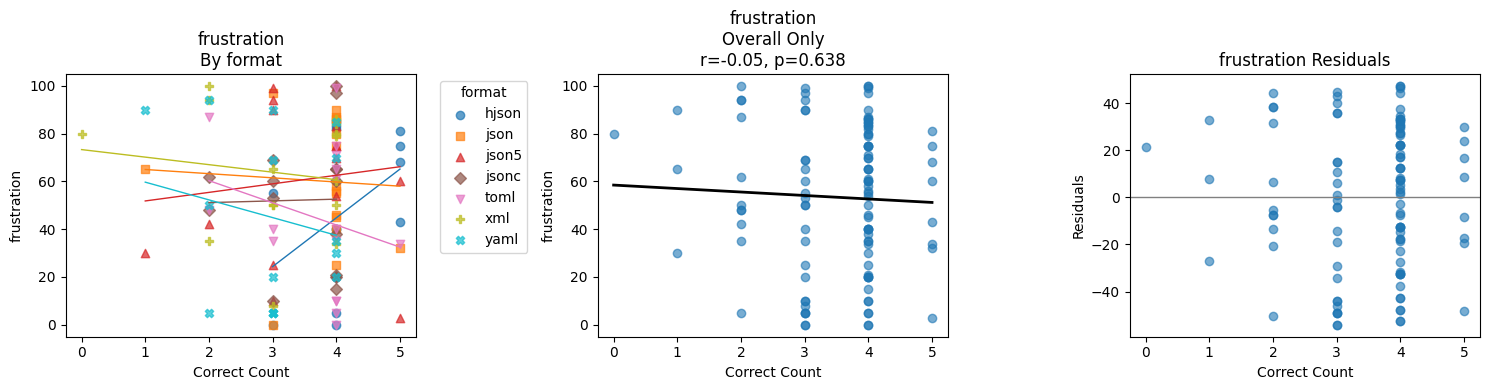

In [22]:
df_reading_agg_overall=df_reading_agg[df_reading_agg['task']=='reading-task-tabular'].copy() 

plot_nasatlx_correct(
    df_reading         = df_reading_agg_overall,
    df_nasa            = df_nasa,
    metrics            = ['mental-demand','physical-demand','temporal-demand','effort','performance','frustration'],
    group_col          = 'format',
    agg_func           = 'mean',
    show_by_format     = True,   
    show_overall       = True,  
    show_residual      = True,   
    show_overall_trend = False,  
    figsize_per        = (5,4)
)

## Quiz Analysis

### correct

In [23]:
df_quiz = evaluate_quiz_answers_from_tutorial(all_data)
df_quiz_agg = aggregate_quiz_parts(
    df_quiz,
    participant_col='participantId',
    format_col='format',
    task_col='quiz_key',
    sum_cols=['num_wrong_attempts', 'wrong_choice_count'],
    mean_cols=['correct']
)
df_quiz_summary = summarize_quiz_parts(
    df_quiz,
    participant_col='participantId',
    format_col='format',
    task_col='quiz_key',
    sum_cols=['num_wrong_attempts','wrong_choice_count'],
    mean_cols=['correct']
)
df_quiz_summary['task'] = 'tutorial_quiz'
df_quiz_summary

,participantId,format,quiz_key,num_wrong_attempts,wrong_choice_count,correct,task
0,56cb8858edf8da000b6df354,hjson,tutorial-hjson,0,0,1.0,tutorial_quiz
1,57c357770e6a1f00015f6038,json,tutorial-json,1,1,1.0,tutorial_quiz
2,5b68c9eb87af310001584803,json5,tutorial-json5,3,2,1.0,tutorial_quiz
3,5c6414540821d30001046198,hjson,tutorial-hjson,2,0,1.0,tutorial_quiz
4,5d30dfa68b1523000134878f,json,tutorial-json,3,6,1.0,tutorial_quiz
...,...,...,...,...,...,...,...
107,67f1a4f8dd44e7cd5adffa29,json5,tutorial-json5,3,5,1.0,tutorial_quiz
108,67f1c7bd6f1c4a3d8deae02f,toml,tutorial-toml,0,0,1.0,tutorial_quiz
109,67f3619e16d4ca195fbd1bd0,yaml,tutorial-yaml,3,1,1.0,tutorial_quiz
110,67f5bb69760b211cdfe8021c,jsonc,tutorial-jsonc,5,0,0.5,tutorial_quiz


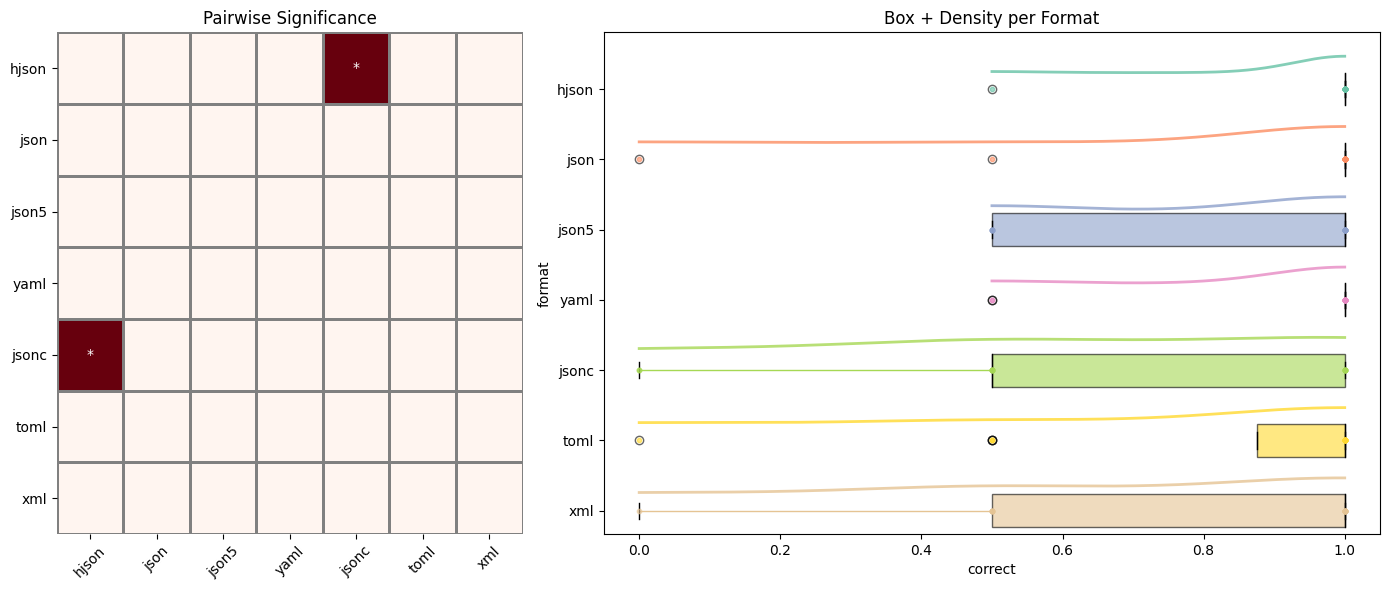

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  0.968750  0.125000     1.0  0.5  1.0
 json       18  0.916667  0.257248     1.0  0.0  1.0
 json5      16  0.843750  0.239357     1.0  0.5  1.0
 jsonc      15  0.666667  0.361873     0.5  0.0  1.0
 toml       16  0.843750  0.301040     1.0  0.0  1.0
 xml        16  0.781250  0.314576     1.0  0.0  1.0
 yaml       15  0.933333  0.175933     1.0  0.5  1.0,
 'overall_p': 0.03504735609280172,
 'effect_size': 0.11900545568374922,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.9974        False   hjson vs json is not significant
 1   hjson  json5   0.8323        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.0308         True      hjson vs jsonc is significant
 3   hjson   toml   0.8323  

In [24]:
## correct
vis_box_comparasion(
    df_quiz_summary,
    group_col='format',
    value_col='correct',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

quiz_correct_results = compare_statistically(
    df_quiz_summary,
    group_col='format',
    value_col='correct',
    method='anova',
    task_col='task'
)

quiz_correct_results


### num wrong attempts

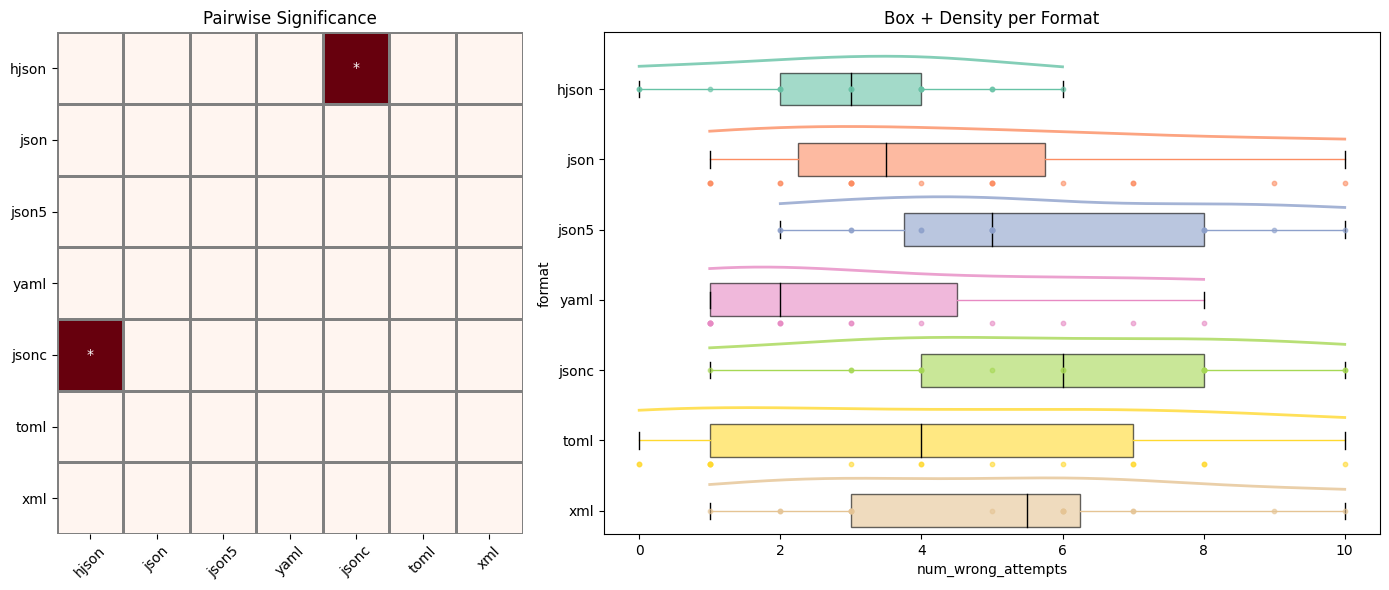

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  3.000000  1.751190     3.0    0    6
 json       18  4.277778  2.696524     3.5    1   10
 json5      16  5.375000  2.500000     5.0    2   10
 jsonc      15  5.866667  2.722044     6.0    1   10
 toml       16  4.125000  3.263434     4.0    0   10
 xml        16  4.937500  2.619637     5.5    1   10
 yaml       15  3.133333  2.356349     2.0    1    8,
 'overall_p': 0.017886065192889086,
 'effect_size': 0.13346844498877916,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.7829        False   hjson vs json is not significant
 1   hjson  json5   0.1403        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.0417         True      hjson vs jsonc is significant
 3   hjson   toml   0.8826 

In [25]:
## num_wrong_attempts
vis_box_comparasion(
    df_quiz_summary,
    group_col='format',
    value_col='num_wrong_attempts',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

quiz_attempt_results = compare_statistically(
    df_quiz_summary,
    group_col='format',
    value_col='num_wrong_attempts',
    method='anova',
    task_col='task'
)

quiz_attempt_results

### wrong choice count

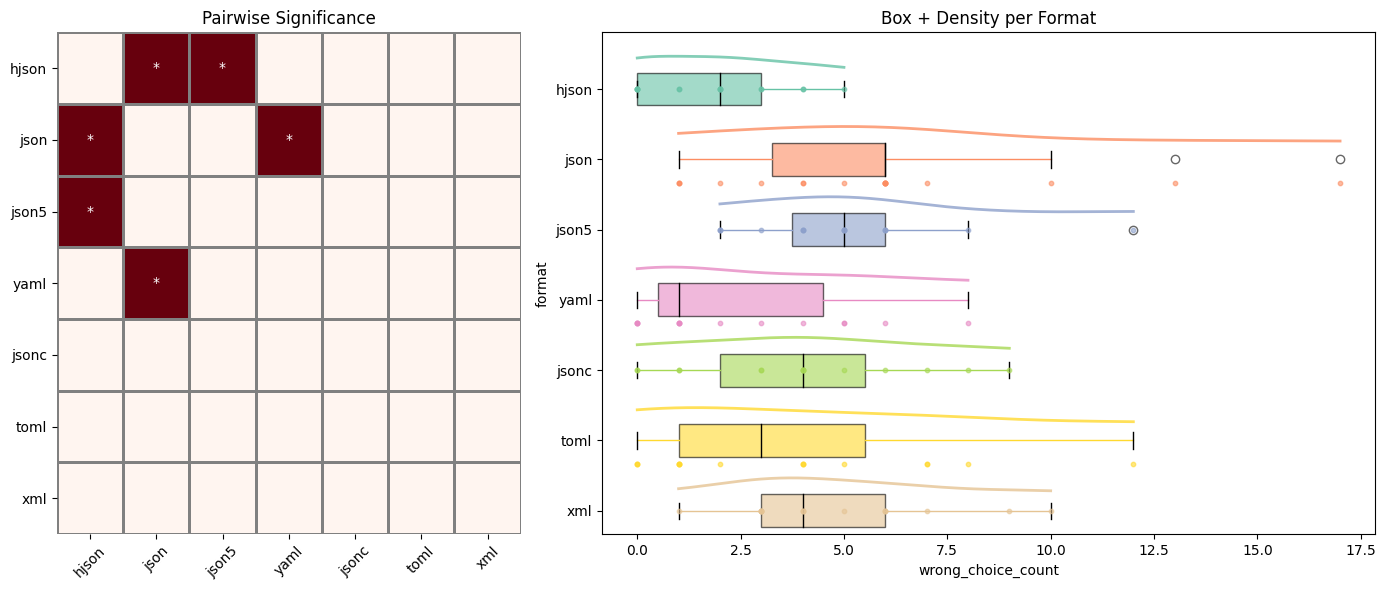

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  1.812500  1.641899     2.0    0    5
 json       18  5.777778  4.166471     6.0    1   17
 json5      16  4.937500  2.515784     5.0    2   12
 jsonc      15  3.933333  2.763710     4.0    0    9
 toml       16  3.562500  3.501785     3.0    0   12
 xml        16  4.812500  2.400521     4.0    1   10
 yaml       15  2.466667  2.559762     1.0    0    8,
 'overall_p': 0.001761841859887721,
 'effect_size': 0.17902220483790934,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.0027         True       hjson vs json is significant
 1   hjson  json5   0.0482         True      hjson vs json5 is significant
 2   hjson  jsonc   0.4109        False  hjson vs jsonc is not significant
 3   hjson   toml   0.6235 

In [26]:
## wrong_choice_count
vis_box_comparasion(
    df_quiz_summary,
    group_col='format',
    value_col='wrong_choice_count',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

quiz_choice_results = compare_statistically(
    df_quiz_summary,
    group_col='format',
    value_col='wrong_choice_count',
    method='anova',
    task_col='task'
)

quiz_choice_results

In [27]:
# first_key, first_value = list(all_data.items())[0]
# first_item = { first_key: first_value }
# first_item

## Post Task Survey Analysis

### clean data

In [16]:
df_post_survy_format= extract_post_task_tlx_responses(all_data, df_part )
questions_1 = ['q9','q13','q14']
sub_df_1 = extract_survey_items(
    df_post_survy_format,
    items=questions_1,
    id_col='participantId',
    format_col='format'
)
sub_df_1


,participantId,format,q9,q13,q14
0,64457bc906c125cebd4bf66b,json5,High School,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
1,6697c8b6d9d7baa7edd8c4d3,hjson,Master's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
2,67e25388d573ec2d5f1c8442,yaml,Bachelor's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
3,67e5cf90b79d0874e1cf16b0,toml,Bachelor's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
4,67d00f24466a67ba7e41228e,toml,Master's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
...,...,...,...,...,...
107,67ab650c320eccf6141d4010,jsonc,Master's,"[Dyslexia (e.g., difficulty reading or disting...","[Color vision deficiency (CVD) (e.g., difficul..."
108,65fad673a546ab14baf2f8d3,json5,Master's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
109,67f1c7bd6f1c4a3d8deae02f,toml,Master's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
110,67adb27bd5f5776fcb16da62,hjson,Bachelor's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"


In [4]:
df_post_survy_format['q7'].unique()

array(['',
       'I carefully followed every task by manually reading, updating, and restructuring the TOML data according to each specific instruction.',
       'None', 'The help button should include more examples', 'N/A',
       'No',
       "For someone in their 60's this was quite the confusing study, as I have seen these type of lines in movies but never worked with them before, it was an exciting study, dont get me wrong I enjoyed it, but some of those explanations flew right over my head hahaha.\nBut thank you for this, expanding my knowledge is still what I enjoy! ",
       'I used my existing knowledge of Python and Java to write the code using knowledge of lists and nested lists.',
       'experienced',
       'Task was easy. It was annoying that the examples did not include any complex data structures with multiple entries. Multi-cursor being disabled was a pain for the last part.',
       "I don't have much experience with programming, I just took like one class of PHP li

In [5]:
df_post_survy_format['q8'].unique()

array(['', 'No', 'None', 'The task was very challenging',
       'Really interesting study!', 'enjoyed', 'n/a',
       "That this hjson format is not very intuitive and I'd rather just use yaml.",
       'As above', 'Nothing.', nan,
       "This was fun! I haven't programmed in a long time, so this reminded me of how fun programming can be! Maybe I'll give game programming a try again after this since I suddenly felt inspired. Also, this reminded me of modding files in video games as the format is very similar where they're more like scripts rather than full on hardcore programming. Yeah, XML files, those are common files in modding, specifically in games like Dead Island, Dead Island Riptide, and the State of Decay series which I made quite a number of mods for around a decade ago. By the way, the images were very hard to read. I tried zooming in on them but they're still so small.",
       'I am a software developer so i was familiar with JSON forrmat already ',
       'I usually for

In [6]:
df_post_survy_format['q10'].unique()

array([  0. ,  12. ,   2. ,  41. ,  20. ,   6. ,  24. ,  36. ,  80. ,
        48. ,   8. ,  62. ,  18. ,  60. , 180. ,   0.5,   4. ,   3. ,
         nan, 120. ,   1. ,  30. , 204. ,  38. ,  14. ,  56. ,  17. ,
        10. ,  76. ,  22. ,  23. ,  11. ])

In [9]:
df_null = df_post_survy_format[df_post_survy_format['q10'].isna()]
df_null

,participantId,q7,q8,q9,q12,q13,q14,q10,q11,format
27,6696a5558816d61fa5eb64dc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,json5
46,65e9fbe46ad3a93ae116ca4b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xml
74,667ac0929a79568b911c5dff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,json
78,672a844656ca03498e04cd76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,toml
106,6710c4cf3a160f87690ff9e8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xml


In [15]:
format_stat

format
json     18
json5    16
hjson    16
toml     16
xml      16
yaml     15
jsonc    15
Name: count, dtype: int64

In [14]:
df_task[df_task['participantId']=='6710c4cf3a160f87690ff9e8']

,participantId,task,startTime,endTime,duration_sec,duration_min,format
3286,6710c4cf3a160f87690ff9e8,introduction,1746154470660,1746155510885,1040.225,17.337083,xml
3287,6710c4cf3a160f87690ff9e8,qualifications,1746155511093,1746155529465,18.372,0.306200,xml
3288,6710c4cf3a160f87690ff9e8,consent,1746155529591,1746155571020,41.429,0.690483,xml
3289,6710c4cf3a160f87690ff9e8,task,1746155571745,1746155732273,160.528,2.675467,xml
3290,6710c4cf3a160f87690ff9e8,writing-task-NL,1746155732421,1746156112051,379.630,6.327167,xml
3291,6710c4cf3a160f87690ff9e8,writing-task-NL_post-task-question,1746156112264,1746156125214,12.950,0.215833,xml
3292,6710c4cf3a160f87690ff9e8,tutorial-part1,1746156125294,1746156269424,144.130,2.402167,xml
3293,6710c4cf3a160f87690ff9e8,tutorial-part2,1746156269512,1746158022001,1752.489,29.208150,xml
3294,6710c4cf3a160f87690ff9e8,reading-task-tabular-1,1746158022462,1746158035248,12.786,0.213100,xml
3295,6710c4cf3a160f87690ff9e8,reading-task-tabular-1_post-task-question,1746158035433,1746158044479,9.046,0.150767,xml


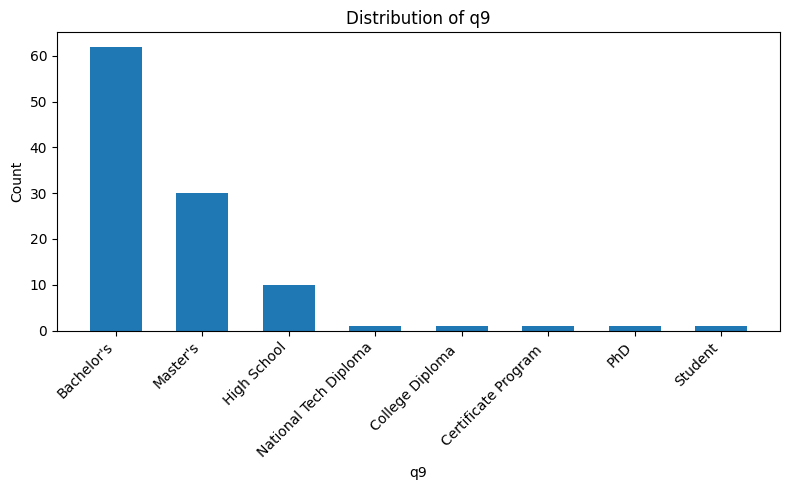

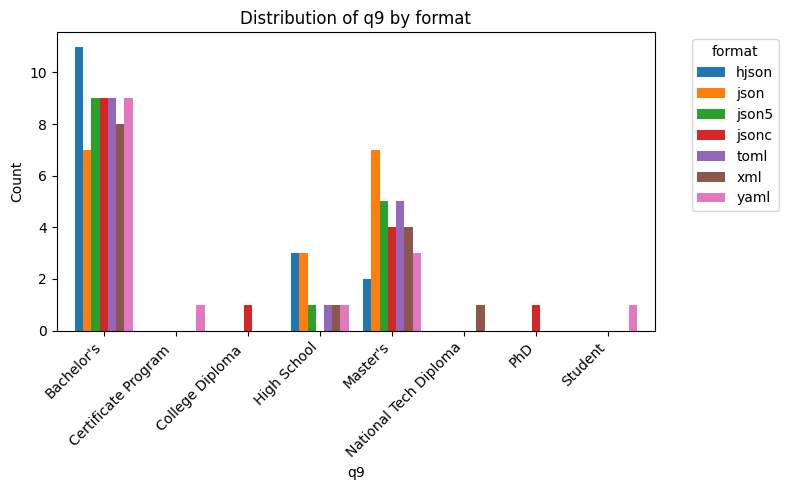

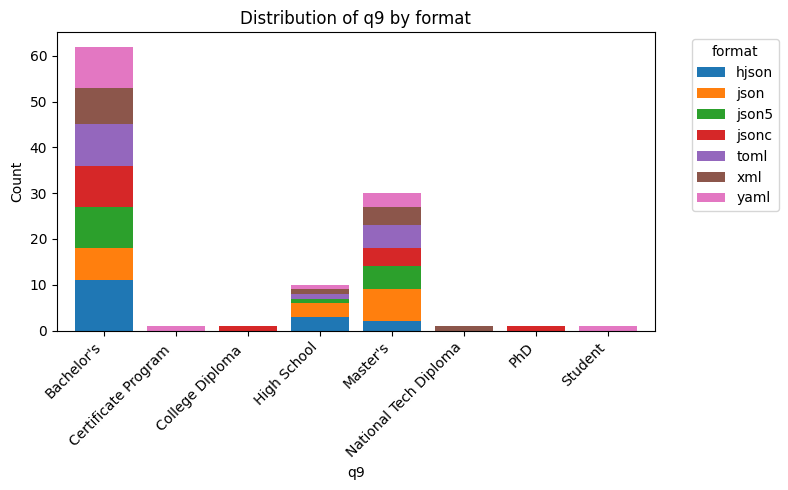

In [29]:
# q9 distribution
plot_answer_distribution(sub_df_1, question='q9')
# q9 distribution by format 
plot_answer_distribution(sub_df_1, question='q9', group_by='format')
# stacked q9 distribution by format
plot_answer_distribution(sub_df_1, question='q9', group_by='format', stacked=True)

In [30]:
# cnt = get_answer_counts(sub_df, question='q13')
# cnt_by_fmt = get_answer_counts(sub_df, question='q13', group_by='format')

cnt_13 = get_answer_counts(sub_df_1, question='q13')
print(cnt_13)

cnt_14 = get_answer_counts(sub_df_1, question='q14')
print(cnt_14)

q13
No, I do not have any cognitive-related conditions.                                    101
Prefer not to say.                                                                       2
Dyslexia (e.g., difficulty reading or distinguishing symbols, such as "b" and "d").      2
ADHD if it counts                                                                        1
Dysgraphia (e.g., difficulty with handwriting or written expression).                    1
Name: count, dtype: int64
q14
No, I do not have any related conditions.                                                     106
Prefer not to say.                                                                              1
Color vision deficiency (CVD) (e.g., difficulty distinguishing colors like red and green).      1
Name: count, dtype: int64


In [31]:
questions_2 = ['q10_years','q11']
sub_df_2 = extract_survey_items(
    df_post_survy_format,
    items=questions_2,
    id_col='participantId',
    format_col='format'
)
mapping = {
    'Not familiar at all': 1,
    'Somewhat familiar'  : 2,
    'Very familiar'      : 3
}

sub_df_2['q11_code'] = sub_df_2['q11'].map(mapping)

sub_df_2

,participantId,format,q10,q11,q11_code
0,64457bc906c125cebd4bf66b,json5,0.0,Not familiar at all,1.0
1,6697c8b6d9d7baa7edd8c4d3,hjson,12.0,Not familiar at all,1.0
2,67e25388d573ec2d5f1c8442,yaml,2.0,Somewhat familiar,2.0
3,67e5cf90b79d0874e1cf16b0,toml,41.0,Very familiar,3.0
4,67d00f24466a67ba7e41228e,toml,20.0,Somewhat familiar,2.0
...,...,...,...,...,...
107,67ab650c320eccf6141d4010,jsonc,10.0,Somewhat familiar,2.0
108,65fad673a546ab14baf2f8d3,json5,24.0,Not familiar at all,1.0
109,67f1c7bd6f1c4a3d8deae02f,toml,48.0,Very familiar,3.0
110,67adb27bd5f5776fcb16da62,hjson,6.0,Somewhat familiar,2.0


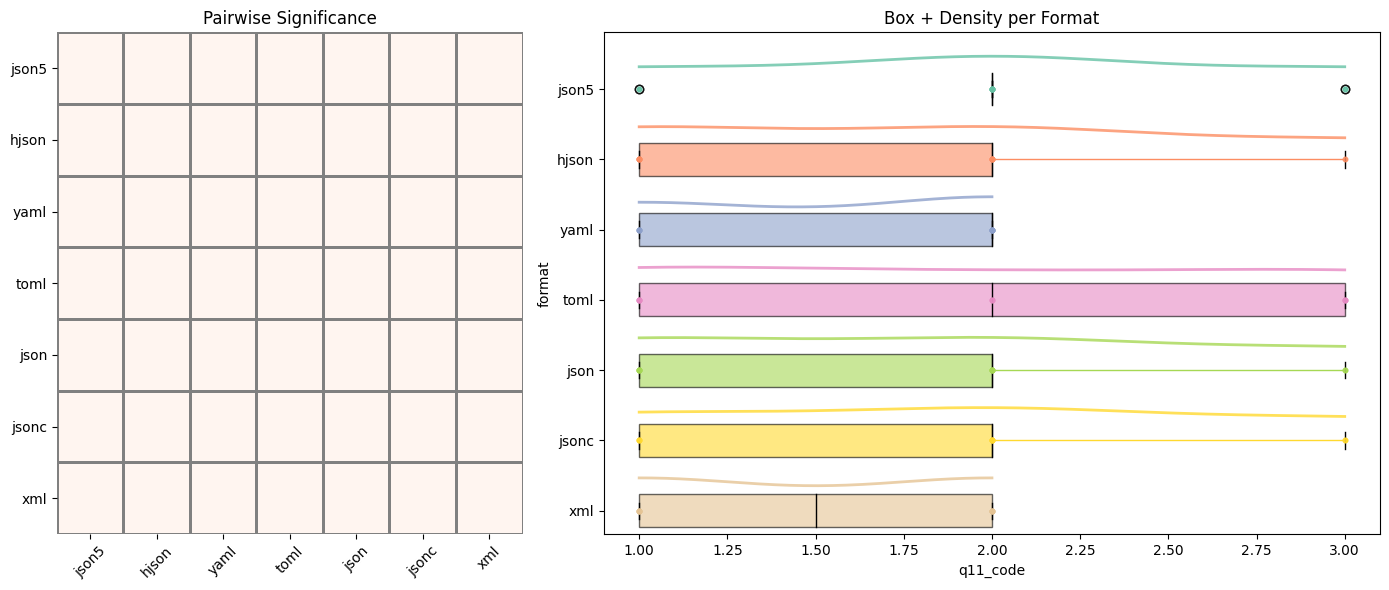

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  1.687500  0.704154     2.0  1.0  3.0
 json       17  1.764706  0.752447     2.0  1.0  3.0
 json5      15  2.000000  0.654654     2.0  1.0  3.0
 jsonc      15  1.866667  0.743223     2.0  1.0  3.0
 toml       15  1.933333  0.883715     2.0  1.0  3.0
 xml        14  1.500000  0.518875     1.5  1.0  2.0
 yaml       15  1.600000  0.507093     2.0  1.0  2.0,
 'overall_p': 0.4296826216354631,
 'effect_size': 0.0566057816988688,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [85]:
sub_df_2['task'] = 'package'
vis_box_comparasion(
    sub_df_2,
    group_col='format',
    value_col='q11_code',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

q11_results = compare_statistically(
    sub_df_2,
    group_col='format',
    value_col='q11_code',
    method='anova',
    task_col='task'
)

q11_results

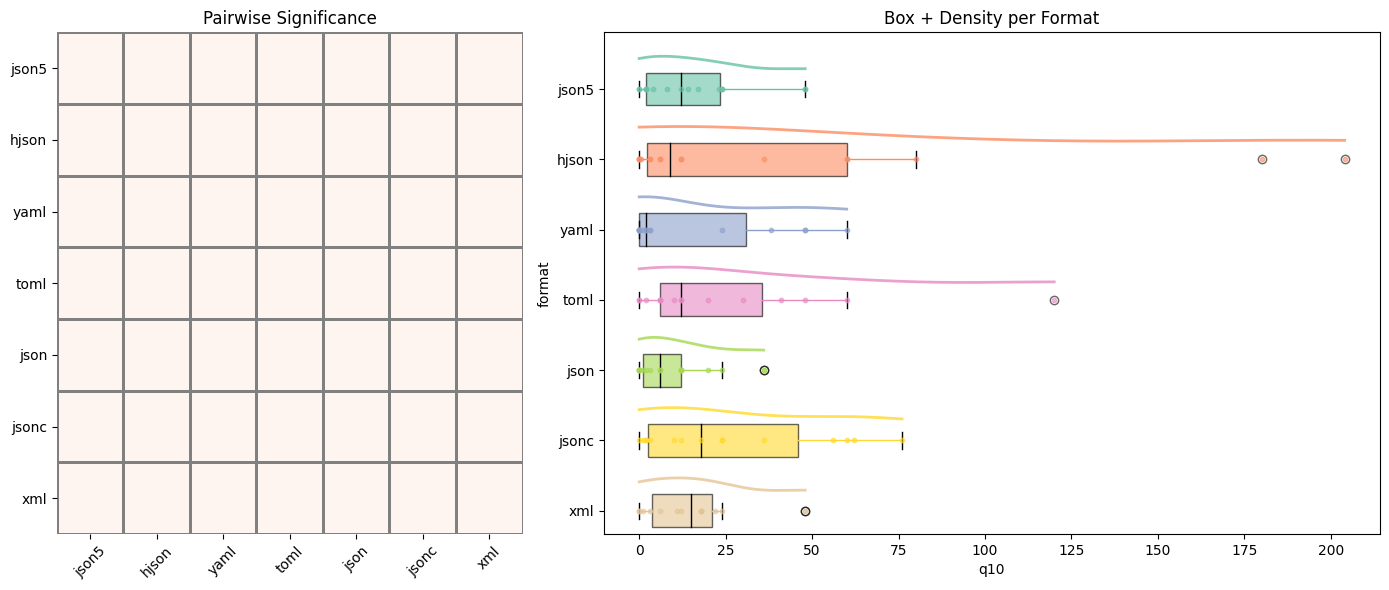

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count       mean        std  median  min    max
 format                                                 
 hjson      16  41.406250  64.217656     9.0  0.0  204.0
 json       17  10.705882  11.941339     6.0  0.0   36.0
 json5      15  15.200000  15.911362    12.0  0.0   48.0
 jsonc      15  25.733333  25.990291    18.0  0.0   76.0
 toml       15  24.866667  32.193315    12.0  0.0  120.0
 xml        14  16.357143  15.702068    15.0  0.0   48.0
 yaml       15  15.266667  21.972277     2.0  0.0   60.0,
 'overall_p': 0.13104705132962893,
 'effect_size': 0.09209076044278754,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [86]:
vis_box_comparasion(
    sub_df_2,
    group_col='format',
    value_col='q10_years',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

q10_results = compare_statistically(
    sub_df_2,
    group_col='format',
    value_col='q10_years',
    method='anova',
    task_col='task'
)

q10_results

In [32]:
## q12
df_encoded, df_familiar = extract_and_encode_familiarity(df_post_survy_format)
df_familiar['task']='survey'
df_familiar


,participantId,format,familiarity,task
0,64457bc906c125cebd4bf66b,json5,1.0,survey
1,6697c8b6d9d7baa7edd8c4d3,hjson,2.0,survey
2,67e25388d573ec2d5f1c8442,yaml,2.0,survey
3,67e5cf90b79d0874e1cf16b0,toml,1.0,survey
4,67d00f24466a67ba7e41228e,toml,2.0,survey
...,...,...,...,...
107,67ab650c320eccf6141d4010,jsonc,3.0,survey
108,65fad673a546ab14baf2f8d3,json5,2.0,survey
109,67f1c7bd6f1c4a3d8deae02f,toml,4.0,survey
110,67adb27bd5f5776fcb16da62,hjson,3.0,survey


### familarity

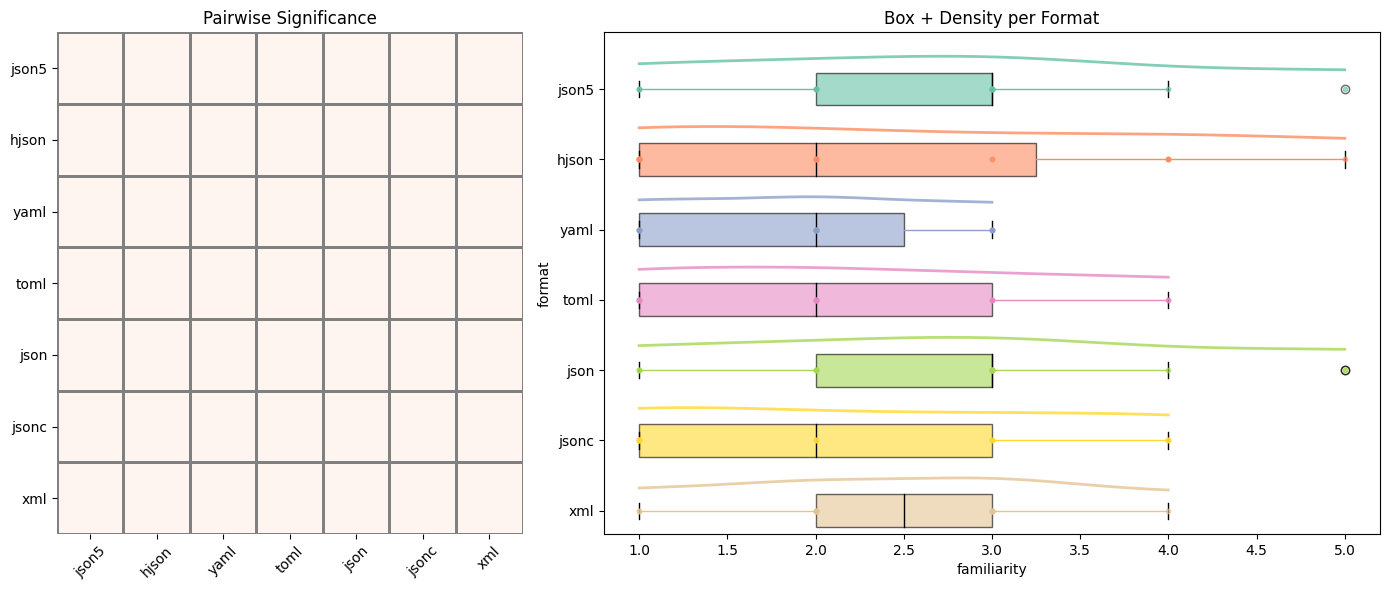

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  2.312500  1.352467     2.0  1.0  5.0
 json       17  2.705882  1.212678     3.0  1.0  5.0
 json5      15  2.533333  1.125463     3.0  1.0  5.0
 jsonc      15  2.200000  1.207122     2.0  1.0  4.0
 toml       15  2.133333  1.060099     2.0  1.0  4.0
 xml        14  2.428571  0.851631     2.5  1.0  4.0
 yaml       15  1.933333  0.798809     2.0  1.0  3.0,
 'overall_p': 0.5272429253479289,
 'effect_size': 0.04906097953537208,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [83]:
vis_box_comparasion(
    df_familiar,
    group_col='format',
    value_col='familiarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

familiar_results = compare_statistically(
    df_familiar,
    group_col='format',
    value_col='familiarity',
    method='anova',
    task_col='task'
)

familiar_results


## Time Correctness Anlaysis

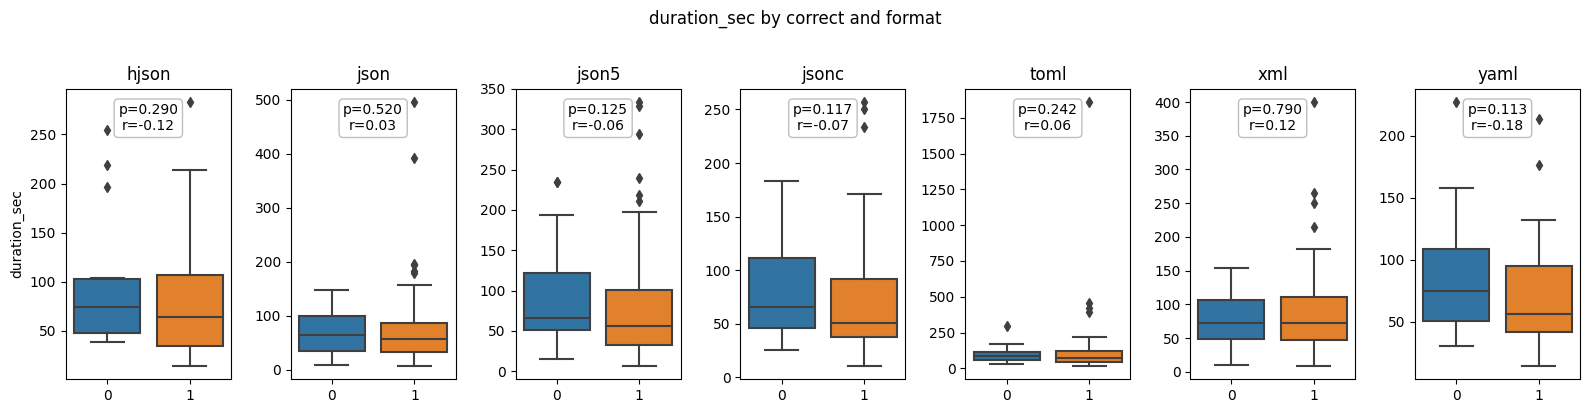

In [34]:
plot_duration_vs_correct_with_stats(
    df_post      = df_reading_result,
    df_result    = df_reading_result,
    participant_col='participantId',
    format_col     ='format',
    task_col       ='task',
    time_col       ='duration_sec',      # 连续时间列
    response_col   ='correct',         
    by_format      = True              # 按 format 分面
)


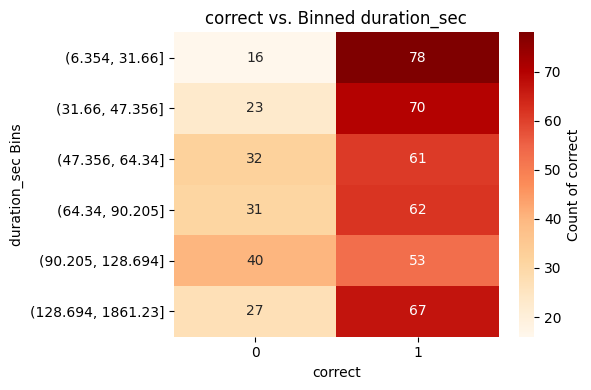

In [35]:
plot_time_vs_response_heatmap(
    df_post      = df_reading_result,
    df_result    = df_reading_result,
    participant_col='participantId',
    format_col     ='format',
    task_col       ='task',
    time_col       ='duration_sec',
    response_col   ='correct',
    bins           = 6,
    cmap           ='OrRd'
)


## Writing Task Correctness 

### data prepare

In [37]:
df_json=df_writing[df_writing['format']=='json']
df_jsonc=df_writing[df_writing['format']=='jsonc']
df_json5=df_writing[df_writing['format']=='json5']
df_hjson=df_writing[df_writing['format']=='hjson']
df_toml=df_writing[df_writing['format']=='toml']
df_yaml=df_writing[df_writing['format']=='yaml']
df_xml=df_writing[df_writing['format']=='xml']


gold_dict_json = '''{
  "patients": [
    {"name":"John","tests":[{"id":1,"result":"Normal"},{"id":2,"result":"Elevated Cholesterol"}]},
    {"name":"Michael","tests":[{"id":1,"result":"Normal"}],"treatment":"Regular Monitoring"}
  ]
}'''

gold_dict_jsonc = '''{
  "patients": [
    {"name":"John","tests":[{"id":1,"result":"Normal"},{"id":2,"result":"Elevated Cholesterol"}]},
    {"name":"Michael","tests":[{"id":1,"result":"Normal"}],"treatment":"Regular Monitoring"}
  ]
}'''


gold_dict_hjson = '''
patients:
[
  {
    name: John
    tests:
    [
      {
        id: 1
        result: Normal
      }
      {
        id: 2
        result: Elevated Cholesterol
      }
    ]
  }
  {
    name: Michael
    tests:
    [
      {
        id: 1
        result: Normal
      }
    ]
    treatment: Regular Monitoring
  }
]
'''

gold_dict_json5 = '''
{
  patients: [
    {
      name: "John",
      tests: [
        { id: 1, result: "Normal" },
        { id: 2, result: "Elevated Cholesterol" },
      ],
    },
    {
      name: "Michael",
      tests: [
        { id: 1, result: "Normal" },
      ],
      treatment: "Regular Monitoring",
    },
  ],
}
'''

gold_dict_yaml = '''
patients:
  - name: John
    tests:
      - id: 1
        result: Normal
      - id: 2
        result: Elevated Cholesterol
  - name: Michael
    tests:
      - id: 1
        result: Normal
    treatment: Regular Monitoring
'''

gold_dict_toml = '''
[[patients]]
name = "John"

  [[patients.tests]]
  id = 1
  result = "Normal"

  [[patients.tests]]
  id = 2
  result = "Elevated Cholesterol"

[[patients]]
name = "Michael"
treatment = "Regular Monitoring"

  [[patients.tests]]
  id = 1
  result = "Normal"
'''

gold_dict_xml = '''
<patients>
  <patient>
    <name>John</name>
    <tests>
      <test>
        <id>1</id>
        <result>Normal</result>
      </test>
      <test>
        <id>2</id>
        <result>Elevated Cholesterol</result>
      </test>
    </tests>
  </patient>
  <patient>
    <name>Michael</name>
    <tests>
      <test>
        <id>1</id>
        <result>Normal</result>
      </test>
    </tests>
    <treatment>Regular Monitoring</treatment>
  </patient>
</patients>
'''

### show results

In [38]:
json_result = process_dataframe_with_validation(df_json, gold_dict_json)
jsonc_result = process_dataframe_with_validation(df_jsonc, gold_dict_jsonc)
json5_result = process_dataframe_with_validation(df_json5, gold_dict_json5)
hjson_result = process_dataframe_with_validation(df_hjson, gold_dict_hjson)
toml_result = process_dataframe_with_validation(df_toml, gold_dict_toml)
yaml_result = process_dataframe_with_validation(df_yaml, gold_dict_yaml)
xml_result = process_dataframe_with_validation(df_xml, gold_dict_xml)
# json_result.sort_values(by='similarity', ascending=False)
# jsonc_result.sort_values(by='similarity', ascending=False)
# json5_result.sort_values(by='similarity', ascending=False)
# hjson_result.sort_values(by='similarity', ascending=False)
# yaml_result.sort_values(by='similarity', ascending=False)
# toml_result.sort_values(by='similarity', ascending=False)
# xml_result.sort_values(by='similarity', ascending=False)

In [39]:
xml_result.sort_values(by='similarity', ascending=False)

,participantId,format,strict_check,loose_check,final_check,ted,norm_ted,similarity
7,677c52fe648cd68583dd3b1e,xml,1,NaN,1,1.0,0.024390,0.975610
4,62fd14d7b1e0729dc8aadb79,xml,1,NaN,1,2.0,0.048780,0.951220
1,60721c2da01b3a616edba9a7,xml,0,1.0,1,24.0,0.585366,0.414634
3,6740ae39809389d7da9de209,xml,1,NaN,1,29.0,0.707317,0.292683
9,6501c0a2e788b5556c24569d,xml,0,1.0,1,31.0,0.756098,0.243902
0,669b961e1c9cf30a26bb57d2,xml,0,1.0,1,34.0,0.829268,0.170732
10,66bb6b7e0ccbed81f3ed30a8,xml,0,1.0,1,34.0,0.829268,0.170732
6,65e9fbe46ad3a93ae116ca4b,xml,0,1.0,1,40.0,0.975610,0.024390
8,67eff2b1a264260e948a4d14,xml,0,1.0,1,40.0,0.975610,0.024390
11,6753746b1f8827e2bd586bf0,xml,0,1.0,1,40.0,0.975610,0.024390


### final check

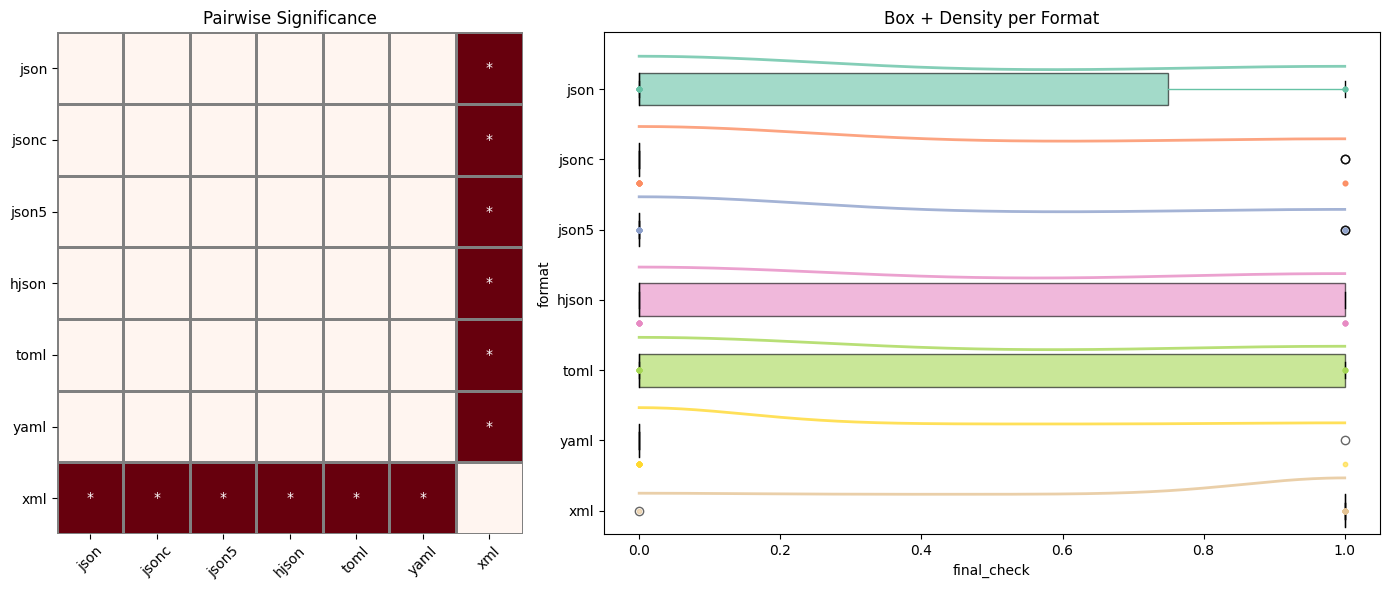

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  0.375000  0.500000     0.0    0    1
 json       18  0.277778  0.460889     0.0    0    1
 json5      16  0.187500  0.403113     0.0    0    1
 jsonc      15  0.200000  0.414039     0.0    0    1
 toml       16  0.312500  0.478714     0.0    0    1
 xml        16  0.937500  0.250000     1.0    0    1
 yaml       15  0.066667  0.258199     0.0    0    1,
 'overall_p': 8.755653182557757e-07,
 'effect_size': 0.3027106053421842,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.9927        False   hjson vs json is not significant
 1   hjson  json5   0.8511        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.8955        False  hjson vs jsonc is not significant
 3   hjson   toml   0.9995 

In [43]:
df_writing_merged = merge_dfs([json_result, jsonc_result, json5_result,hjson_result,toml_result,yaml_result,xml_result])
df_writing_merged['task']= 'writing_task'

vis_box_comparasion(
    df_writing_merged,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    discrete_tasks=['writing_task']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)

final_check_results = compare_statistically(
    df_writing_merged,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task',
    discrete_tasks=['writing_task']
)

final_check_results

### similarity

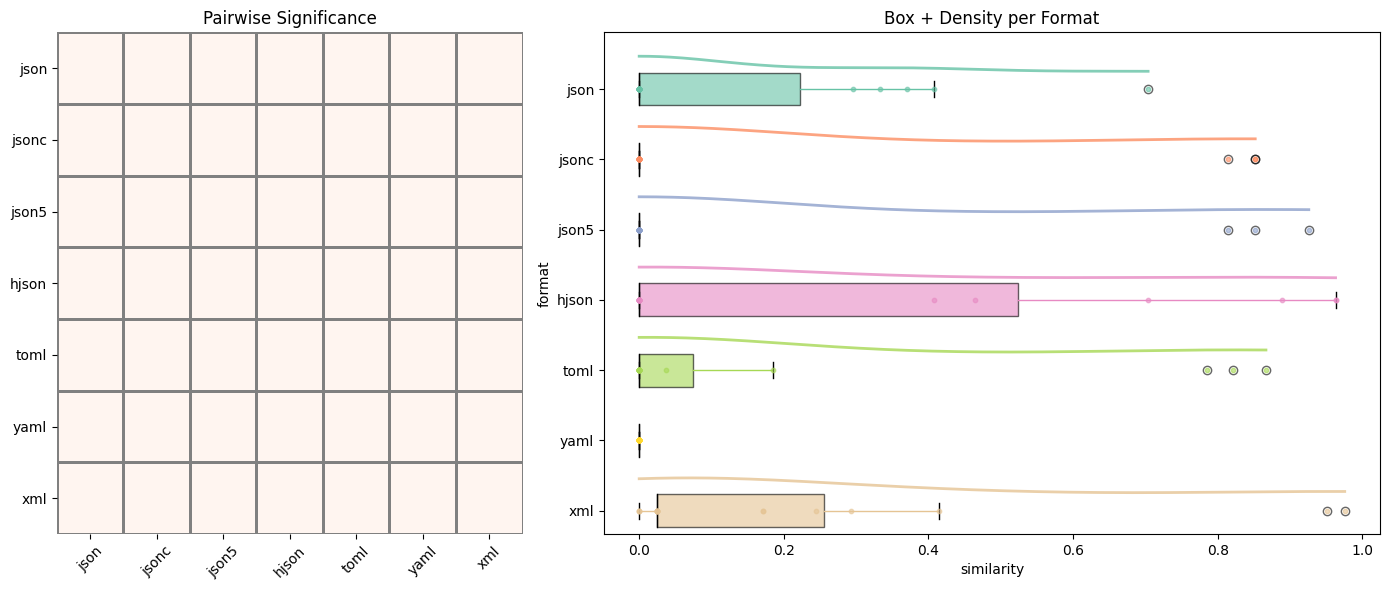

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std   median  min       max
 format                                                   
 hjson      16  0.274388  0.393009  0.00000  0.0  0.962963
 json       18  0.117284  0.209994  0.00000  0.0  0.703704
 json5      16  0.162037  0.348981  0.00000  0.0  0.925926
 jsonc      15  0.167901  0.347683  0.00000  0.0  0.851852
 toml       16  0.168502  0.329098  0.00000  0.0  0.866667
 xml        16  0.210366  0.319115  0.02439  0.0  0.975610
 yaml       15  0.000000  0.000000  0.00000  0.0  0.000000,
 'overall_p': 0.31152741105756443,
 'effect_size': 0.06423170582022748,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [44]:
vis_box_comparasion(
    df_writing_merged,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    continuous_tasks=['writing_task']
)

similarity_results = compare_statistically(
    df_writing_merged,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task',
    continuous_tasks=['writing_task']
)

similarity_results

## modifying task correctness

### data prepare

In [60]:
df_json_1=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-tabular-1']
df_json_2=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-tabular-2']
df_json_3=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-tabular-3']
df_json_4=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-tabular-4']
df_jsonc_1=df_modifying[df_modifying['format']=='jsonc'][df_modifying['task']=='modifying-task-tabular-1']
df_jsonc_2=df_modifying[df_modifying['format']=='jsonc'][df_modifying['task']=='modifying-task-tabular-2']
df_jsonc_3=df_modifying[df_modifying['format']=='jsonc'][df_modifying['task']=='modifying-task-tabular-3']
df_jsonc_4=df_modifying[df_modifying['format']=='jsonc'][df_modifying['task']=='modifying-task-tabular-4']
df_json5_1=df_modifying[df_modifying['format']=='json5'][df_modifying['task']=='modifying-task-tabular-1']
df_json5_2=df_modifying[df_modifying['format']=='json5'][df_modifying['task']=='modifying-task-tabular-2']
df_json5_3=df_modifying[df_modifying['format']=='json5'][df_modifying['task']=='modifying-task-tabular-3']
df_json5_4=df_modifying[df_modifying['format']=='json5'][df_modifying['task']=='modifying-task-tabular-4']
df_hjson_1=df_modifying[df_modifying['format']=='hjson'][df_modifying['task']=='modifying-task-tabular-1']
df_hjson_2=df_modifying[df_modifying['format']=='hjson'][df_modifying['task']=='modifying-task-tabular-2']
df_hjson_3=df_modifying[df_modifying['format']=='hjson'][df_modifying['task']=='modifying-task-tabular-3']
df_hjson_4=df_modifying[df_modifying['format']=='hjson'][df_modifying['task']=='modifying-task-tabular-4']
df_toml_1=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-tabular-1']
df_toml_2=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-tabular-2']
df_toml_3=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-tabular-3']
df_toml_4=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-tabular-4']
df_yaml_1=df_modifying[df_modifying['format']=='yaml'][df_modifying['task']=='modifying-task-tabular-1']
df_yaml_2=df_modifying[df_modifying['format']=='yaml'][df_modifying['task']=='modifying-task-tabular-2']
df_yaml_3=df_modifying[df_modifying['format']=='yaml'][df_modifying['task']=='modifying-task-tabular-3']
df_yaml_4=df_modifying[df_modifying['format']=='yaml'][df_modifying['task']=='modifying-task-tabular-4']
df_toml_1=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-tabular-1']
df_toml_2=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-tabular-2']
df_toml_3=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-tabular-3']
df_toml_4=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-tabular-4']
df_xml_1=df_modifying[df_modifying['format']=='xml'][df_modifying['task']=='modifying-task-tabular-1']
df_xml_2=df_modifying[df_modifying['format']=='xml'][df_modifying['task']=='modifying-task-tabular-2']
df_xml_3=df_modifying[df_modifying['format']=='xml'][df_modifying['task']=='modifying-task-tabular-3']
df_xml_4=df_modifying[df_modifying['format']=='xml'][df_modifying['task']=='modifying-task-tabular-4']

/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_76516/969377691.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_json_1=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-tabular-1']
/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_76516/969377691.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_json_2=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-tabular-2']
/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_76516/969377691.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_json_3=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-tabular-3']
/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_76516/969377691.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_json_4=df_modifying[df_modifying['format']=='j

In [62]:
gold_dict_json_1 = '''
{
  "movies": {
    "movie": [
      {
        "title": "After Dark in Central Park",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-15",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "James H. White",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Boarding School Girls' Pajama Parade",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-05-10",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "James H. White",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Buffalo Bill's Wild West Parade",
        "year": 1900,
        "cast": ["Buffalo Bill (William F. Cody)"],
        "genres": ["Documentary"],
        "href": null,
        "country": "United States",
        "runtime": 5,
        "language": "Silent",
        "release_date": "1900-07-04",
        "production_company": "Edison Manufacturing Company",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 600,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Caught",
        "year": 1900,
        "cast": [],
        "genres": ["Drama"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-02-20",
        "production_company": "Biograph Company",
        "director": "William Heise",
        "writer": "William Heise",
        "cinematography": "Unknown",
        "budget": 400,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Clowns Spinning Hats",
        "year": 1900,
        "cast": ["Unknown Clowns"],
        "genres": ["Silent", "Comedy"],
        "href": "Clowns_Spinning_Hats",
        "extract": "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-04-07",
        "production_company": "Lubin Films",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "The Enchanted Drawing",
        "year": 1900,
        "cast": ["J. Stuart Blackton"],
        "genres": ["Silent", "Animation"],
        "href": "The_Enchanted_Drawing",
        "extract": "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-11-16",
        "production_company": "Vitagraph Studios",
        "director": "J. Stuart Blackton",
        "writer": "J. Stuart Blackton",
        "cinematography": "Unknown",
        "budget": 700,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Feeding Sea Lions",
        "year": 1900,
        "cast": ["Paul Boyton"],
        "genres": ["Short", "Silent"],
        "href": "Feeding_Sea_Lions",
        "extract": "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-10",
        "production_company": "Lubin Studios",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "A Trip to the Moon",
        "year": 1902,
        "cast": ["Georges Méliès"],
        "genres": ["Sci-Fi", "Adventure"],
        "href": "A_Trip_to_the_Moon",
        "extract": "A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "France",
        "runtime": 14,
        "language": "Silent",
        "release_date": "1902-09-01",
        "production_company": "Star Film Company",
        "director": "Georges Méliès",
        "writer": "Georges Méliès",
        "cinematography": "Georges Méliès",
        "budget": 10000,
        "box_office": 20000,
        "awards": ["Considered a milestone in cinema history"]
      },
      {
        "title": "The Great Train Robbery",
        "year": 1903,
        "cast": ["Gilbert M. Anderson", "A. C. Abadie"],
        "genres": ["Western", "Action"],
        "href": "The_Great_Train_Robbery",
        "extract": "The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 12,
        "language": "Silent",
        "release_date": "1903-12-01",
        "production_company": "Edison Manufacturing Company",
        "director": "Edwin S. Porter",
        "writer": "Edwin S. Porter",
        "cinematography": "Edwin S. Porter",
        "budget": 150,
        "box_office": 5000,
        "awards": ["One of the earliest crime films"]
      }
    ]
  }
}
'''
gold_dict_jsonc_1 = '''
{
  "movies": {
    "movie": [
      {
        "title": "After Dark in Central Park",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-15",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "James H. White",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Boarding School Girls' Pajama Parade",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-05-10",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "James H. White",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Buffalo Bill's Wild West Parade",
        "year": 1900,
        "cast": ["Buffalo Bill (William F. Cody)"],
        "genres": ["Documentary"],
        "href": null,
        "country": "United States",
        "runtime": 5,
        "language": "Silent",
        "release_date": "1900-07-04",
        "production_company": "Edison Manufacturing Company",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 600,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Caught",
        "year": 1900,
        "cast": [],
        "genres": ["Drama"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-02-20",
        "production_company": "Biograph Company",
        "director": "William Heise",
        "writer": "William Heise",
        "cinematography": "Unknown",
        "budget": 400,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Clowns Spinning Hats",
        "year": 1900,
        "cast": ["Unknown Clowns"],
        "genres": ["Silent", "Comedy"],
        "href": "Clowns_Spinning_Hats",
        "extract": "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-04-07",
        "production_company": "Lubin Films",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "The Enchanted Drawing",
        "year": 1900,
        "cast": ["J. Stuart Blackton"],
        "genres": ["Silent", "Animation"],
        "href": "The_Enchanted_Drawing",
        "extract": "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-11-16",
        "production_company": "Vitagraph Studios",
        "director": "J. Stuart Blackton",
        "writer": "J. Stuart Blackton",
        "cinematography": "Unknown",
        "budget": 700,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Feeding Sea Lions",
        "year": 1900,
        "cast": ["Paul Boyton"],
        "genres": ["Short", "Silent"],
        "href": "Feeding_Sea_Lions",
        "extract": "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-10",
        "production_company": "Lubin Studios",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "A Trip to the Moon",
        "year": 1902,
        "cast": ["Georges Méliès"],
        "genres": ["Sci-Fi", "Adventure"],
        "href": "A_Trip_to_the_Moon",
        "extract": "A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "France",
        "runtime": 14,
        "language": "Silent",
        "release_date": "1902-09-01",
        "production_company": "Star Film Company",
        "director": "Georges Méliès",
        "writer": "Georges Méliès",
        "cinematography": "Georges Méliès",
        "budget": 10000,
        "box_office": 20000,
        "awards": ["Considered a milestone in cinema history"]
      },
      {
        "title": "The Great Train Robbery",
        "year": 1903,
        "cast": ["Gilbert M. Anderson", "A. C. Abadie"],
        "genres": ["Western", "Action"],
        "href": "The_Great_Train_Robbery",
        "extract": "The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 12,
        "language": "Silent",
        "release_date": "1903-12-01",
        "production_company": "Edison Manufacturing Company",
        "director": "Edwin S. Porter",
        "writer": "Edwin S. Porter",
        "cinematography": "Edwin S. Porter",
        "budget": 150,
        "box_office": 5000,
        "awards": ["One of the earliest crime films"]
      }
    ]
  }
}
'''
gold_dict_json5_1 = '''
{
    movies: {
        movie: [
            {
                title: 'After Dark in Central Park',
                year: 1900,
                cast: [],
                genres: [
                    'Silent',
                    'Short'
                ],
                href: null,
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-03-15',
                production_company: 'Edison Manufacturing Company',
                director: 'James H. White',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 500,
                box_office: null,
                awards: []
            },
            {
                title: "Boarding School Girls' Pajama Parade",
                year: 1900,
                cast: [],
                genres: [
                    'Silent',
                    'Short'
                ],
                href: null,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-05-10',
                production_company: 'Edison Manufacturing Company',
                director: 'James H. White',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 450,
                box_office: null,
                awards: []
            },
            {
                title: "Buffalo Bill's Wild West Parade",
                year: 1900,
                cast: [
                    'Buffalo Bill (William F. Cody)'
                ],
                genres: [
                    'Documentary',
                ],
                href: null,
                country: 'United States',
                runtime: 5,
                language: 'Silent',
                release_date: '1900-07-04',
                production_company: 'Edison Manufacturing Company',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 600,
                box_office: null,
                awards: []
            },
            {
                title: 'Caught',
                year: 1900,
                cast: [],
                genres: [
                    'Drama'
                ],
                href: null,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-02-20',
                production_company: 'Biograph Company',
                director: 'William Heise',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 400,
                box_office: null,
                awards: []
            },
            {
                title: 'Clowns Spinning Hats',
                year: 1900,
                cast: [
                    'Unknown Clowns'
                ],
                genres: [
                    'Silent',
                    'Comedy'
                ],
                href: 'Clowns_Spinning_Hats',
                extract: 'Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.',
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-04-07',
                production_company: 'Lubin Films',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 500,
                box_office: null,
                awards: []
            },
            {
                title: 'The Enchanted Drawing',
                year: 1900,
                cast: [
                    'J. Stuart Blackton'
                ],
                genres: [
                    'Silent',
                    'Animation'
                ],
                href: 'The_Enchanted_Drawing',
                extract: 'The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-11-16',
                production_company: 'Vitagraph Studios',
                director: 'J. Stuart Blackton',
                writer: 'J. Stuart Blackton',
                cinematography: 'Unknown',
                budget: 700,
                box_office: null,
                awards: []
            },
            {
                title: 'Feeding Sea Lions',
                year: 1900,
                cast: [
                    'Paul Boyton'
                ],
                genres: [
                    'Short',
                    'Silent'
                ],
                href: 'Feeding_Sea_Lions',
                extract: 'Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.',
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-03-10',
                production_company: 'Lubin Studios',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 450,
                box_office: null,
                awards: []
            },
            {
                title: 'A Trip to the Moon',
                year: 1902,    // This movie was released after 1900.
                cast: [
                    'Georges Méliès'
                ],
                genres: [
                    'Sci-Fi',
                    'Adventure'
                ],
                href: 'A_Trip_to_the_Moon',
                extract: 'A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'France',
                runtime: 14,
                language: 'Silent',
                release_date: '1902-09-01',
                production_company: 'Star Film Company',
                director: 'Georges Méliès',
                writer: 'Georges Méliès',
                cinematography: 'Georges Méliès',
                budget: 10000,
                box_office: 20000,
                awards: [
                    'Considered a milestone in cinema history'
                ]
            },
            {
                title: 'The Great Train Robbery',
                year: 1903,    // This movie was released after 1900.
                cast: [
                    'Gilbert M. Anderson',
                    'A. C. Abadie'
                ],
                genres: [
                    'Western',
                    'Action'
                ],
                href: 'The_Great_Train_Robbery',
                extract: 'The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'United States',
                runtime: 12,
                language: 'Silent',
                release_date: '1903-12-01',
                production_company: 'Edison Manufacturing Company',
                director: 'Edwin S. Porter',
                writer: 'Scott Marble',
                cinematography: 'Edwin S. Porter',
                budget: 150,
                box_office: 5000,
                awards: [
                    'One of the earliest crime films'
                ]
            }
        ]
    }
}
'''
gold_dict_hjson_1 = '''
{
  movies:
  {
    movie:
    [
      {
        title: After Dark in Central Park
        year: 1900
        cast: []
        genres:
        [
          Silent
          Short
        ]
        href: null
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-03-15
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
      }
      {
        title: Boarding School Girls' Pajama Parade
        year: 1900
        cast: []
        genres:
        [
          Silent
          Short
        ]
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-05-10
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
      }
      {
        title: Buffalo Bill's Wild West Parade
        year: 1900
        cast:
        [
          Buffalo Bill (William F. Cody)
        ]
        genres:
        [
          Documentary
        ]
        href: null
        country: United States
        runtime: 5
        language: Silent
        release_date: 1900-07-04
        production_company: Edison Manufacturing Company
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 600
        box_office: null
        awards: []
      }
      {
        title: Caught
        year: 1900
        cast: []
        genres:
        [
          Drama
        ]
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-02-20
        production_company: Biograph Company
        director: William Heise
        writer: Unknown
        cinematography: Unknown
        budget: 400
        box_office: null
        awards: []
      }
      {
        title: Clowns Spinning Hats
        year: 1900
        cast:
        [
          Unknown Clowns
        ]
        genres:
        [
          Silent
          Comedy
        ]
        href: Clowns_Spinning_Hats
        extract: Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-04-07
        production_company: Lubin Films
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
      }
      {
        title: The Enchanted Drawing
        year: 1900
        cast:
        [
          J. Stuart Blackton
        ]
        genres:
        [
          Silent
          Animation
        ]
        href: The_Enchanted_Drawing
        extract: The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-11-16
        production_company: Vitagraph Studios
        director: J. Stuart Blackton
        writer: J. Stuart Blackton
        cinematography: Unknown
        budget: 700
        box_office: null
        awards: []
      }
      {
        title: Feeding Sea Lions
        year: 1900
        cast:
        [
          Paul Boyton
        ]
        genres:
        [
          Short
          Silent
        ]
        href: Feeding_Sea_Lions
        extract: Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-03-10
        production_company: Lubin Studios
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
      }
      {
        title: A Trip to the Moon
        year: 1902    // This movie was released after 1900.
        cast:
        [
          Georges Méliès
        ]
        genres:
        [
          Sci-Fi
          Adventure
        ]
        href: A_Trip_to_the_Moon
        extract: A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.
        thumbnail_width: 320
        thumbnail_height: 240
        country: France
        runtime: 14
        language: Silent
        release_date: 1902-09-01
        production_company: Star Film Company
        director: Georges Méliès
        writer: Georges Méliès
        cinematography: Georges Méliès
        budget: 10000
        box_office: 20000
        awards:
        [
          Considered a milestone in cinema history
        ]
      }
      {
        title: The Great Train Robbery
        year: 1903  
        cast:
        [
          Gilbert M. Anderson
          A. C. Abadie
        ]
        genres:
        [
          Western
          Action
        ]
        href: The_Great_Train_Robbery
        extract: The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 12
        language: Silent
        release_date: 1903-12-01
        production_company: Edison Manufacturing Company
        director: Edwin S. Porter
        writer: Scott Marble
        cinematography: Edwin S. Porter
        budget: 150
        box_office: 5000
        awards:
        [
          One of the earliest crime films
        ]
      }
    ]
  }
}
'''
gold_dict_yaml_1 = '''
movies:
  movie:
    - title: After Dark in Central Park
      year: 1900
      cast: []
      genres:
        - Silent
        - Short
      href: null
      country: United States
      runtime: 3
      language: Silent
      release_date: "1900-03-15"
      production_company: Edison Manufacturing Company
      director: James H. White
      writer: James H. White
      cinematography: Unknown
      budget: 500
      box_office: null
      awards: []
    - title: Boarding School Girls' Pajama Parade
      year: 1900
      cast: []
      genres:
        - Silent
        - Short
      href: null
      country: United States
      runtime: 2
      language: Silent
      release_date: "1900-05-10"
      production_company: Edison Manufacturing Company
      director: James H. White
      writer: James H. White
      cinematography: Unknown
      budget: 450
      box_office: null
      awards: []
    - title: Buffalo Bill's Wild West Parade
      year: 1900
      cast:
        - Buffalo Bill (William F. Cody)
      genres:
        - Documentary
      href: null
      country: United States
      runtime: 5
      language: Silent
      release_date: "1900-07-04"
      production_company: Edison Manufacturing Company
      director: Unknown
      writer: Unknown
      cinematography: Unknown
      budget: 600
      box_office: null
      awards: []
    - title: Caught
      year: 1900
      cast: []
      genres:
        - Drama
      href: null
      country: United States
      runtime: 2
      language: Silent
      release_date: "1900-02-20"
      production_company: Biograph Company
      director: William Heise
      writer: William Heise
      cinematography: Unknown
      budget: 400
      box_office: null
      awards: []
    - title: Clowns Spinning Hats
      year: 1900
      cast:
        - Unknown Clowns
      genres:
        - Silent
        - Comedy
      href: Clowns_Spinning_Hats
      extract: |
        Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.
      country: United States
      runtime: 3
      language: Silent
      release_date: "1900-04-07"
      production_company: Lubin Films
      director: Unknown
      writer: Unknown
      cinematography: Unknown
      budget: 500
      box_office: null
      awards: []
    - title: The Enchanted Drawing
      year: 1900
      cast:
        - J. Stuart Blackton
      genres:
        - Silent
        - Animation
      href: The_Enchanted_Drawing
      extract: |
        The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.
      thumbnail_width: 320
      thumbnail_height: 240
      country: United States
      runtime: 2
      language: Silent
      release_date: "1900-11-16"
      production_company: Vitagraph Studios
      director: J. Stuart Blackton
      writer: J. Stuart Blackton
      cinematography: Unknown
      budget: 700
      box_office: null
      awards: []
    - title: Feeding Sea Lions
      year: 1900
      cast:
        - Paul Boyton
      genres:
        - Short
        - Silent
      href: Feeding_Sea_Lions
      extract: |
        Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.
      country: United States
      runtime: 3
      language: Silent
      release_date: "1900-03-10"
      production_company: Lubin Studios
      director: Unknown
      writer: Unknown
      cinematography: Unknown
      budget: 450
      box_office: null
      awards: []
    - title: A Trip to the Moon
      year: 1902
      cast:
        - Georges Méliès
      genres:
        - Sci-Fi
        - Adventure
      href: A_Trip_to_the_Moon
      extract: |
        A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.
      thumbnail_width: 320
      thumbnail_height: 240
      country: France
      runtime: 14
      language: Silent
      release_date: "1902-09-01"
      production_company: Star Film Company
      director: Georges Méliès
      writer: Georges Méliès
      cinematography: Georges Méliès
      budget: 10000
      box_office: 20000
      awards:
        - Considered a milestone in cinema history
    - title: The Great Train Robbery
      year: 1903
      cast:
        - Gilbert M. Anderson
        - A. C. Abadie
      genres:
        - Western
        - Action
      href: The_Great_Train_Robbery
      extract: |
        The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.
      thumbnail_width: 320
      thumbnail_height: 240
      country: United States
      runtime: 12
      language: Silent
      release_date: "1903-12-01"
      production_company: Edison Manufacturing Company
      director: Edwin S. Porter
      writer: Edwin S. Porter
      cinematography: Edwin S. Porter
      budget: 150
      box_office: 5000
      awards:
        - One of the earliest crime films

'''
gold_dict_toml_1 = '''
[[movies.movie]]
title = "After Dark in Central Park"
year = 1900
cast = []
genres = ["Silent", "Short"]
href = ""
country = "United States"
runtime = 3
language = "Silent"
release_date = "1900-03-15"
production_company = "Edison Manufacturing Company"
director = "James H. White"
writer = "James H. White"
cinematography = "Unknown"
budget = 500
box_office = ""
awards = []

[[movies.movie]]
title = "Boarding School Girls' Pajama Parade"
year = 1900
cast = []
genres = ["Silent", "Short"]
href = ""
country = "United States"
runtime = 2
language = "Silent"
release_date = "1900-05-10"
production_company = "Edison Manufacturing Company"
director = "James H. White"
writer = "James H. White"
cinematography = "Unknown"
budget = 450
box_office = ""
awards = []

[[movies.movie]]
title = "Buffalo Bill's Wild West Parade"
year = 1900
cast = ["Buffalo Bill (William F. Cody)"]
genres = ["Documentary"]
href = ""
country = "United States"
runtime = 5
language = "Silent"
release_date = "1900-07-04"
production_company = "Edison Manufacturing Company"
director = "Unknown"
writer = "Unknown"
cinematography = "Unknown"
budget = 600
box_office = ""
awards = []

[[movies.movie]]
title = "Caught"
year = 1900
cast = []
genres = ["Drama"]
href = ""
country = "United States"
runtime = 2
language = "Silent"
release_date = "1900-02-20"
production_company = "Biograph Company"
director = "William Heise"
writer = "William Heise"
cinematography = "Unknown"
budget = 400
box_office = ""
awards = []

[[movies.movie]]
title = "Clowns Spinning Hats"
year = 1900
cast = ["Unknown Clowns"]
genres = ["Silent", "Comedy"]
href = "Clowns_Spinning_Hats"
extract = "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900."
country = "United States"
runtime = 3
language = "Silent"
release_date = "1900-04-07"
production_company = "Lubin Films"
director = "Unknown"
writer = "Unknown"
cinematography = "Unknown"
budget = 500
box_office = ""
awards = []

[[movies.movie]]
title = "The Enchanted Drawing"
year = 1900
cast = ["J. Stuart Blackton"]
genres = ["Silent", "Animation"]
href = "The_Enchanted_Drawing"
extract = "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation."
thumbnail_width = 320
thumbnail_height = 240
country = "United States"
runtime = 2
language = "Silent"
release_date = "1900-11-16"
production_company = "Vitagraph Studios"
director = "J. Stuart Blackton"
writer = "J. Stuart Blackton"
cinematography = "Unknown"
budget = 700
box_office = ""
awards = []

[[movies.movie]]
title = "Feeding Sea Lions"
year = 1900
cast = ["Paul Boyton"]
genres = ["Short", "Silent"]
href = "Feeding_Sea_Lions"
extract = "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900."
country = "United States"
runtime = 3
language = "Silent"
release_date = "1900-03-10"
production_company = "Lubin Studios"
director = "Unknown"
writer = "Unknown"
cinematography = "Unknown"
budget = 450
box_office = ""
awards = []

[[movies.movie]]
title = "A Trip to the Moon"
year = 1902
cast = ["Georges Méliès"]
genres = ["Sci-Fi", "Adventure"]
href = "A_Trip_to_the_Moon"
extract = "A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made."
thumbnail_width = 320
thumbnail_height = 240
country = "France"
runtime = 14
language = "Silent"
release_date = "1902-09-01"
production_company = "Star Film Company"
director = "Georges Méliès"
writer = "Georges Méliès"
cinematography = "Georges Méliès"
budget = 10000
box_office = 20000
awards = ["Considered a milestone in cinema history"]

[[movies.movie]]
title = "The Great Train Robbery"
year = 1903
cast = ["Gilbert M. Anderson", "A. C. Abadie"]
genres = ["Western", "Action"]
href = "The_Great_Train_Robbery"
extract = "The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films."
thumbnail_width = 320
thumbnail_height = 240
country = "United States"
runtime = 12
language = "Silent"
release_date = "1903-12-01"
production_company = "Edison Manufacturing Company"
director = "Edwin S. Porter"
writer = "Edwin S. Porter"
cinematography = "Edwin S. Porter"
budget = 150
box_office = 5000
awards = ["One of the earliest crime films"]

'''
gold_dict_xml_1 = '''
<?xml version="1.0" encoding="UTF-8"?>
<movies>
  <movie>
    <title>After Dark in Central Park</title>
    <year>1900</year>
    <cast/>
    <genres>
      <item>Silent</item>
      <item>Short</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>3</runtime>
    <language>Silent</language>
    <release_date>1900-03-15</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>James H. White</director>
    <writer>James H. White</writer>
    <cinematography>Unknown</cinematography>
    <budget>500</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Boarding School Girls' Pajama Parade</title>
    <year>1900</year>
    <cast/>
    <genres>
      <item>Silent</item>
      <item>Short</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>2</runtime>
    <language>Silent</language>
    <release_date>1900-05-10</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>James H. White</director>
    <writer>James H. White</writer>
    <cinematography>Unknown</cinematography>
    <budget>450</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Buffalo Bill's Wild West Parade</title>
    <year>1900</year>
    <cast>
      <item>Buffalo Bill (William F. Cody)</item>
    </cast>
    <genres>
      <item>Documentary</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>5</runtime>
    <language>Silent</language>
    <release_date>1900-07-04</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>Unknown</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>600</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Caught</title>
    <year>1900</year>
    <cast/>
    <genres>
      <item>Drama</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>2</runtime>
    <language>Silent</language>
    <release_date>1900-02-20</release_date>
    <production_company>Biograph Company</production_company>
    <director>William Heise</director>
    <writer>William Heise</writer>
    <cinematography>Unknown</cinematography>
    <budget>400</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Clowns Spinning Hats</title>
    <year>1900</year>
    <cast>
      <item>Unknown Clowns</item>
    </cast>
    <genres>
      <item>Silent</item>
      <item>Comedy</item>
    </genres>
    <href>Clowns_Spinning_Hats</href>
    <extract>Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.</extract>
    <country>United States</country>
    <runtime>3</runtime>
    <language>Silent</language>
    <release_date>1900-04-07</release_date>
    <production_company>Lubin Films</production_company>
    <director>Unknown</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>500</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>The Enchanted Drawing</title>
    <year>1900</year>
    <cast>
      <item>J. Stuart Blackton</item>
    </cast>
    <genres>
      <item>Silent</item>
      <item>Animation</item>
    </genres>
    <href>The_Enchanted_Drawing</href>
    <extract>The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.</extract>
    <thumbnail_width>320</thumbnail_width>
    <thumbnail_height>240</thumbnail_height>
    <country>United States</country>
    <runtime>2</runtime>
    <language>Silent</language>
    <release_date>1900-11-16</release_date>
    <production_company>Vitagraph Studios</production_company>
    <director>J. Stuart Blackton</director>
    <writer>J. Stuart Blackton</writer>
    <cinematography>Unknown</cinematography>
    <budget>700</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Feeding Sea Lions</title>
    <year>1900</year>
    <cast>
      <item>Paul Boyton</item>
    </cast>
    <genres>
      <item>Short</item>
      <item>Silent</item>
    </genres>
    <href>Feeding_Sea_Lions</href>
    <extract>Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.</extract>
    <country>United States</country>
    <runtime>3</runtime>
    <language>Silent</language>
    <release_date>1900-03-10</release_date>
    <production_company>Lubin Studios</production_company>
    <director>Unknown</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>450</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>A Trip to the Moon</title>
    <year>1902</year>
    <cast>
      <item>Georges Méliès</item>
    </cast>
    <genres>
      <item>Sci-Fi</item>
      <item>Adventure</item>
    </genres>
    <href>A_Trip_to_the_Moon</href>
    <extract>A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.</extract>
    <thumbnail_width>320</thumbnail_width>
    <thumbnail_height>240</thumbnail_height>
    <country>France</country>
    <runtime>14</runtime>
    <language>Silent</language>
    <release_date>1902-09-01</release_date>
    <production_company>Star Film Company</production_company>
    <director>Georges Méliès</director>
    <writer>Georges Méliès</writer>
    <cinematography>Georges Méliès</cinematography>
    <budget>10000</budget>
    <box_office>20000</box_office>
    <awards>
      <item>Considered a milestone in cinema history</item>
    </awards>
  </movie>
  <movie>
    <title>The Great Train Robbery</title>
    <year>1903</year>
    <cast>
      <item>Gilbert M. Anderson</item>
      <item>A. C. Abadie</item>
    </cast>
    <genres>
      <item>Western</item>
      <item>Action</item>
    </genres>
    <href>The_Great_Train_Robbery</href>
    <extract>The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.</extract>
    <thumbnail_width>320</thumbnail_width>
    <thumbnail_height>240</thumbnail_height>
    <country>United States</country>
    <runtime>12</runtime>
    <language>Silent</language>
    <release_date>1903-12-01</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>Edwin S. Porter</director>
    <writer>Edwin S. Porter</writer>
    <cinematography>Edwin S. Porter</cinematography>
    <budget>150</budget>
    <box_office>5000</box_office>
    <awards>
      <item>One of the earliest crime films</item>
    </awards>
  </movie>
</movies>

'''



In [64]:
gold_dict_json_2 = '''
{
  "movies": {
    "movie": [
      {
        "title": "After Dark in Central Park",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-15",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Boarding School Girls' Pajama Parade",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-05-10",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Buffalo Bill's Wild West Parade",
        "year": 1900,
        "cast": ["Buffalo Bill (William F. Cody)"],
        "genres": ["Documentary", "Silent"],
        "href": null,
        "country": "United States",
        "runtime": 5,
        "language": "Silent",
        "release_date": "1900-07-04",
        "production_company": "Edison Manufacturing Company",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 600,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Caught",
        "year": 1900,
        "cast": [],
        "genres": ["Drama", "Silent"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-02-20",
        "production_company": "Biograph Company",
        "director": "William Heise",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 400,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Clowns Spinning Hats",
        "year": 1900,
        "cast": ["Unknown Clowns"],
        "genres": ["Silent", "Comedy"],
        "href": "Clowns_Spinning_Hats",
        "extract": "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-04-07",
        "production_company": "Lubin Films",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "The Enchanted Drawing",
        "year": 1900,
        "cast": ["J. Stuart Blackton"],
        "genres": ["Silent", "Animation"],
        "href": "The_Enchanted_Drawing",
        "extract": "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-11-16",
        "production_company": "Vitagraph Studios",
        "director": "J. Stuart Blackton",
        "writer": "J. Stuart Blackton",
        "cinematography": "Unknown",
        "budget": 700,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Feeding Sea Lions",
        "year": 1900,
        "cast": ["Paul Boyton"],
        "genres": ["Short", "Silent"],
        "href": "Feeding_Sea_Lions",
        "extract": "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-10",
        "production_company": "Lubin Studios",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "A Trip to the Moon",
        "year": 1902,
        "cast": ["Georges Méliès"],
        "genres": ["Sci-Fi", "Adventure", "Silent"],
        "href": "A_Trip_to_the_Moon",
        "extract": "A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "France",
        "runtime": 14,
        "language": "Silent",
        "release_date": "1902-09-01",
        "production_company": "Star Film Company",
        "director": "Georges Méliès",
        "writer": "Georges Méliès",
        "cinematography": "Georges Méliès",
        "budget": 10000,
        "box_office": 20000,
        "awards": ["Considered a milestone in cinema history"]
      },
      {
        "title": "The Great Train Robbery",
        "year": 1903,
        "cast": ["Gilbert M. Anderson", "A. C. Abadie"],
        "genres": ["Western", "Action", "Silent"],
        "href": "The_Great_Train_Robbery",
        "extract": "The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 12,
        "language": "Silent",
        "release_date": "1903-12-01",
        "production_company": "Edison Manufacturing Company",
        "director": "Edwin S. Porter",
        "writer": "Scott Marble",
        "cinematography": "Edwin S. Porter",
        "budget": 150,
        "box_office": 5000,
        "awards": ["One of the earliest crime films"]
      }
    ]
  }
}
'''
gold_dict_jsonc_2 = '''
{
  "movies": {
    "movie": [
      {
        "title": "After Dark in Central Park",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-15",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Boarding School Girls' Pajama Parade",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-05-10",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Buffalo Bill's Wild West Parade",
        "year": 1900,
        "cast": ["Buffalo Bill (William F. Cody)"],
        "genres": ["Documentary", "Silent"],
        "href": null,
        "country": "United States",
        "runtime": 5,
        "language": "Silent",
        "release_date": "1900-07-04",
        "production_company": "Edison Manufacturing Company",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 600,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Caught",
        "year": 1900,
        "cast": [],
        "genres": ["Drama", "Silent"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-02-20",
        "production_company": "Biograph Company",
        "director": "William Heise",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 400,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Clowns Spinning Hats",
        "year": 1900,
        "cast": ["Unknown Clowns"],
        "genres": ["Silent", "Comedy"],
        "href": "Clowns_Spinning_Hats",
        "extract": "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-04-07",
        "production_company": "Lubin Films",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "The Enchanted Drawing",
        "year": 1900,
        "cast": ["J. Stuart Blackton"],
        "genres": ["Silent", "Animation"],
        "href": "The_Enchanted_Drawing",
        "extract": "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-11-16",
        "production_company": "Vitagraph Studios",
        "director": "J. Stuart Blackton",
        "writer": "J. Stuart Blackton",
        "cinematography": "Unknown",
        "budget": 700,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Feeding Sea Lions",
        "year": 1900,
        "cast": ["Paul Boyton"],
        "genres": ["Short", "Silent"],
        "href": "Feeding_Sea_Lions",
        "extract": "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-10",
        "production_company": "Lubin Studios",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "A Trip to the Moon",
        "year": 1902,
        "cast": ["Georges Méliès"],
        "genres": ["Sci-Fi", "Adventure", "Silent"],
        "href": "A_Trip_to_the_Moon",
        "extract": "A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "France",
        "runtime": 14,
        "language": "Silent",
        "release_date": "1902-09-01",
        "production_company": "Star Film Company",
        "director": "Georges Méliès",
        "writer": "Georges Méliès",
        "cinematography": "Georges Méliès",
        "budget": 10000,
        "box_office": 20000,
        "awards": ["Considered a milestone in cinema history"]
      },
      {
        "title": "The Great Train Robbery",
        "year": 1903,
        "cast": ["Gilbert M. Anderson", "A. C. Abadie"],
        "genres": ["Western", "Action", "Silent"],
        "href": "The_Great_Train_Robbery",
        "extract": "The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 12,
        "language": "Silent",
        "release_date": "1903-12-01",
        "production_company": "Edison Manufacturing Company",
        "director": "Edwin S. Porter",
        "writer": "Scott Marble",
        "cinematography": "Edwin S. Porter",
        "budget": 150,
        "box_office": 5000,
        "awards": ["One of the earliest crime films"]
      }
    ]
  }
}
'''
gold_dict_json5_2 = '''
{
    movies: {
        movie: [
            {
                title: 'After Dark in Central Park',
                year: 1900,
                cast: [],
                genres: [
                    'Silent',
                    'Short'
                ],
                href: null,
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-03-15',
                production_company: 'Edison Manufacturing Company',
                director: 'James H. White',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 500,
                box_office: null,
                awards: []
            },
            {
                title: "Boarding School Girls' Pajama Parade",
                year: 1900,
                cast: [],
                genres: [
                    'Silent',
                    'Short'
                ],
                href: null,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-05-10',
                production_company: 'Edison Manufacturing Company',
                director: 'James H. White',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 450,
                box_office: null,
                awards: []
            },
            {
                title: "Buffalo Bill's Wild West Parade",
                year: 1900,
                cast: [
                    'Buffalo Bill (William F. Cody)'
                ],
                genres: [
                    'Documentary',
                ],
                href: null,
                country: 'United States',
                runtime: 5,
                language: 'Silent',
                release_date: '1900-07-04',
                production_company: 'Edison Manufacturing Company',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 600,
                box_office: null,
                awards: []
            },
            {
                title: 'Caught',
                year: 1900,
                cast: [],
                genres: [
                    'Drama'
                ],
                href: null,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-02-20',
                production_company: 'Biograph Company',
                director: 'William Heise',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 400,
                box_office: null,
                awards: []
            },
            {
                title: 'Clowns Spinning Hats',
                year: 1900,
                cast: [
                    'Unknown Clowns'
                ],
                genres: [
                    'Silent',
                    'Comedy'
                ],
                href: 'Clowns_Spinning_Hats',
                extract: 'Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.',
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-04-07',
                production_company: 'Lubin Films',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 500,
                box_office: null,
                awards: []
            },
            {
                title: 'The Enchanted Drawing',
                year: 1900,
                cast: [
                    'J. Stuart Blackton'
                ],
                genres: [
                    'Silent',
                    'Animation'
                ],
                href: 'The_Enchanted_Drawing',
                extract: 'The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-11-16',
                production_company: 'Vitagraph Studios',
                director: 'J. Stuart Blackton',
                writer: 'J. Stuart Blackton',
                cinematography: 'Unknown',
                budget: 700,
                box_office: null,
                awards: []
            },
            {
                title: 'Feeding Sea Lions',
                year: 1900,
                cast: [
                    'Paul Boyton'
                ],
                genres: [
                    'Short',
                    'Silent'
                ],
                href: 'Feeding_Sea_Lions',
                extract: 'Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.',
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-03-10',
                production_company: 'Lubin Studios',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 450,
                box_office: null,
                awards: []
            },
            {
                title: 'A Trip to the Moon',
                year: 1902,    // This movie was released after 1900.
                cast: [
                    'Georges Méliès'
                ],
                genres: [
                    'Sci-Fi',
                    'Adventure'
                ],
                href: 'A_Trip_to_the_Moon',
                extract: 'A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'France',
                runtime: 14,
                language: 'Silent',
                release_date: '1902-09-01',
                production_company: 'Star Film Company',
                director: 'Georges Méliès',
                writer: 'Georges Méliès',
                cinematography: 'Georges Méliès',
                budget: 10000,
                box_office: 20000,
                awards: [
                    'Considered a milestone in cinema history'
                ]
            },
            {
                title: 'The Great Train Robbery',
                year: 1903,    // This movie was released after 1900.
                cast: [
                    'Gilbert M. Anderson',
                    'A. C. Abadie'
                ],
                genres: [
                    'Western',
                    'Action'
                ],
                href: 'The_Great_Train_Robbery',
                extract: 'The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'United States',
                runtime: 12,
                language: 'Silent',
                release_date: '1903-12-01',
                production_company: 'Edison Manufacturing Company',
                director: 'Edwin S. Porter',
                writer: 'Scott Marble',
                cinematography: 'Edwin S. Porter',
                budget: 150,
                box_office: 5000,
                awards: [
                    'One of the earliest crime films'
                ]
            }
        ]
    }
}
'''
gold_dict_hjson_2 = '''
{
  movies:
  {
    movie:
    [
      {
        title: After Dark in Central Park
        year: 1900
        cast: []
        genres:
        [
          Silent
          Short
        ]
        href: null
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-03-15
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
      }
      {
        title: Boarding School Girls' Pajama Parade
        year: 1900
        cast: []
        genres:
        [
          Silent
          Short
        ]
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-05-10
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
      }
      {
        title: Buffalo Bill's Wild West Parade
        year: 1900
        cast:
        [
          Buffalo Bill (William F. Cody)
        ]
        genres:
        [
          Documentary
        ]
        href: null
        country: United States
        runtime: 5
        language: Silent
        release_date: 1900-07-04
        production_company: Edison Manufacturing Company
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 600
        box_office: null
        awards: []
      }
      {
        title: Caught
        year: 1900
        cast: []
        genres:
        [
          Drama
        ]
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-02-20
        production_company: Biograph Company
        director: William Heise
        writer: Unknown
        cinematography: Unknown
        budget: 400
        box_office: null
        awards: []
      }
      {
        title: Clowns Spinning Hats
        year: 1900
        cast:
        [
          Unknown Clowns
        ]
        genres:
        [
          Silent
          Comedy
        ]
        href: Clowns_Spinning_Hats
        extract: Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-04-07
        production_company: Lubin Films
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
      }
      {
        title: The Enchanted Drawing
        year: 1900
        cast:
        [
          J. Stuart Blackton
        ]
        genres:
        [
          Silent
          Animation
        ]
        href: The_Enchanted_Drawing
        extract: The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-11-16
        production_company: Vitagraph Studios
        director: J. Stuart Blackton
        writer: J. Stuart Blackton
        cinematography: Unknown
        budget: 700
        box_office: null
        awards: []
      }
      {
        title: Feeding Sea Lions
        year: 1900
        cast:
        [
          Paul Boyton
        ]
        genres:
        [
          Short
          Silent
        ]
        href: Feeding_Sea_Lions
        extract: Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-03-10
        production_company: Lubin Studios
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
      }
      {
        title: A Trip to the Moon
        year: 1902    // This movie was released after 1900.
        cast:
        [
          Georges Méliès
        ]
        genres:
        [
          Sci-Fi
          Adventure
        ]
        href: A_Trip_to_the_Moon
        extract: A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.
        thumbnail_width: 320
        thumbnail_height: 240
        country: France
        runtime: 14
        language: Silent
        release_date: 1902-09-01
        production_company: Star Film Company
        director: Georges Méliès
        writer: Georges Méliès
        cinematography: Georges Méliès
        budget: 10000
        box_office: 20000
        awards:
        [
          Considered a milestone in cinema history
        ]
      }
      {
        title: The Great Train Robbery
        year: 1903  
        cast:
        [
          Gilbert M. Anderson
          A. C. Abadie
        ]
        genres:
        [
          Western
          Action
        ]
        href: The_Great_Train_Robbery
        extract: The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 12
        language: Silent
        release_date: 1903-12-01
        production_company: Edison Manufacturing Company
        director: Edwin S. Porter
        writer: Scott Marble
        cinematography: Edwin S. Porter
        budget: 150
        box_office: 5000
        awards:
        [
          One of the earliest crime films
        ]
      }
    ]
  }
}
'''
gold_dict_yaml_2 = '''
movies:
  movie:
    - title: After Dark in Central Park
      year: 1900
      cast: []
      genres:
        - Silent
        - Short
      href: null
      country: United States
      runtime: 3
      language: Silent
      release_date: "1900-03-15"
      production_company: Edison Manufacturing Company
      director: James H. White
      writer: Unknown
      cinematography: Unknown
      budget: 500
      box_office: null
      awards: []
    - title: Boarding School Girls' Pajama Parade
      year: 1900
      cast: []
      genres:
        - Silent
        - Short
      href: null
      country: United States
      runtime: 2
      language: Silent
      release_date: "1900-05-10"
      production_company: Edison Manufacturing Company
      director: James H. White
      writer: Unknown
      cinematography: Unknown
      budget: 450
      box_office: null
      awards: []
    - title: Buffalo Bill's Wild West Parade
      year: 1900
      cast:
        - Buffalo Bill (William F. Cody)
      genres:
        - Documentary
        - Silent
      href: null
      country: United States
      runtime: 5
      language: Silent
      release_date: "1900-07-04"
      production_company: Edison Manufacturing Company
      director: Unknown
      writer: Unknown
      cinematography: Unknown
      budget: 600
      box_office: null
      awards: []
    - title: Caught
      year: 1900
      cast: []
      genres:
        - Drama
        - Silent
      href: null
      country: United States
      runtime: 2
      language: Silent
      release_date: "1900-02-20"
      production_company: Biograph Company
      director: William Heise
      writer: Unknown
      cinematography: Unknown
      budget: 400
      box_office: null
      awards: []
    - title: Clowns Spinning Hats
      year: 1900
      cast:
        - Unknown Clowns
      genres:
        - Silent
        - Comedy
      href: Clowns_Spinning_Hats
      extract: |
        Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.
      country: United States
      runtime: 3
      language: Silent
      release_date: "1900-04-07"
      production_company: Lubin Films
      director: Unknown
      writer: Unknown
      cinematography: Unknown
      budget: 500
      box_office: null
      awards: []
    - title: The Enchanted Drawing
      year: 1900
      cast:
        - J. Stuart Blackton
      genres:
        - Silent
        - Animation
      href: The_Enchanted_Drawing
      extract: |
        The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.
      thumbnail_width: 320
      thumbnail_height: 240
      country: United States
      runtime: 2
      language: Silent
      release_date: "1900-11-16"
      production_company: Vitagraph Studios
      director: J. Stuart Blackton
      writer: J. Stuart Blackton
      cinematography: Unknown
      budget: 700
      box_office: null
      awards: []
    - title: Feeding Sea Lions
      year: 1900
      cast:
        - Paul Boyton
      genres:
        - Short
        - Silent
      href: Feeding_Sea_Lions
      extract: |
        Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.
      country: United States
      runtime: 3
      language: Silent
      release_date: "1900-03-10"
      production_company: Lubin Studios
      director: Unknown
      writer: Unknown
      cinematography: Unknown
      budget: 450
      box_office: null
      awards: []
    - title: A Trip to the Moon
      year: 1902
      cast:
        - Georges Méliès
      genres:
        - Sci-Fi
        - Adventure
        - Silent
      href: A_Trip_to_the_Moon
      extract: |
        A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.
      thumbnail_width: 320
      thumbnail_height: 240
      country: France
      runtime: 14
      language: Silent
      release_date: "1902-09-01"
      production_company: Star Film Company
      director: Georges Méliès
      writer: Georges Méliès
      cinematography: Georges Méliès
      budget: 10000
      box_office: 20000
      awards:
        - Considered a milestone in cinema history
    - title: The Great Train Robbery
      year: 1903
      cast:
        - Gilbert M. Anderson
        - A. C. Abadie
      genres:
        - Western
        - Action
        - Silent
      href: The_Great_Train_Robbery
      extract: |
        The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.
      thumbnail_width: 320
      thumbnail_height: 240
      country: United States
      runtime: 12
      language: Silent
      release_date: "1903-12-01"
      production_company: Edison Manufacturing Company
      director: Edwin S. Porter
      writer: Edwin S. Porter
      cinematography: Edwin S. Porter
      budget: 150
      box_office: 5000
      awards:
        - One of the earliest crime films
'''
gold_dict_toml_2 = '''
[[movies.movie]]
title = "After Dark in Central Park"
year = 1900
cast = []
genres = ["Silent", "Short"]
href = ""
country = "United States"
runtime = 3
language = "Silent"
release_date = "1900-03-15"
production_company = "Edison Manufacturing Company"
director = "James H. White"
writer = "Unknown"
cinematography = "Unknown"
budget = 500
box_office = ""
awards = []

[[movies.movie]]
title = "Boarding School Girls' Pajama Parade"
year = 1900
cast = []
genres = ["Silent", "Short"]
href = ""
country = "United States"
runtime = 2
language = "Silent"
release_date = "1900-05-10"
production_company = "Edison Manufacturing Company"
director = "James H. White"
writer = "Unknown"
cinematography = "Unknown"
budget = 450
box_office = ""
awards = []

[[movies.movie]]
title = "Buffalo Bill's Wild West Parade"
year = 1900
cast = ["Buffalo Bill (William F. Cody)"]
genres = ["Documentary", "Silent"]
href = ""
country = "United States"
runtime = 5
language = "Silent"
release_date = "1900-07-04"
production_company = "Edison Manufacturing Company"
director = "Unknown"
writer = "Unknown"
cinematography = "Unknown"
budget = 600
box_office = ""
awards = []

[[movies.movie]]
title = "Caught"
year = 1900
cast = []
genres = ["Drama", "Silent"]
href = ""
country = "United States"
runtime = 2
language = "Silent"
release_date = "1900-02-20"
production_company = "Biograph Company"
director = "William Heise"
writer = "Unknown"
cinematography = "Unknown"
budget = 400
box_office = ""
awards = []

[[movies.movie]]
title = "Clowns Spinning Hats"
year = 1900
cast = ["Unknown Clowns"]
genres = ["Silent", "Comedy"]
href = "Clowns_Spinning_Hats"
extract = "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900."
country = "United States"
runtime = 3
language = "Silent"
release_date = "1900-04-07"
production_company = "Lubin Films"
director = "Unknown"
writer = "Unknown"
cinematography = "Unknown"
budget = 500
box_office = ""
awards = []

[[movies.movie]]
title = "The Enchanted Drawing"
year = 1900
cast = ["J. Stuart Blackton"]
genres = ["Silent", "Animation"]
href = "The_Enchanted_Drawing"
extract = "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation."
thumbnail_width = 320
thumbnail_height = 240
country = "United States"
runtime = 2
language = "Silent"
release_date = "1900-11-16"
production_company = "Vitagraph Studios"
director = "J. Stuart Blackton"
writer = "J. Stuart Blackton"
cinematography = "Unknown"
budget = 700
box_office = ""
awards = []

[[movies.movie]]
title = "Feeding Sea Lions"
year = 1900
cast = ["Paul Boyton"]
genres = ["Short", "Silent"]
href = "Feeding_Sea_Lions"
extract = "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island…"
country = "United States"
runtime = 3
language = "Silent"
release_date = "1900-03-10"
production_company = "Lubin Studios"
director = "Unknown"
writer = "Unknown"
cinematography = "Unknown"
budget = 450
box_office = ""
awards = []

[[movies.movie]]
title = "A Trip to the Moon"
year = 1902
cast = ["Georges Méliès"]
genres = ["Sci-Fi", "Adventure", "Silent"]
href = "A_Trip_to_the_Moon"
extract = "A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès…"
thumbnail_width = 320
thumbnail_height = 240
country = "France"
runtime = 14
language = "Silent"
release_date = "1900-09-01"
production_company = "Star Film Company"
director = "Georges Méliès"
writer = "Georges Méliès"
cinematography = "Georges Méliès"
budget = 10000
box_office = 20000
awards = ["Considered a milestone in cinema history"]

[[movies.movie]]
title = "The Great Train Robbery"
year = 1903
cast = ["Gilbert M. Anderson", "A. C. Abadie"]
genres = ["Western", "Action", "Silent"]
href = "The_Great_Train_Robbery"
extract = "The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter…"
thumbnail_width = 320
thumbnail_height = 240
country = "United States"
runtime = 12
language = "Silent"
release_date = "1903-12-01"
production_company = "Edison Manufacturing Company"
director = "Edwin S. Porter"
writer = "Edwin S. Porter"
cinematography = "Edwin S. Porter"
budget = 150
box_office = 5000
awards = ["One of the earliest crime films"]
'''
gold_dict_xml_2 = '''
<?xml version="1.0" encoding="UTF-8"?>
<movies>
  <movie>
    <title>After Dark in Central Park</title>
    <year>1900</year>
    <cast/>
    <genres>
      <item>Silent</item>
      <item>Short</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>3</runtime>
    <language>Silent</language>
    <release_date>1900-03-15</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>James H. White</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>500</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Boarding School Girls' Pajama Parade</title>
    <year>1900</year>
    <cast/>
    <genres>
      <item>Silent</item>
      <item>Short</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>2</runtime>
    <language>Silent</language>
    <release_date>1900-05-10</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>James H. White</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>450</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Buffalo Bill's Wild West Parade</title>
    <year>1900</year>
    <cast>
      <item>Buffalo Bill (William F. Cody)</item>
    </cast>
    <genres>
      <item>Documentary</item>
      <item>Silent</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>5</runtime>
    <language>Silent</language>
    <release_date>1900-07-04</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>Unknown</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>600</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Caught</title>
    <year>1900</year>
    <cast/>
    <genres>
      <item>Drama</item>
      <item>Silent</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>2</runtime>
    <language>Silent</language>
    <release_date>1900-02-20</release_date>
    <production_company>Biograph Company</production_company>
    <director>William Heise</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>400</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Clowns Spinning Hats</title>
    <year>1900</year>
    <cast>
      <item>Unknown Clowns</item>
    </cast>
    <genres>
      <item>Silent</item>
      <item>Comedy</item>
    </genres>
    <href>Clowns_Spinning_Hats</href>
    <extract>Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.</extract>
    <country>United States</country>
    <runtime>3</runtime>
    <language>Silent</language>
    <release_date>1900-04-07</release_date>
    <production_company>Lubin Films</production_company>
    <director>Unknown</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>500</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>The Enchanted Drawing</title>
    <year>1900</year>
    <cast>
      <item>J. Stuart Blackton</item>
    </cast>
    <genres>
      <item>Silent</item>
      <item>Animation</item>
    </genres>
    <href>The_Enchanted_Drawing</href>
    <extract>The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.</extract>
    <thumbnail_width>320</thumbnail_width>
    <thumbnail_height>240</thumbnail_height>
    <country>United States</country>
    <runtime>2</runtime>
    <language>Silent</language>
    <release_date>1900-11-16</release_date>
    <production_company>Vitagraph Studios</production_company>
    <director>J. Stuart Blackton</director>
    <writer>J. Stuart Blackton</writer>
    <cinematography>Unknown</cinematography>
    <budget>700</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Feeding Sea Lions</title>
    <year>1900</year>
    <cast>
      <item>Paul Boyton</item>
    </cast>
    <genres>
      <item>Short</item>
      <item>Silent</item>
    </genres>
    <href>Feeding_Sea_Lions</href>
    <extract>Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.</extract>
    <country>United States</country>
    <runtime>3</runtime>
    <language>Silent</language>
    <release_date>1900-03-10</release_date>
    <production_company>Lubin Studios</production_company>
    <director>Unknown</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>450</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>A Trip to the Moon</title>
    <year>1902</year>
    <cast>
      <item>Georges Méliès</item>
    </cast>
    <genres>
      <item>Sci-Fi</item>
      <item>Adventure</item>
      <item>Silent</item>
    </genres>
    <href>A_Trip_to_the_Moon</href>
    <extract>A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.</extract>
    <thumbnail_width>320</thumbnail_width>
    <thumbnail_height>240</thumbnail_height>
    <country>France</country>
    <runtime>14</runtime>
    <language>Silent</language>
    <release_date>1902-09-01</release_date>
    <production_company>Star Film Company</production_company>
    <director>Georges Méliès</director>
    <writer>Georges Méliès</writer>
    <cinematography>Georges Méliès</cinematography>
    <budget>10000</budget>
    <box_office>20000</box_office>
    <awards>
      <item>Considered a milestone in cinema history</item>
    </awards>
  </movie>
  <movie>
    <title>The Great Train Robbery</title>
    <year>1903</year>
    <cast>
      <item>Gilbert M. Anderson</item>
      <item>A. C. Abadie</item>
    </cast>
    <genres>
      <item>Western</item>
      <item>Action</item>
      <item>Silent</item>
    </genres>
    <href>The_Great_Train_Robbery</href>
    <extract>The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.</extract>
    <thumbnail_width>320</thumbnail_width>
    <thumbnail_height>240</thumbnail_height>
    <country>United States</country>
    <runtime>12</runtime>
    <language>Silent</language>
    <release_date>1903-12-01</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>Edwin S. Porter</director>
    <writer>Edwin S. Porter</writer>
    <cinematography>Edwin S. Porter</cinematography>
    <budget>150</budget>
    <box_office>5000</box_office>
    <awards>
      <item>One of the earliest crime films</item>
    </awards>
  </movie>
</movies>
'''





In [65]:
gold_dict_json_3 = '''
{
  "movies": {
    "movie": [
      {
        "title": "After Dark in Central Park",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-15",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Boarding School Girls' Pajama Parade",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-05-10",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Buffalo Bill's Wild West Parade",
        "year": 1900,
        "cast": ["Buffalo Bill (William F. Cody)"],
        "genres": ["Documentary"],
        "href": null,
        "country": "United States",
        "runtime": 5,
        "language": "Silent",
        "release_date": "1900-07-04",
        "production_company": "Edison Manufacturing Company",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 600,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Caught",
        "year": 1900,
        "cast": [],
        "genres": ["Drama"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-02-20",
        "production_company": "Biograph Company",
        "director": "William Heise",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 400,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Clowns Spinning Hats",
        "year": 1900,
        "cast": ["Unknown Clowns"],
        "genres": ["Silent", "Comedy"],
        "href": "Clowns_Spinning_Hats",
        "extract": "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-04-07",
        "production_company": "Lubin Films",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "The Enchanted Drawing",
        "year": 1900,
        "cast": ["J. Stuart Blackton"],
        "genres": ["Silent", "Animation"],
        "href": "The_Enchanted_Drawing",
        "extract": "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-11-16",
        "production_company": "Vitagraph Studios",
        "director": "J. Stuart Blackton",
        "writer": "J. Stuart Blackton",
        "cinematography": "Unknown",
        "budget": 700,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Feeding Sea Lions",
        "year": 1900,
        "cast": ["Paul Boyton"],
        "genres": ["Short", "Silent"],
        "href": "Feeding_Sea_Lions",
        "extract": "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-10",
        "production_company": "Lubin Studios",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      }
    ]
  }
}
'''
gold_dict_jsonc_3 = '''
{
  "movies": {
    "movie": [
      {
        "title": "After Dark in Central Park",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-15",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Boarding School Girls' Pajama Parade",
        "year": 1900,
        "cast": [],
        "genres": ["Silent", "Short"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-05-10",
        "production_company": "Edison Manufacturing Company",
        "director": "James H. White",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Buffalo Bill's Wild West Parade",
        "year": 1900,
        "cast": ["Buffalo Bill (William F. Cody)"],
        "genres": ["Documentary"],
        "href": null,
        "country": "United States",
        "runtime": 5,
        "language": "Silent",
        "release_date": "1900-07-04",
        "production_company": "Edison Manufacturing Company",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 600,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Caught",
        "year": 1900,
        "cast": [],
        "genres": ["Drama"],
        "href": null,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-02-20",
        "production_company": "Biograph Company",
        "director": "William Heise",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 400,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Clowns Spinning Hats",
        "year": 1900,
        "cast": ["Unknown Clowns"],
        "genres": ["Silent", "Comedy"],
        "href": "Clowns_Spinning_Hats",
        "extract": "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-04-07",
        "production_company": "Lubin Films",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 500,
        "box_office": null,
        "awards": []
      },
      {
        "title": "The Enchanted Drawing",
        "year": 1900,
        "cast": ["J. Stuart Blackton"],
        "genres": ["Silent", "Animation"],
        "href": "The_Enchanted_Drawing",
        "extract": "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.",
        "thumbnail_width": 320,
        "thumbnail_height": 240,
        "country": "United States",
        "runtime": 2,
        "language": "Silent",
        "release_date": "1900-11-16",
        "production_company": "Vitagraph Studios",
        "director": "J. Stuart Blackton",
        "writer": "J. Stuart Blackton",
        "cinematography": "Unknown",
        "budget": 700,
        "box_office": null,
        "awards": []
      },
      {
        "title": "Feeding Sea Lions",
        "year": 1900,
        "cast": ["Paul Boyton"],
        "genres": ["Short", "Silent"],
        "href": "Feeding_Sea_Lions",
        "extract": "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.",
        "country": "United States",
        "runtime": 3,
        "language": "Silent",
        "release_date": "1900-03-10",
        "production_company": "Lubin Studios",
        "director": "Unknown",
        "writer": "Unknown",
        "cinematography": "Unknown",
        "budget": 450,
        "box_office": null,
        "awards": []
      }
    ]
  }
}

'''
gold_dict_json5_3 = '''
{
    movies: {
        movie: [
            {
                title: 'After Dark in Central Park',
                year: 1900,
                cast: [],
                genres: [
                    'Silent',
                    'Short'
                ],
                href: null,
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-03-15',
                production_company: 'Edison Manufacturing Company',
                director: 'James H. White',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 500,
                box_office: null,
                awards: []
            },
            {
                title: "Boarding School Girls' Pajama Parade",
                year: 1900,
                cast: [],
                genres: [
                    'Silent',
                    'Short'
                ],
                href: null,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-05-10',
                production_company: 'Edison Manufacturing Company',
                director: 'James H. White',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 450,
                box_office: null,
                awards: []
            },
            {
                title: "Buffalo Bill's Wild West Parade",
                year: 1900,
                cast: [
                    'Buffalo Bill (William F. Cody)'
                ],
                genres: [
                    'Documentary',
                ],
                href: null,
                country: 'United States',
                runtime: 5,
                language: 'Silent',
                release_date: '1900-07-04',
                production_company: 'Edison Manufacturing Company',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 600,
                box_office: null,
                awards: []
            },
            {
                title: 'Caught',
                year: 1900,
                cast: [],
                genres: [
                    'Drama'
                ],
                href: null,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-02-20',
                production_company: 'Biograph Company',
                director: 'William Heise',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 400,
                box_office: null,
                awards: []
            },
            {
                title: 'Clowns Spinning Hats',
                year: 1900,
                cast: [
                    'Unknown Clowns'
                ],
                genres: [
                    'Silent',
                    'Comedy'
                ],
                href: 'Clowns_Spinning_Hats',
                extract: 'Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.',
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-04-07',
                production_company: 'Lubin Films',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 500,
                box_office: null,
                awards: []
            },
            {
                title: 'The Enchanted Drawing',
                year: 1900,
                cast: [
                    'J. Stuart Blackton'
                ],
                genres: [
                    'Silent',
                    'Animation'
                ],
                href: 'The_Enchanted_Drawing',
                extract: 'The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-11-16',
                production_company: 'Vitagraph Studios',
                director: 'J. Stuart Blackton',
                writer: 'J. Stuart Blackton',
                cinematography: 'Unknown',
                budget: 700,
                box_office: null,
                awards: []
            },
            {
                title: 'Feeding Sea Lions',
                year: 1900,
                cast: [
                    'Paul Boyton'
                ],
                genres: [
                    'Short',
                    'Silent'
                ],
                href: 'Feeding_Sea_Lions',
                extract: 'Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.',
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-03-10',
                production_company: 'Lubin Studios',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 450,
                box_office: null,
                awards: []
            },
            {
                title: 'A Trip to the Moon',
                year: 1902,    // This movie was released after 1900.
                cast: [
                    'Georges Méliès'
                ],
                genres: [
                    'Sci-Fi',
                    'Adventure'
                ],
                href: 'A_Trip_to_the_Moon',
                extract: 'A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'France',
                runtime: 14,
                language: 'Silent',
                release_date: '1902-09-01',
                production_company: 'Star Film Company',
                director: 'Georges Méliès',
                writer: 'Georges Méliès',
                cinematography: 'Georges Méliès',
                budget: 10000,
                box_office: 20000,
                awards: [
                    'Considered a milestone in cinema history'
                ]
            },
            {
                title: 'The Great Train Robbery',
                year: 1903,    // This movie was released after 1900.
                cast: [
                    'Gilbert M. Anderson',
                    'A. C. Abadie'
                ],
                genres: [
                    'Western',
                    'Action'
                ],
                href: 'The_Great_Train_Robbery',
                extract: 'The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'United States',
                runtime: 12,
                language: 'Silent',
                release_date: '1903-12-01',
                production_company: 'Edison Manufacturing Company',
                director: 'Edwin S. Porter',
                writer: 'Scott Marble',
                cinematography: 'Edwin S. Porter',
                budget: 150,
                box_office: 5000,
                awards: [
                    'One of the earliest crime films'
                ]
            }
        ]
    }
}
'''
gold_dict_hjson_3 = '''
{
  movies:
  {
    movie:
    [
      {
        title: After Dark in Central Park
        year: 1900
        cast: []
        genres:
        [
          Silent
          Short
        ]
        href: null
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-03-15
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
      }
      {
        title: Boarding School Girls' Pajama Parade
        year: 1900
        cast: []
        genres:
        [
          Silent
          Short
        ]
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-05-10
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
      }
      {
        title: Buffalo Bill's Wild West Parade
        year: 1900
        cast:
        [
          Buffalo Bill (William F. Cody)
        ]
        genres:
        [
          Documentary
        ]
        href: null
        country: United States
        runtime: 5
        language: Silent
        release_date: 1900-07-04
        production_company: Edison Manufacturing Company
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 600
        box_office: null
        awards: []
      }
      {
        title: Caught
        year: 1900
        cast: []
        genres:
        [
          Drama
        ]
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-02-20
        production_company: Biograph Company
        director: William Heise
        writer: Unknown
        cinematography: Unknown
        budget: 400
        box_office: null
        awards: []
      }
      {
        title: Clowns Spinning Hats
        year: 1900
        cast:
        [
          Unknown Clowns
        ]
        genres:
        [
          Silent
          Comedy
        ]
        href: Clowns_Spinning_Hats
        extract: Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-04-07
        production_company: Lubin Films
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
      }
      {
        title: The Enchanted Drawing
        year: 1900
        cast:
        [
          J. Stuart Blackton
        ]
        genres:
        [
          Silent
          Animation
        ]
        href: The_Enchanted_Drawing
        extract: The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-11-16
        production_company: Vitagraph Studios
        director: J. Stuart Blackton
        writer: J. Stuart Blackton
        cinematography: Unknown
        budget: 700
        box_office: null
        awards: []
      }
      {
        title: Feeding Sea Lions
        year: 1900
        cast:
        [
          Paul Boyton
        ]
        genres:
        [
          Short
          Silent
        ]
        href: Feeding_Sea_Lions
        extract: Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-03-10
        production_company: Lubin Studios
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
      }
      {
        title: A Trip to the Moon
        year: 1902    // This movie was released after 1900.
        cast:
        [
          Georges Méliès
        ]
        genres:
        [
          Sci-Fi
          Adventure
        ]
        href: A_Trip_to_the_Moon
        extract: A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.
        thumbnail_width: 320
        thumbnail_height: 240
        country: France
        runtime: 14
        language: Silent
        release_date: 1902-09-01
        production_company: Star Film Company
        director: Georges Méliès
        writer: Georges Méliès
        cinematography: Georges Méliès
        budget: 10000
        box_office: 20000
        awards:
        [
          Considered a milestone in cinema history
        ]
      }
      {
        title: The Great Train Robbery
        year: 1903  
        cast:
        [
          Gilbert M. Anderson
          A. C. Abadie
        ]
        genres:
        [
          Western
          Action
        ]
        href: The_Great_Train_Robbery
        extract: The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 12
        language: Silent
        release_date: 1903-12-01
        production_company: Edison Manufacturing Company
        director: Edwin S. Porter
        writer: Scott Marble
        cinematography: Edwin S. Porter
        budget: 150
        box_office: 5000
        awards:
        [
          One of the earliest crime films
        ]
      }
    ]
  }
}
'''
gold_dict_yaml_3 = '''
movies:
  movie:
    - title: After Dark in Central Park
      year: 1900
      cast: []
      genres:
        - Silent
        - Short
      href: null
      country: United States
      runtime: 3
      language: Silent
      release_date: "1900-03-15"
      production_company: Edison Manufacturing Company
      director: James H. White
      writer: Unknown
      cinematography: Unknown
      budget: 500
      box_office: null
      awards: []
    - title: Boarding School Girls' Pajama Parade
      year: 1900
      cast: []
      genres:
        - Silent
        - Short
      href: null
      country: United States
      runtime: 2
      language: Silent
      release_date: "1900-05-10"
      production_company: Edison Manufacturing Company
      director: James H. White
      writer: Unknown
      cinematography: Unknown
      budget: 450
      box_office: null
      awards: []
    - title: Buffalo Bill's Wild West Parade
      year: 1900
      cast:
        - Buffalo Bill (William F. Cody)
      genres:
        - Documentary
      href: null
      country: United States
      runtime: 5
      language: Silent
      release_date: "1900-07-04"
      production_company: Edison Manufacturing Company
      director: Unknown
      writer: Unknown
      cinematography: Unknown
      budget: 600
      box_office: null
      awards: []
    - title: Caught
      year: 1900
      cast: []
      genres:
        - Drama
      href: null
      country: United States
      runtime: 2
      language: Silent
      release_date: "1900-02-20"
      production_company: Biograph Company
      director: William Heise
      writer: Unknown
      cinematography: Unknown
      budget: 400
      box_office: null
      awards: []
    - title: Clowns Spinning Hats
      year: 1900
      cast:
        - Unknown Clowns
      genres:
        - Silent
        - Comedy
      href: Clowns_Spinning_Hats
      extract: |
        Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth...
      country: United States
      runtime: 3
      language: Silent
      release_date: "1900-04-07"
      production_company: Lubin Films
      director: Unknown
      writer: Unknown
      cinematography: Unknown
      budget: 500
      box_office: null
      awards: []
    - title: The Enchanted Drawing
      year: 1900
      cast:
        - J. Stuart Blackton
      genres:
        - Silent
        - Animation
      href: The_Enchanted_Drawing
      extract: |
        The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton...
      thumbnail_width: 320
      thumbnail_height: 240
      country: United States
      runtime: 2
      language: Silent
      release_date: "1900-11-16"
      production_company: Vitagraph Studios
      director: J. Stuart Blackton
      writer: J. Stuart Blackton
      cinematography: Unknown
      budget: 700
      box_office: null
      awards: []
    - title: Feeding Sea Lions
      year: 1900
      cast:
        - Paul Boyton
      genres:
        - Short
        - Silent
      href: Feeding_Sea_Lions
      extract: |
        Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions...
      country: United States
      runtime: 3
      language: Silent
      release_date: "1900-03-10"
      production_company: Lubin Studios
      director: Unknown
      writer: Unknown
      cinematography: Unknown
      budget: 450
      box_office: null
      awards: []
'''
gold_dict_toml_3 = '''
[[movies.movie]]
title = "After Dark in Central Park"
year = 1900
cast = []
genres = ["Silent", "Short"]
href = ""
country = "United States"
runtime = 3
language = "Silent"
release_date = "1900-03-15"
production_company = "Edison Manufacturing Company"
director = "James H. White"
writer = "Unknown"
cinematography = "Unknown"
budget = 500
box_office = ""
awards = []

[[movies.movie]]
title = "Boarding School Girls' Pajama Parade"
year = 1900
cast = []
genres = ["Silent", "Short"]
href = ""
country = "United States"
runtime = 2
language = "Silent"
release_date = "1900-05-10"
production_company = "Edison Manufacturing Company"
director = "James H. White"
writer = "Unknown"
cinematography = "Unknown"
budget = 450
box_office = ""
awards = []

[[movies.movie]]
title = "Buffalo Bill's Wild West Parade"
year = 1900
cast = ["Buffalo Bill (William F. Cody)"]
genres = ["Documentary"]
href = ""
country = "United States"
runtime = 5
language = "Silent"
release_date = "1900-07-04"
production_company = "Edison Manufacturing Company"
director = "Unknown"
writer = "Unknown"
cinematography = "Unknown"
budget = 600
box_office = ""
awards = []

[[movies.movie]]
title = "Caught"
year = 1900
cast = []
genres = ["Drama"]
href = ""
country = "United States"
runtime = 2
language = "Silent"
release_date = "1900-02-20"
production_company = "Biograph Company"
director = "William Heise"
writer = "Unknown"
cinematography = "Unknown"
budget = 400
box_office = ""
awards = []

[[movies.movie]]
title = "Clowns Spinning Hats"
year = 1900
cast = ["Unknown Clowns"]
genres = ["Silent", "Comedy"]
href = "Clowns_Spinning_Hats"
extract = "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth..."
country = "United States"
runtime = 3
language = "Silent"
release_date = "1900-04-07"
production_company = "Lubin Films"
director = "Unknown"
writer = "Unknown"
cinematography = "Unknown"
budget = 500
box_office = ""
awards = []

[[movies.movie]]
title = "The Enchanted Drawing"
year = 1900
cast = ["J. Stuart Blackton"]
genres = ["Silent", "Animation"]
href = "The_Enchanted_Drawing"
extract = "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton..."
thumbnail_width = 320
thumbnail_height = 240
country = "United States"
runtime = 2
language = "Silent"
release_date = "1900-11-16"
production_company = "Vitagraph Studios"
director = "J. Stuart Blackton"
writer = "J. Stuart Blackton"
cinematography = "Unknown"
budget = 700
box_office = ""
awards = []

[[movies.movie]]
title = "Feeding Sea Lions"
year = 1900
cast = ["Paul Boyton"]
genres = ["Short", "Silent"]
href = "Feeding_Sea_Lions"
extract = "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions..."
country = "United States"
runtime = 3
language = "Silent"
release_date = "1900-03-10"
production_company = "Lubin Studios"
director = "Unknown"
writer = "Unknown"
cinematography = "Unknown"
budget = 450
box_office = ""
awards = []
'''
gold_dict_xml_3 = '''
<?xml version="1.0" encoding="UTF-8"?>
<movies>
  <movie>
    <title>After Dark in Central Park</title>
    <year>1900</year>
    <cast/>
    <genres>
      <item>Silent</item>
      <item>Short</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>3</runtime>
    <language>Silent</language>
    <release_date>1900-03-15</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>James H. White</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>500</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Boarding School Girls' Pajama Parade</title>
    <year>1900</year>
    <cast/>
    <genres>
      <item>Silent</item>
      <item>Short</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>2</runtime>
    <language>Silent</language>
    <release_date>1900-05-10</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>James H. White</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>450</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Buffalo Bill's Wild West Parade</title>
    <year>1900</year>
    <cast>
      <item>Buffalo Bill (William F. Cody)</item>
    </cast>
    <genres>
      <item>Documentary</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>5</runtime>
    <language>Silent</language>
    <release_date>1900-07-04</release_date>
    <production_company>Edison Manufacturing Company</production_company>
    <director>Unknown</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>600</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Caught</title>
    <year>1900</year>
    <cast/>
    <genres>
      <item>Drama</item>
    </genres>
    <href/>
    <country>United States</country>
    <runtime>2</runtime>
    <language>Silent</language>
    <release_date>1900-02-20</release_date>
    <production_company>Biograph Company</production_company>
    <director>William Heise</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>400</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Clowns Spinning Hats</title>
    <year>1900</year>
    <cast>
      <item>Unknown Clowns</item>
    </cast>
    <genres>
      <item>Silent</item>
      <item>Comedy</item>
    </genres>
    <href>Clowns_Spinning_Hats</href>
    <extract>Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.</extract>
    <country>United States</country>
    <runtime>3</runtime>
    <language>Silent</language>
    <release_date>1900-04-07</release_date>
    <production_company>Lubin Films</production_company>
    <director>Unknown</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>500</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>The Enchanted Drawing</title>
    <year>1900</year>
    <cast>
      <item>J. Stuart Blackton</item>
    </cast>
    <genres>
      <item>Silent</item>
      <item>Animation</item>
    </genres>
    <href>The_Enchanted_Drawing</href>
    <extract>The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.</extract>
    <thumbnail_width>320</thumbnail_width>
    <thumbnail_height>240</thumbnail_height>
    <country>United States</country>
    <runtime>2</runtime>
    <language>Silent</language>
    <release_date>1900-11-16</release_date>
    <production_company>Vitagraph Studios</production_company>
    <director>J. Stuart Blackton</director>
    <writer>J. Stuart Blackton</writer>
    <cinematography>Unknown</cinematography>
    <budget>700</budget>
    <box_office/>
    <awards/>
  </movie>
  <movie>
    <title>Feeding Sea Lions</title>
    <year>1900</year>
    <cast>
      <item>Paul Boyton</item>
    </cast>
    <genres>
      <item>Short</item>
      <item>Silent</item>
    </genres>
    <href>Feeding_Sea_Lions</href>
    <extract>Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.</extract>
    <country>United States</country>
    <runtime>3</runtime>
    <language>Silent</language>
    <release_date>1900-03-10</release_date>
    <production_company>Lubin Studios</production_company>
    <director>Unknown</director>
    <writer>Unknown</writer>
    <cinematography>Unknown</cinematography>
    <budget>450</budget>
    <box_office/>
    <awards/>
  </movie>
</movies>
'''



In [66]:
gold_dict_json_4 = '''
{
  "movies": {
    "movie": [
      {
        "title": "After Dark in Central Park",
        "information": {
          "year": 1900,
          "cast": [],
          "genres": ["Silent", "Short"],
          "href": null,
          "country": "United States",
          "runtime": 3,
          "language": "Silent",
          "release_date": "1900-03-15",
          "production_company": "Edison Manufacturing Company",
          "director": "James H. White",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 500,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "Boarding School Girls' Pajama Parade",
        "information": {
          "year": 1900,
          "cast": [],
          "genres": ["Silent", "Short"],
          "href": null,
          "country": "United States",
          "runtime": 2,
          "language": "Silent",
          "release_date": "1900-05-10",
          "production_company": "Edison Manufacturing Company",
          "director": "James H. White",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 450,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "Buffalo Bill's Wild West Parade",
        "information": {
          "year": 1900,
          "cast": ["Buffalo Bill (William F. Cody)"],
          "genres": ["Documentary"],
          "href": null,
          "country": "United States",
          "runtime": 5,
          "language": "Silent",
          "release_date": "1900-07-04",
          "production_company": "Edison Manufacturing Company",
          "director": "Unknown",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 600,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "Caught",
        "information": {
          "year": 1900,
          "cast": [],
          "genres": ["Drama"],
          "href": null,
          "country": "United States",
          "runtime": 2,
          "language": "Silent",
          "release_date": "1900-02-20",
          "production_company": "Biograph Company",
          "director": "William Heise",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 400,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "Clowns Spinning Hats",
        "information": {
          "year": 1900,
          "cast": ["Unknown Clowns"],
          "genres": ["Silent", "Comedy"],
          "href": "Clowns_Spinning_Hats",
          "extract": "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.",
          "country": "United States",
          "runtime": 3,
          "language": "Silent",
          "release_date": "1900-04-07",
          "production_company": "Lubin Films",
          "director": "Unknown",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 500,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "The Enchanted Drawing",
        "information": {
          "year": 1900,
          "cast": ["J. Stuart Blackton"],
          "genres": ["Silent","Animation"],
          "href":"The_Enchanted_Drawing",
          "extract":"The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.",
          "thumbnail_width":320,
          "thumbnail_height":240,
          "country":"United States",
          "runtime":2,
          "language":"Silent",
          "release_date":"1900-11-16",
          "production_company":"Vitagraph Studios",
          "director":"J. Stuart Blackton",
          "writer":"J. Stuart Blackton",
          "cinematography":"Unknown",
          "budget":700,
          "box_office":null,
          "awards":[]
        }
      },
      {
        "title": "Feeding Sea Lions",
        "information": {
          "year": 1900,
          "cast": ["Paul Boyton"],
          "genres": ["Short","Silent"],
          "href": "Feeding_Sea_Lions",
          "extract": "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.",
          "country":"United States",
          "runtime":3,
          "language":"Silent",
          "release_date":"1900-03-10",
          "production_company":"Lubin Studios",
          "director":"Unknown",
          "writer":"Unknown",
          "cinematography":"Unknown",
          "budget":450,
          "box_office":null,
          "awards":[]
        }
      },
      {
        "title": "A Trip to the Moon",
        "information": {
          "year": 1902,
          "cast": ["Georges Méliès"],
          "genres": ["Sci-Fi","Adventure"],
          "href":"A_Trip_to_the_Moon",
          "extract":"A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.",
          "thumbnail_width":320,
          "thumbnail_height":240,
          "country":"France",
          "runtime":14,
          "language":"Silent",
          "release_date":"1902-09-01",
          "production_company":"Star Film Company",
          "director":"Georges Méliès",
          "writer":"Georges Méliès",
          "cinematography":"Georges Méliès",
          "budget":10000,
          "box_office":20000,
          "awards":["Considered a milestone in cinema history"]
        }
      },
      {
        "title": "The Great Train Robbery",
        "information": {
          "year": 1903,
          "cast": ["Gilbert M. Anderson","A. C. Abadie"],
          "genres": ["Western","Action"],
          "href":"The_Great_Train_Robbery",
          "extract":"The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.",
          "thumbnail_width":320,
          "thumbnail_height":240,
          "country":"United States",
          "runtime":12,
          "language":"Silent",
          "release_date":"1903-12-01",
          "production_company":"Edison Manufacturing Company",
          "director":"Edwin S. Porter",
          "writer":"Scott Marble",
          "cinematography":"Edwin S. Porter",
          "budget":150,
          "box_office":5000,
          "awards":["One of the earliest crime films"]
        }
      }
    ]
  }
}

'''
gold_dict_jsonc_4 = '''
{
  "movies": {
    "movie": [
      {
        "title": "After Dark in Central Park",
        "information": {
          "year": 1900,
          "cast": [],
          "genres": ["Silent", "Short"],
          "href": null,
          "country": "United States",
          "runtime": 3,
          "language": "Silent",
          "release_date": "1900-03-15",
          "production_company": "Edison Manufacturing Company",
          "director": "James H. White",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 500,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "Boarding School Girls' Pajama Parade",
        "information": {
          "year": 1900,
          "cast": [],
          "genres": ["Silent", "Short"],
          "href": null,
          "country": "United States",
          "runtime": 2,
          "language": "Silent",
          "release_date": "1900-05-10",
          "production_company": "Edison Manufacturing Company",
          "director": "James H. White",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 450,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "Buffalo Bill's Wild West Parade",
        "information": {
          "year": 1900,
          "cast": ["Buffalo Bill (William F. Cody)"],
          "genres": ["Documentary"],
          "href": null,
          "country": "United States",
          "runtime": 5,
          "language": "Silent",
          "release_date": "1900-07-04",
          "production_company": "Edison Manufacturing Company",
          "director": "Unknown",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 600,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "Caught",
        "information": {
          "year": 1900,
          "cast": [],
          "genres": ["Drama"],
          "href": null,
          "country": "United States",
          "runtime": 2,
          "language": "Silent",
          "release_date": "1900-02-20",
          "production_company": "Biograph Company",
          "director": "William Heise",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 400,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "Clowns Spinning Hats",
        "information": {
          "year": 1900,
          "cast": ["Unknown Clowns"],
          "genres": ["Silent", "Comedy"],
          "href": "Clowns_Spinning_Hats",
          "extract": "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.",
          "country": "United States",
          "runtime": 3,
          "language": "Silent",
          "release_date": "1900-04-07",
          "production_company": "Lubin Films",
          "director": "Unknown",
          "writer": "Unknown",
          "cinematography": "Unknown",
          "budget": 500,
          "box_office": null,
          "awards": []
        }
      },
      {
        "title": "The Enchanted Drawing",
        "information": {
          "year": 1900,
          "cast": ["J. Stuart Blackton"],
          "genres": ["Silent","Animation"],
          "href":"The_Enchanted_Drawing",
          "extract":"The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.",
          "thumbnail_width":320,
          "thumbnail_height":240,
          "country":"United States",
          "runtime":2,
          "language":"Silent",
          "release_date":"1900-11-16",
          "production_company":"Vitagraph Studios",
          "director":"J. Stuart Blackton",
          "writer":"J. Stuart Blackton",
          "cinematography":"Unknown",
          "budget":700,
          "box_office":null,
          "awards":[]
        }
      },
      {
        "title": "Feeding Sea Lions",
        "information": {
          "year": 1900,
          "cast": ["Paul Boyton"],
          "genres": ["Short","Silent"],
          "href": "Feeding_Sea_Lions",
          "extract": "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.",
          "country":"United States",
          "runtime":3,
          "language":"Silent",
          "release_date":"1900-03-10",
          "production_company":"Lubin Studios",
          "director":"Unknown",
          "writer":"Unknown",
          "cinematography":"Unknown",
          "budget":450,
          "box_office":null,
          "awards":[]
        }
      },
      {
        "title": "A Trip to the Moon",
        "information": {
          "year": 1902,
          "cast": ["Georges Méliès"],
          "genres": ["Sci-Fi","Adventure"],
          "href":"A_Trip_to_the_Moon",
          "extract":"A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.",
          "thumbnail_width":320,
          "thumbnail_height":240,
          "country":"France",
          "runtime":14,
          "language":"Silent",
          "release_date":"1902-09-01",
          "production_company":"Star Film Company",
          "director":"Georges Méliès",
          "writer":"Georges Méliès",
          "cinematography":"Georges Méliès",
          "budget":10000,
          "box_office":20000,
          "awards":["Considered a milestone in cinema history"]
        }
      },
      {
        "title": "The Great Train Robbery",
        "information": {
          "year": 1903,
          "cast": ["Gilbert M. Anderson","A. C. Abadie"],
          "genres": ["Western","Action"],
          "href":"The_Great_Train_Robbery",
          "extract":"The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.",
          "thumbnail_width":320,
          "thumbnail_height":240,
          "country":"United States",
          "runtime":12,
          "language":"Silent",
          "release_date":"1903-12-01",
          "production_company":"Edison Manufacturing Company",
          "director":"Edwin S. Porter",
          "writer":"Scott Marble",
          "cinematography":"Edwin S. Porter",
          "budget":150,
          "box_office":5000,
          "awards":["One of the earliest crime films"]
        }
      }
    ]
  }
}

'''
gold_dict_json5_4 = '''
{
    movies: {
        movie: [
            {
                title: 'After Dark in Central Park',
                year: 1900,
                cast: [],
                genres: [
                    'Silent',
                    'Short'
                ],
                href: null,
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-03-15',
                production_company: 'Edison Manufacturing Company',
                director: 'James H. White',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 500,
                box_office: null,
                awards: []
            },
            {
                title: "Boarding School Girls' Pajama Parade",
                year: 1900,
                cast: [],
                genres: [
                    'Silent',
                    'Short'
                ],
                href: null,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-05-10',
                production_company: 'Edison Manufacturing Company',
                director: 'James H. White',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 450,
                box_office: null,
                awards: []
            },
            {
                title: "Buffalo Bill's Wild West Parade",
                year: 1900,
                cast: [
                    'Buffalo Bill (William F. Cody)'
                ],
                genres: [
                    'Documentary',
                ],
                href: null,
                country: 'United States',
                runtime: 5,
                language: 'Silent',
                release_date: '1900-07-04',
                production_company: 'Edison Manufacturing Company',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 600,
                box_office: null,
                awards: []
            },
            {
                title: 'Caught',
                year: 1900,
                cast: [],
                genres: [
                    'Drama'
                ],
                href: null,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-02-20',
                production_company: 'Biograph Company',
                director: 'William Heise',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 400,
                box_office: null,
                awards: []
            },
            {
                title: 'Clowns Spinning Hats',
                year: 1900,
                cast: [
                    'Unknown Clowns'
                ],
                genres: [
                    'Silent',
                    'Comedy'
                ],
                href: 'Clowns_Spinning_Hats',
                extract: 'Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.',
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-04-07',
                production_company: 'Lubin Films',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 500,
                box_office: null,
                awards: []
            },
            {
                title: 'The Enchanted Drawing',
                year: 1900,
                cast: [
                    'J. Stuart Blackton'
                ],
                genres: [
                    'Silent',
                    'Animation'
                ],
                href: 'The_Enchanted_Drawing',
                extract: 'The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'United States',
                runtime: 2,
                language: 'Silent',
                release_date: '1900-11-16',
                production_company: 'Vitagraph Studios',
                director: 'J. Stuart Blackton',
                writer: 'J. Stuart Blackton',
                cinematography: 'Unknown',
                budget: 700,
                box_office: null,
                awards: []
            },
            {
                title: 'Feeding Sea Lions',
                year: 1900,
                cast: [
                    'Paul Boyton'
                ],
                genres: [
                    'Short',
                    'Silent'
                ],
                href: 'Feeding_Sea_Lions',
                extract: 'Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.',
                country: 'United States',
                runtime: 3,
                language: 'Silent',
                release_date: '1900-03-10',
                production_company: 'Lubin Studios',
                director: 'Unknown',
                writer: 'Unknown',
                cinematography: 'Unknown',
                budget: 450,
                box_office: null,
                awards: []
            },
            {
                title: 'A Trip to the Moon',
                year: 1902,    // This movie was released after 1900.
                cast: [
                    'Georges Méliès'
                ],
                genres: [
                    'Sci-Fi',
                    'Adventure'
                ],
                href: 'A_Trip_to_the_Moon',
                extract: 'A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'France',
                runtime: 14,
                language: 'Silent',
                release_date: '1902-09-01',
                production_company: 'Star Film Company',
                director: 'Georges Méliès',
                writer: 'Georges Méliès',
                cinematography: 'Georges Méliès',
                budget: 10000,
                box_office: 20000,
                awards: [
                    'Considered a milestone in cinema history'
                ]
            },
            {
                title: 'The Great Train Robbery',
                year: 1903,    // This movie was released after 1900.
                cast: [
                    'Gilbert M. Anderson',
                    'A. C. Abadie'
                ],
                genres: [
                    'Western',
                    'Action'
                ],
                href: 'The_Great_Train_Robbery',
                extract: 'The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.',
                thumbnail_width: 320,
                thumbnail_height: 240,
                country: 'United States',
                runtime: 12,
                language: 'Silent',
                release_date: '1903-12-01',
                production_company: 'Edison Manufacturing Company',
                director: 'Edwin S. Porter',
                writer: 'Scott Marble',
                cinematography: 'Edwin S. Porter',
                budget: 150,
                box_office: 5000,
                awards: [
                    'One of the earliest crime films'
                ]
            }
        ]
    }
}
'''
gold_dict_hjson_4 = '''
{
  movies:
  {
    movie:
    [
      {
        title: After Dark in Central Park
        year: 1900
        cast: []
        genres:
        [
          Silent
          Short
        ]
        href: null
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-03-15
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
      }
      {
        title: Boarding School Girls' Pajama Parade
        year: 1900
        cast: []
        genres:
        [
          Silent
          Short
        ]
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-05-10
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
      }
      {
        title: Buffalo Bill's Wild West Parade
        year: 1900
        cast:
        [
          Buffalo Bill (William F. Cody)
        ]
        genres:
        [
          Documentary
        ]
        href: null
        country: United States
        runtime: 5
        language: Silent
        release_date: 1900-07-04
        production_company: Edison Manufacturing Company
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 600
        box_office: null
        awards: []
      }
      {
        title: Caught
        year: 1900
        cast: []
        genres:
        [
          Drama
        ]
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-02-20
        production_company: Biograph Company
        director: William Heise
        writer: Unknown
        cinematography: Unknown
        budget: 400
        box_office: null
        awards: []
      }
      {
        title: Clowns Spinning Hats
        year: 1900
        cast:
        [
          Unknown Clowns
        ]
        genres:
        [
          Silent
          Comedy
        ]
        href: Clowns_Spinning_Hats
        extract: Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-04-07
        production_company: Lubin Films
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
      }
      {
        title: The Enchanted Drawing
        year: 1900
        cast:
        [
          J. Stuart Blackton
        ]
        genres:
        [
          Silent
          Animation
        ]
        href: The_Enchanted_Drawing
        extract: The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 2
        language: Silent
        release_date: 1900-11-16
        production_company: Vitagraph Studios
        director: J. Stuart Blackton
        writer: J. Stuart Blackton
        cinematography: Unknown
        budget: 700
        box_office: null
        awards: []
      }
      {
        title: Feeding Sea Lions
        year: 1900
        cast:
        [
          Paul Boyton
        ]
        genres:
        [
          Short
          Silent
        ]
        href: Feeding_Sea_Lions
        extract: Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: 1900-03-10
        production_company: Lubin Studios
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
      }
      {
        title: A Trip to the Moon
        year: 1902    // This movie was released after 1900.
        cast:
        [
          Georges Méliès
        ]
        genres:
        [
          Sci-Fi
          Adventure
        ]
        href: A_Trip_to_the_Moon
        extract: A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.
        thumbnail_width: 320
        thumbnail_height: 240
        country: France
        runtime: 14
        language: Silent
        release_date: 1902-09-01
        production_company: Star Film Company
        director: Georges Méliès
        writer: Georges Méliès
        cinematography: Georges Méliès
        budget: 10000
        box_office: 20000
        awards:
        [
          Considered a milestone in cinema history
        ]
      }
      {
        title: The Great Train Robbery
        year: 1903  
        cast:
        [
          Gilbert M. Anderson
          A. C. Abadie
        ]
        genres:
        [
          Western
          Action
        ]
        href: The_Great_Train_Robbery
        extract: The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 12
        language: Silent
        release_date: 1903-12-01
        production_company: Edison Manufacturing Company
        director: Edwin S. Porter
        writer: Scott Marble
        cinematography: Edwin S. Porter
        budget: 150
        box_office: 5000
        awards:
        [
          One of the earliest crime films
        ]
      }
    ]
  }
}
'''
gold_dict_yaml_4 = '''
movies:
  movie:
    - title: After Dark in Central Park
      information:
        year: 1900
        cast: []
        genres:
          - Silent
          - Short
        href: null
        country: United States
        runtime: 3
        language: Silent
        release_date: "1900-03-15"
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
    - title: Boarding School Girls' Pajama Parade
      information:
        year: 1900
        cast: []
        genres:
          - Silent
          - Short
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: "1900-05-10"
        production_company: Edison Manufacturing Company
        director: James H. White
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
    - title: Buffalo Bill's Wild West Parade
      information:
        year: 1900
        cast:
          - Buffalo Bill (William F. Cody)
        genres:
          - Documentary
        href: null
        country: United States
        runtime: 5
        language: Silent
        release_date: "1900-07-04"
        production_company: Edison Manufacturing Company
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 600
        box_office: null
        awards: []
    - title: Caught
      information:
        year: 1900
        cast: []
        genres:
          - Drama
        href: null
        country: United States
        runtime: 2
        language: Silent
        release_date: "1900-02-20"
        production_company: Biograph Company
        director: William Heise
        writer: Unknown
        cinematography: Unknown
        budget: 400
        box_office: null
        awards: []
    - title: Clowns Spinning Hats
      information:
        year: 1900
        cast:
          - Unknown Clowns
        genres:
          - Silent
          - Comedy
        href: Clowns_Spinning_Hats
        extract: |
          Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: "1900-04-07"
        production_company: Lubin Films
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 500
        box_office: null
        awards: []
    - title: The Enchanted Drawing
      information:
        year: 1900
        cast:
          - J. Stuart Blackton
        genres:
          - Silent
          - Animation
        href: The_Enchanted_Drawing
        extract: |
          The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 2
        language: Silent
        release_date: "1900-11-16"
        production_company: Vitagraph Studios
        director: J. Stuart Blackton
        writer: J. Stuart Blackton
        cinematography: Unknown
        budget: 700
        box_office: null
        awards: []
    - title: Feeding Sea Lions
      information:
        year: 1900
        cast:
          - Paul Boyton
        genres:
          - Short
          - Silent
        href: Feeding_Sea_Lions
        extract: |
          Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.
        country: United States
        runtime: 3
        language: Silent
        release_date: "1900-03-10"
        production_company: Lubin Studios
        director: Unknown
        writer: Unknown
        cinematography: Unknown
        budget: 450
        box_office: null
        awards: []
    - title: A Trip to the Moon
      information:
        year: 1902
        cast:
          - Georges Méliès
        genres:
          - "Sci-Fi"
          - Adventure
        href: A_Trip_to_the_Moon
        extract: |
          A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.
        thumbnail_width: 320
        thumbnail_height: 240
        country: France
        runtime: 14
        language: Silent
        release_date: "1902-09-01"
        production_company: Star Film Company
        director: Georges Méliès
        writer: Georges Méliès
        cinematography: Georges Méliès
        budget: 10000
        box_office: 20000
        awards:
          - Considered a milestone in cinema history
    - title: The Great Train Robbery
      information:
        year: 1903
        cast:
          - Gilbert M. Anderson
          - A. C. Abadie
        genres:
          - Western
          - Action
        href: The_Great_Train_Robbery
        extract: |
          The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.
        thumbnail_width: 320
        thumbnail_height: 240
        country: United States
        runtime: 12
        language: Silent
        release_date: "1900-12-01"
        production_company: Edison Manufacturing Company
        director: Edwin S. Porter
        writer: Edwin S. Porter
        cinematography: Edwin S. Porter
        budget: 150
        box_office: 5000
        awards:
          - One of the earliest crime films
'''
gold_dict_toml_4 = '''
[[movies.movie]]
title = "After Dark in Central Park"
information = { year = 1900, cast = [], genres = ["Silent", "Short"], href = "", country = "United States",
                runtime = 3, language = "Silent", release_date = "1900-03-15",
                production_company = "Edison Manufacturing Company", director = "James H. White",
                writer = "Unknown", cinematography = "Unknown", budget = 500, box_office = "",
                awards = [] }

[[movies.movie]]
title = "Boarding School Girls' Pajama Parade"
information = { year = 1900, cast = [], genres = ["Silent", "Short"], href = "", country = "United States",
                runtime = 2, language = "Silent", release_date = "1900-05-10",
                production_company = "Edison Manufacturing Company", director = "James H. White",
                writer = "Unknown", cinematography = "Unknown", budget = 450, box_office = "",
                awards = [] }

[[movies.movie]]
title = "Buffalo Bill's Wild West Parade"
information = { year = 1900, cast = ["Buffalo Bill (William F. Cody)"], genres = ["Documentary"], href = "",
                country = "United States", runtime = 5, language = "Silent", release_date = "1900-07-04",
                production_company = "Edison Manufacturing Company", director = "Unknown",
                writer = "Unknown", cinematography = "Unknown", budget = 600, box_office = "",
                awards = [] }

[[movies.movie]]
title = "Caught"
information = { year = 1900, cast = [], genres = ["Drama"], href = "", country = "United States",
                runtime = 2, language = "Silent", release_date = "1900-02-20",
                production_company = "Biograph Company", director = "William Heise",
                writer = "Unknown", cinematography = "Unknown", budget = 400, box_office = "",
                awards = [] }

[[movies.movie]]
title = "Clowns Spinning Hats"
information = { year = 1900, cast = ["Unknown Clowns"], genres = ["Silent", "Comedy"], href = "Clowns_Spinning_Hats",
                extract = "Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.",
                country = "United States", runtime = 3, language = "Silent", release_date = "1900-04-07",
                production_company = "Lubin Films", director = "Unknown", writer = "Unknown",
                cinematography = "Unknown", budget = 500, box_office = "", awards = [] }

[[movies.movie]]
title = "The Enchanted Drawing"
information = { year = 1900, cast = ["J. Stuart Blackton"], genres = ["Silent", "Animation"],
                href = "The_Enchanted_Drawing",
                extract = "The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.",
                thumbnail_width = 320, thumbnail_height = 240, country = "United States",
                runtime = 2, language = "Silent", release_date = "1900-11-16",
                production_company = "Vitagraph Studios", director = "J. Stuart Blackton",
                writer = "J. Stuart Blackton", cinematography = "Unknown", budget = 700,
                box_office = "", awards = [] }

[[movies.movie]]
title = "Feeding Sea Lions"
information = { year = 1900, cast = ["Paul Boyton"], genres = ["Short", "Silent"],
                href = "Feeding_Sea_Lions",
                extract = "Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.",
                country = "United States", runtime = 3, language = "Silent", release_date = "1900-03-10",
                production_company = "Lubin Studios", director = "Unknown", writer = "Unknown",
                cinematography = "Unknown", budget = 450, box_office = "", awards = [] }

[[movies.movie]]
title = "A Trip to the Moon"
information = { year = 1902, cast = ["Georges Méliès"], genres = ["Sci-Fi", "Adventure"],
                href = "A_Trip_to_the_Moon",
                extract = "A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.",
                thumbnail_width = 320, thumbnail_height = 240, country = "France", runtime = 14,
                language = "Silent", release_date = "1902-09-01",
                production_company = "Star Film Company", director = "Georges Méliès",
                writer = "Georges Méliès", cinematography = "Georges Méliès", budget = 10000,
                box_office = 20000, awards = ["Considered a milestone in cinema history"] }

[[movies.movie]]
title = "The Great Train Robbery"
information = { year = 1903, cast = ["Gilbert M. Anderson", "A. C. Abadie"], genres = ["Western", "Action"],
                href = "The_Great_Train_Robbery",
                extract = "The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.",
                thumbnail_width = 320, thumbnail_height = 240, country = "United States",
                runtime = 12, language = "Silent", release_date = "1903-12-01",
                production_company = "Edison Manufacturing Company", director = "Edwin S. Porter",
                writer = "Edwin S. Porter", cinematography = "Edwin S. Porter", budget = 150,
                box_office = 5000, awards = ["One of the earliest crime films"] }
'''
gold_dict_xml_4 = '''
<?xml version="1.0" encoding="UTF-8"?>
<movies>
  <movie>
    <title>After Dark in Central Park</title>
    <information>
      <year>1900</year>
      <cast/>
      <genres><item>Silent</item><item>Short</item></genres>
      <href/>
      <country>United States</country>
      <runtime>3</runtime>
      <language>Silent</language>
      <release_date>1900-03-15</release_date>
      <production_company>Edison Manufacturing Company</production_company>
      <director>James H. White</director>
      <writer>Unknown</writer>
      <cinematography>Unknown</cinematography>
      <budget>500</budget>
      <box_office/>
      <awards/>
    </information>
  </movie>
  <movie>
    <title>Boarding School Girls' Pajama Parade</title>
    <information>
      <year>1900</year>
      <cast/>
      <genres><item>Silent</item><item>Short</item></genres>
      <href/>
      <country>United States</country>
      <runtime>2</runtime>
      <language>Silent</language>
      <release_date>1900-05-10</release_date>
      <production_company>Edison Manufacturing Company</production_company>
      <director>James H. White</director>
      <writer>Unknown</writer>
      <cinematography>Unknown</cinematography>
      <budget>450</budget>
      <box_office/>
      <awards/>
    </information>
  </movie>
  <movie>
    <title>Buffalo Bill's Wild West Parade</title>
    <information>
      <year>1900</year>
      <cast><item>Buffalo Bill (William F. Cody)</item></cast>
      <genres><item>Documentary</item></genres>
      <href/>
      <country>United States</country>
      <runtime>5</runtime>
      <language>Silent</language>
      <release_date>1900-07-04</release_date>
      <production_company>Edison Manufacturing Company</production_company>
      <director>Unknown</director>
      <writer>Unknown</writer>
      <cinematography>Unknown</cinematography>
      <budget>600</budget>
      <box_office/>
      <awards/>
    </information>
  </movie>
  <movie>
    <title>Caught</title>
    <information>
      <year>1900</year>
      <cast/>
      <genres><item>Drama</item></genres>
      <href/>
      <country>United States</country>
      <runtime>2</runtime>
      <language>Silent</language>
      <release_date>1900-02-20</release_date>
      <production_company>Biograph Company</production_company>
      <director>William Heise</director>
      <writer>Unknown</writer>
      <cinematography>Unknown</cinematography>
      <budget>400</budget>
      <box_office/>
      <awards/>
    </information>
  </movie>
  <movie>
    <title>Clowns Spinning Hats</title>
    <information>
      <year>1900</year>
      <cast><item>Unknown Clowns</item></cast>
      <genres><item>Silent</item><item>Comedy</item></genres>
      <href>Clowns_Spinning_Hats</href>
      <extract>Clowns Spinning Hats is a black-and-white silent film featuring clowns throwing hats back and forth to each other. It was written and produced by Lubin Films and released April 7, 1900.</extract>
      <country>United States</country>
      <runtime>3</runtime>
      <language>Silent</language>
      <release_date>1900-04-07</release_date>
      <production_company>Lubin Films</production_company>
      <director>Unknown</director>
      <writer>Unknown</writer>
      <cinematography>Unknown</cinematography>
      <budget>500</budget>
      <box_office/>
      <awards/>
    </information>
  </movie>
  <movie>
    <title>The Enchanted Drawing</title>
    <information>
      <year>1900</year>
      <cast><item>J. Stuart Blackton</item></cast>
      <genres><item>Silent</item><item>Animation</item></genres>
      <href>The_Enchanted_Drawing</href>
      <extract>The Enchanted Drawing is a 1900 silent film directed by J. Stuart Blackton. It is best known for containing the first animated sequences recorded on standard picture film, which has led Blackton to be considered the father of American animation.</extract>
      <thumbnail_width>320</thumbnail_width>
      <thumbnail_height>240</thumbnail_height>
      <country>United States</country>
      <runtime>2</runtime>
      <language>Silent</language>
      <release_date>1900-11-16</release_date>
      <production_company>Vitagraph Studios</production_company>
      <director>J. Stuart Blackton</director>
      <writer>J. Stuart Blackton</writer>
      <cinematography>Unknown</cinematography>
      <budget>700</budget>
      <box_office/>
      <awards/>
    </information>
  </movie>
  <movie>
    <title>Feeding Sea Lions</title>
    <information>
      <year>1900</year>
      <cast><item>Paul Boyton</item></cast>
      <genres><item>Short</item><item>Silent</item></genres>
      <href>Feeding_Sea_Lions</href>
      <extract>Feeding Sea Lions is a short silent film featuring Paul Boyton feeding sea lions at his Sea Lion Park at Coney Island. Boyton is shown feeding the trained sea lions, twelve in number. The sea lions follow Boyton up the steps of the pool and then follow him back into the water. One of them steals food out of the basket. The film was made by Lubin Studios on March 10, 1900.</extract>
      <country>United States</country>
      <runtime>3</runtime>
      <language>Silent</language>
      <release_date>1900-03-10</release_date>
      <production_company>Lubin Studios</production_company>
      <director>Unknown</director>
      <writer>Unknown</writer>
      <cinematography>Unknown</cinematography>
      <budget>450</budget>
      <box_office/>
      <awards/>
    </information>
  </movie>
  <movie>
    <title>A Trip to the Moon</title>
    <information>
      <year>1902</year>
      <cast><item>Georges Méliès</item></cast>
      <genres><item>Sci-Fi</item><item>Adventure</item></genres>
      <href>A_Trip_to_the_Moon</href>
      <extract>A Trip to the Moon (French: Le Voyage dans la Lune) is a 1902 French silent film directed by Georges Méliès. It is widely regarded as the first science fiction film ever made.</extract>
      <thumbnail_width>320</thumbnail_width>
      <thumbnail_height>240</thumbnail_height>
      <country>France</country>
      <runtime>14</runtime>
      <language>Silent</language>
      <release_date>1902-09-01</release_date>
      <production_company>Star Film Company</production_company>
      <director>Georges Méliès</director>
      <writer>Georges Méliès</writer>
      <cinematography>Georges Méliès</cinematography>
      <budget>10000</budget>
      <box_office>20000</box_office>
      <awards><item>Considered a milestone in cinema history</item></awards>
    </information>
  </movie>
  <movie>
    <title>The Great Train Robbery</title>
    <information>
      <year>1903</year>
      <cast>
        <item>Gilbert M. Anderson</item>
        <item>A. C. Abadie</item>
      </cast>
      <genres>
        <item>Western</item>
        <item>Action</item>
      </genres>
      <href>The_Great_Train_Robbery</href>
      <extract>The Great Train Robbery is a 1903 American silent short film directed by Edwin S. Porter. It is considered one of the earliest narrative films.</extract>
      <thumbnail_width>320</thumbnail_width>
      <thumbnail_height>240</thumbnail_height>
      <country>United States</country>
      <runtime>12</runtime>
      <language>Silent</language>
      <release_date>1903-12-01</release_date>
      <production_company>Edison Manufacturing Company</production_company>
      <director>Edwin S. Porter</director>
      <writer>Edwin S. Porter</writer>
      <cinematography>Edwin S. Porter</cinematography>
      <budget>150</budget>
      <box_office>5000</box_office>
      <awards><item>One of the earliest crime films</item></awards>
    </information>
  </movie>
</movies>
'''





### show result

In [67]:
json_m_result_1 = process_dataframe_with_validation(df_json_1, gold_dict_json_1)
json_m_result_2 = process_dataframe_with_validation(df_json_2, gold_dict_json_2)
json_m_result_3 = process_dataframe_with_validation(df_json_3, gold_dict_json_3)
json_m_result_4 = process_dataframe_with_validation(df_json_4, gold_dict_json_4)

jsonc_m_result_1 = process_dataframe_with_validation(df_jsonc_1, gold_dict_jsonc_1)
jsonc_m_result_2 = process_dataframe_with_validation(df_jsonc_2, gold_dict_jsonc_2)
jsonc_m_result_3 = process_dataframe_with_validation(df_jsonc_3, gold_dict_jsonc_3)
jsonc_m_result_4 = process_dataframe_with_validation(df_jsonc_4, gold_dict_jsonc_4)

json5_m_result_1 = process_dataframe_with_validation(df_json5_1, gold_dict_json5_1)
json5_m_result_2 = process_dataframe_with_validation(df_json5_2, gold_dict_json5_2)
json5_m_result_3 = process_dataframe_with_validation(df_json5_3, gold_dict_json5_3)
json5_m_result_4 = process_dataframe_with_validation(df_json5_4, gold_dict_json5_4)

hjson_m_result_1 = process_dataframe_with_validation(df_hjson_1, gold_dict_hjson_1)
hjson_m_result_2 = process_dataframe_with_validation(df_hjson_2, gold_dict_hjson_2)
hjson_m_result_3 = process_dataframe_with_validation(df_hjson_3, gold_dict_hjson_3)
hjson_m_result_4 = process_dataframe_with_validation(df_hjson_4, gold_dict_hjson_4)

toml_m_result_1 = process_dataframe_with_validation(df_toml_1, gold_dict_toml_1)
toml_m_result_2 = process_dataframe_with_validation(df_toml_2, gold_dict_toml_2)
toml_m_result_3 = process_dataframe_with_validation(df_toml_3, gold_dict_toml_3)
toml_m_result_4 = process_dataframe_with_validation(df_toml_4, gold_dict_toml_4)

yaml_m_result_1 = process_dataframe_with_validation(df_yaml_1, gold_dict_yaml_1)
yaml_m_result_2 = process_dataframe_with_validation(df_yaml_2, gold_dict_yaml_2)
yaml_m_result_3 = process_dataframe_with_validation(df_yaml_3, gold_dict_yaml_3)
yaml_m_result_4 = process_dataframe_with_validation(df_yaml_4, gold_dict_yaml_4)

xml_m_result_1 = process_dataframe_with_validation(df_xml_1, gold_dict_xml_1)
xml_m_result_2 = process_dataframe_with_validation(df_xml_2, gold_dict_xml_2)
xml_m_result_3 = process_dataframe_with_validation(df_xml_3, gold_dict_xml_3)
xml_m_result_4 = process_dataframe_with_validation(df_xml_4, gold_dict_xml_4)
# json_m_result_1.sort_values(by='similarity', ascending=False)

In [70]:
m_result_1 = merge_dfs([json_m_result_1, jsonc_m_result_1, json5_m_result_1, hjson_m_result_1, toml_m_result_1, yaml_m_result_1, xml_m_result_1])
m_result_2 = merge_dfs([json_m_result_2, jsonc_m_result_2, json5_m_result_2, hjson_m_result_2, toml_m_result_2, yaml_m_result_2, xml_m_result_2])
m_result_3 = merge_dfs([json_m_result_3, jsonc_m_result_3, json5_m_result_3, hjson_m_result_3, toml_m_result_3, yaml_m_result_3, xml_m_result_3])
m_result_4 = merge_dfs([json_m_result_4, jsonc_m_result_4, json5_m_result_4, hjson_m_result_4, toml_m_result_4, yaml_m_result_4, xml_m_result_4])
m_result_1['task_id']= '1'
m_result_2['task_id']= '2'
m_result_3['task_id']= '3'
m_result_4['task_id']= '4'
m_result = merge_dfs([m_result_1, m_result_2, m_result_3, m_result_4])
m_overall = add_overall_rows(m_result)
m_overall_only = m_overall[
    m_overall['task_id'] == 'overall'
].reset_index(drop=True)
m_overall_only


,participantId,format,strict_check,loose_check,final_check,ted,norm_ted,similarity,task_id
0,56cb8858edf8da000b6df354,hjson,1.00,NaN,1.00,28.75,0.083001,0.916999,overall
1,57c357770e6a1f00015f6038,json,0.25,NaN,0.50,152.75,0.501433,0.498567,overall
2,5b68c9eb87af310001584803,json5,0.25,NaN,0.50,178.00,0.515696,0.484304,overall
3,5c6414540821d30001046198,hjson,0.75,NaN,0.75,93.75,0.271309,0.728691,overall
4,5d30dfa68b1523000134878f,json,0.75,NaN,1.00,5.00,0.017307,0.982693,overall
...,...,...,...,...,...,...,...,...,...
107,67f1a4f8dd44e7cd5adffa29,json5,0.25,NaN,0.25,259.25,0.751449,0.248551,overall
108,67f1c7bd6f1c4a3d8deae02f,toml,0.75,NaN,1.00,97.75,0.289740,0.710260,overall
109,67f3619e16d4ca195fbd1bd0,yaml,0.75,NaN,0.75,92.75,0.263227,0.736773,overall
110,67f5bb69760b211cdfe8021c,jsonc,0.50,NaN,1.00,1.50,0.004532,0.995468,overall


### final check

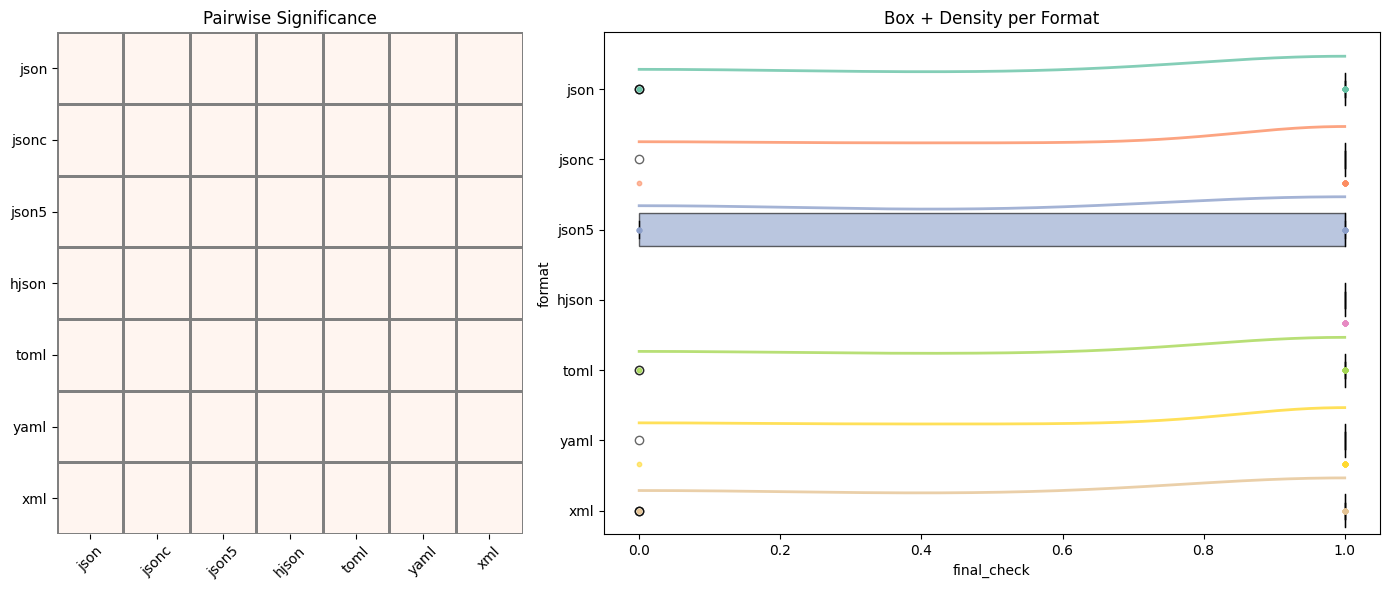

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  1.000000  0.000000     1.0    1    1
 json       18  0.833333  0.383482     1.0    0    1
 json5      16  0.687500  0.478714     1.0    0    1
 jsonc      15  0.933333  0.258199     1.0    0    1
 toml       16  0.875000  0.341565     1.0    0    1
 xml        16  0.812500  0.403113     1.0    0    1
 yaml       15  0.933333  0.258199     1.0    0    1,
 'overall_p': 0.19966650766370855,
 'effect_size': 0.07693012600229095,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [72]:
vis_box_comparasion(
    m_result_1,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_1 = compare_statistically(
    m_result_1,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_1

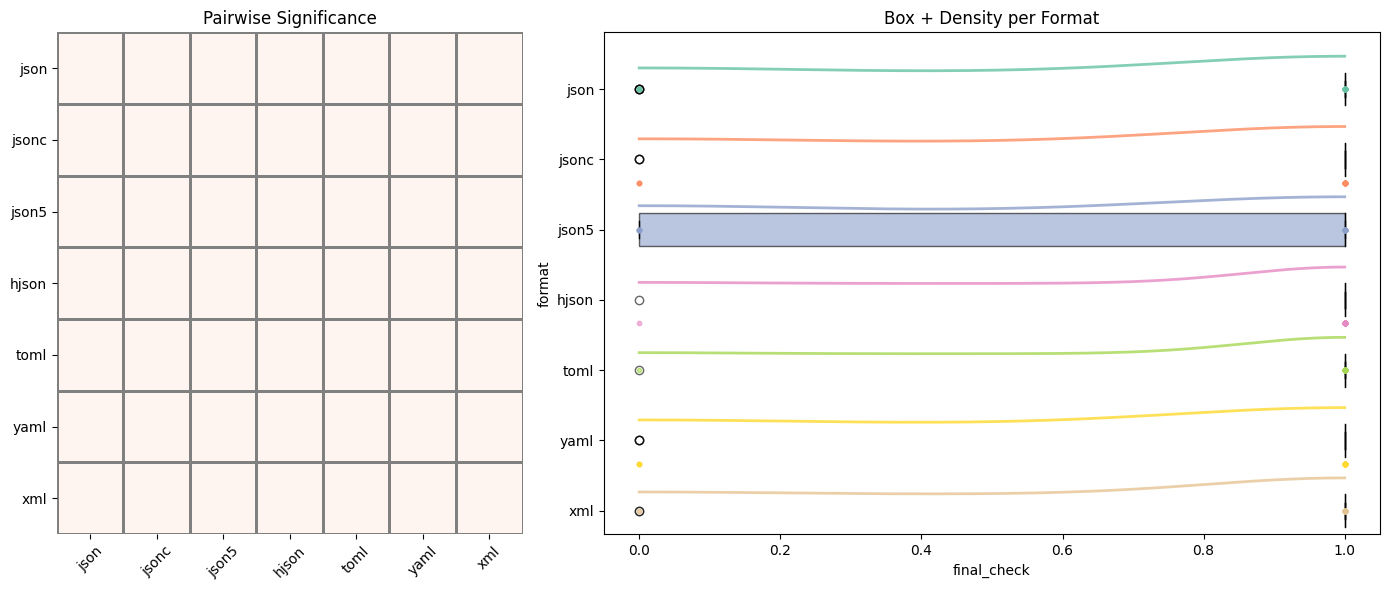

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  0.937500  0.250000     1.0    0    1
 json       18  0.777778  0.427793     1.0    0    1
 json5      16  0.687500  0.478714     1.0    0    1
 jsonc      15  0.800000  0.414039     1.0    0    1
 toml       16  0.937500  0.250000     1.0    0    1
 xml        16  0.875000  0.341565     1.0    0    1
 yaml       15  0.800000  0.414039     1.0    0    1,
 'overall_p': 0.47068625864853486,
 'effect_size': 0.05090863359114632,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [73]:
vis_box_comparasion(
    m_result_2,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_2 = compare_statistically(
    m_result_2,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_2

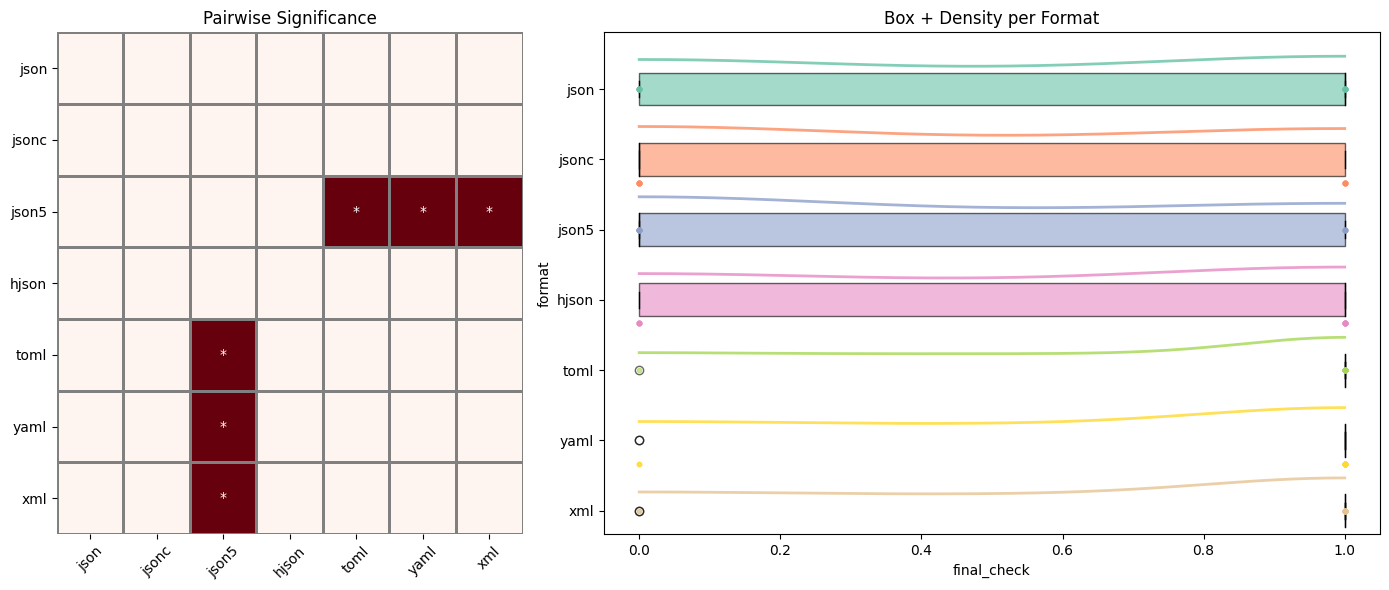

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  0.625000  0.500000     1.0    0    1
 json       18  0.555556  0.511310     1.0    0    1
 json5      16  0.375000  0.500000     0.0    0    1
 jsonc      15  0.466667  0.516398     0.0    0    1
 toml       16  0.937500  0.250000     1.0    0    1
 xml        16  0.875000  0.341565     1.0    0    1
 yaml       15  0.866667  0.351866     1.0    0    1,
 'overall_p': 0.0010328502251462635,
 'effect_size': 0.18881281281281276,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.9992        False   hjson vs json is not significant
 1   hjson  json5   0.6723        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.9514        False  hjson vs jsonc is not significant
 3   hjson   toml   0.4083

In [74]:
vis_box_comparasion(
    m_result_3,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_3 = compare_statistically(
    m_result_3,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_3

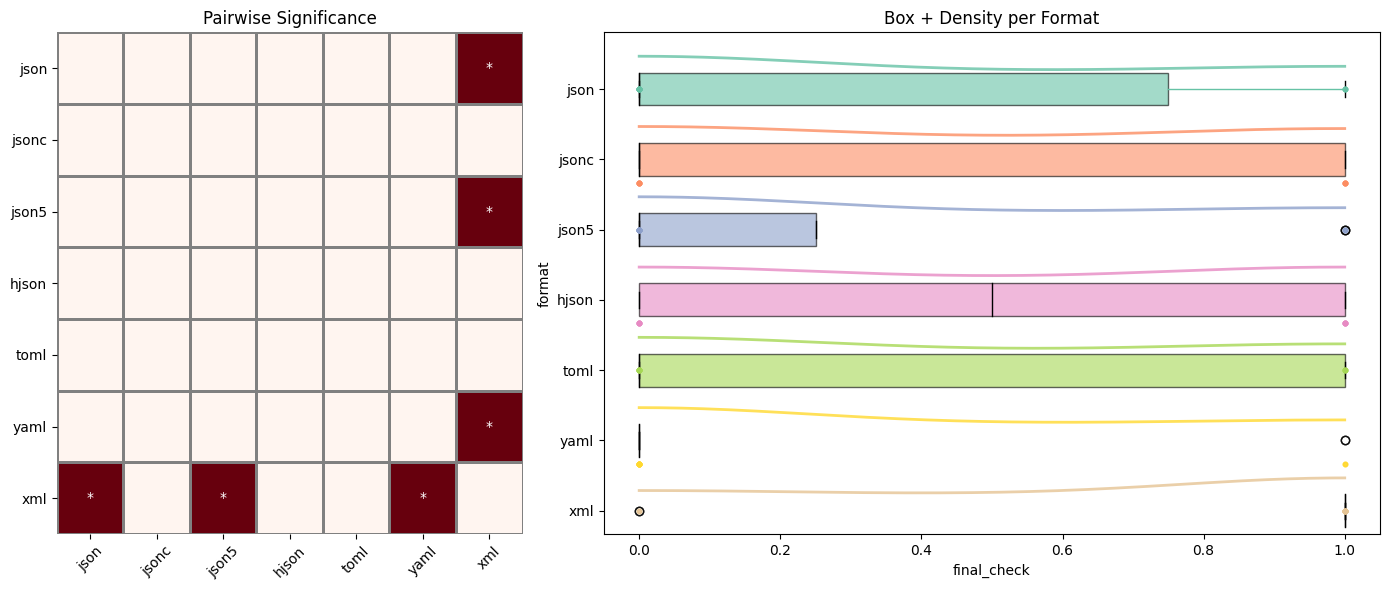

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      16  0.500000  0.516398     0.5    0    1
 json       18  0.277778  0.460889     0.0    0    1
 json5      16  0.250000  0.447214     0.0    0    1
 jsonc      15  0.466667  0.516398     0.0    0    1
 toml       16  0.375000  0.500000     0.0    0    1
 xml        16  0.812500  0.403113     1.0    0    1
 yaml       15  0.200000  0.414039     0.0    0    1,
 'overall_p': 0.0065110789399329275,
 'effect_size': 0.15402576489533013,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.8092        False   hjson vs json is not significant
 1   hjson  json5   0.7364        False  hjson vs json5 is not significant
 2   hjson  jsonc   1.0000        False  hjson vs jsonc is not significant
 3   hjson   toml   0.9884

In [75]:
vis_box_comparasion(
    m_result_4,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_4 = compare_statistically(
    m_result_4,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_4

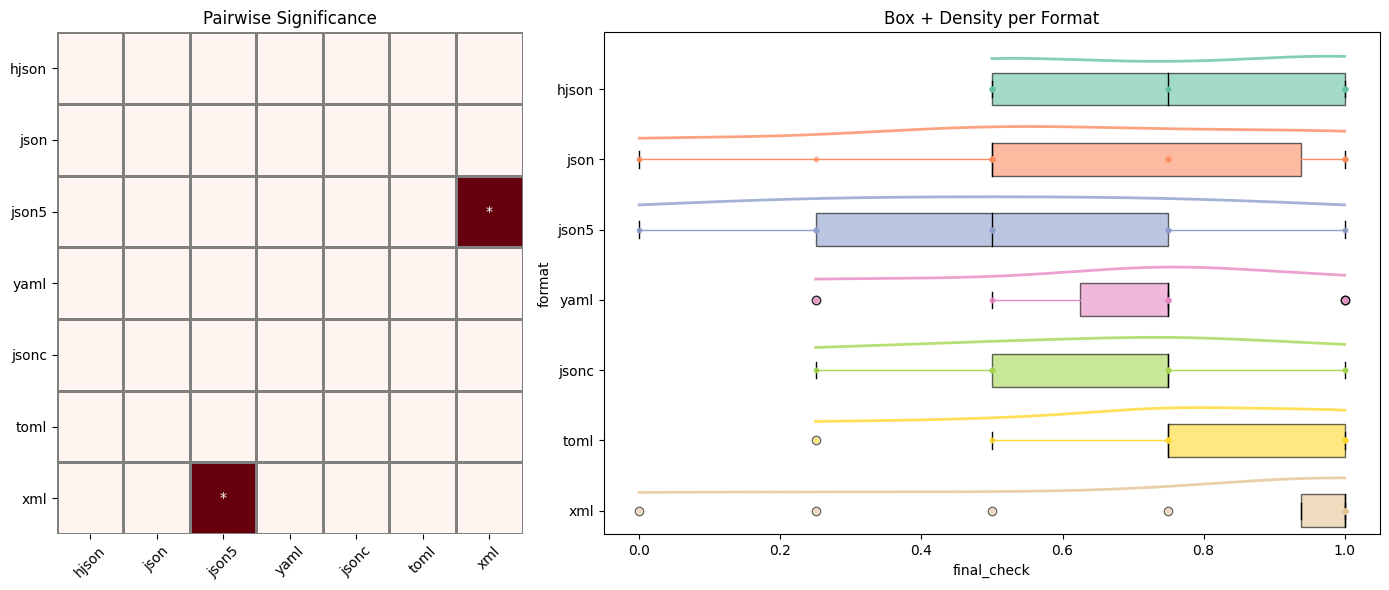

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median   min  max
 format                                              
 hjson      16  0.765625  0.232177    0.75  0.50  1.0
 json       18  0.611111  0.323381    0.50  0.00  1.0
 json5      16  0.500000  0.316228    0.50  0.00  1.0
 jsonc      15  0.666667  0.243975    0.75  0.25  1.0
 toml       16  0.781250  0.221265    0.75  0.25  1.0
 xml        16  0.843750  0.314576    1.00  0.00  1.0
 yaml       15  0.700000  0.235281    0.75  0.25  1.0,
 'overall_p': 0.012365358261861418,
 'effect_size': 0.14112342613341947,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.6581        False   hjson vs json is not significant
 1   hjson  json5   0.0994        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.9523        False  hjson vs jsonc is not significant
 3   hjson   toml 

In [76]:
vis_box_comparasion(
    m_overall_only,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_overall = compare_statistically(
    m_overall_only,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_overall

### similarity

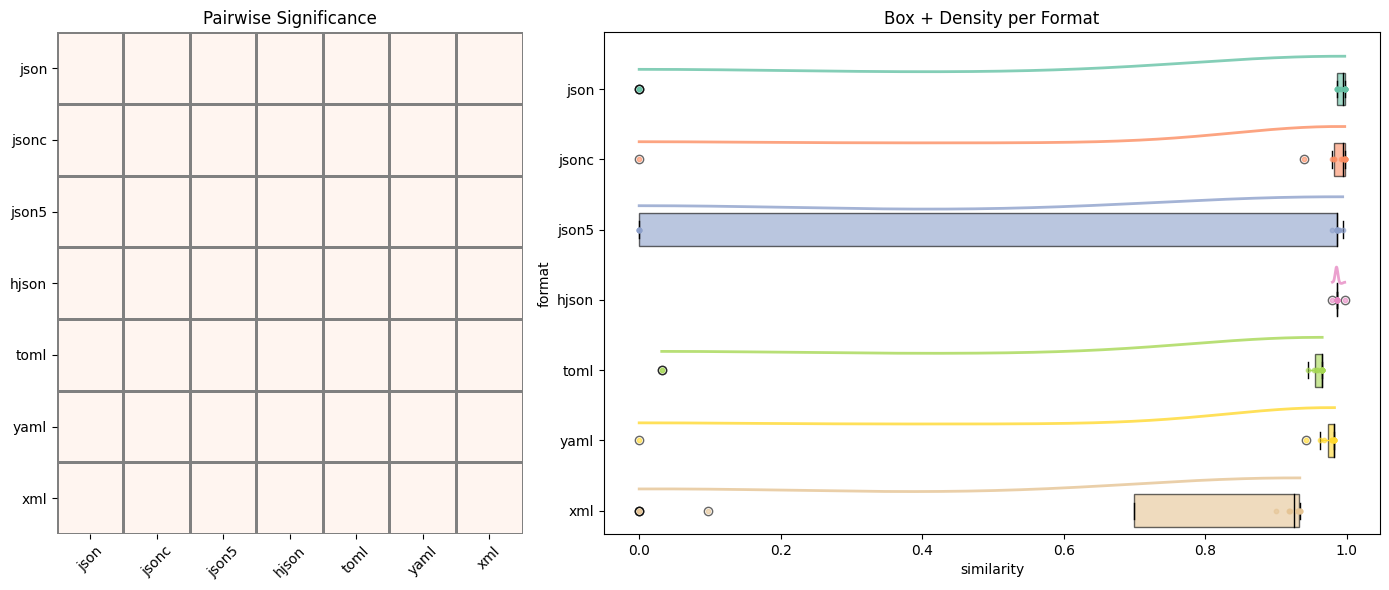

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      16  0.985870  0.003326  0.985507  0.979710  0.997101
 json       18  0.827536  0.380846  0.994203  0.000000  0.997101
 json5      16  0.678080  0.472163  0.985507  0.000000  0.994203
 jsonc      15  0.922899  0.255756  0.994203  0.000000  0.997101
 toml       16  0.845652  0.317715  0.965217  0.031884  0.965217
 xml        16  0.700901  0.404190  0.925996  0.000000  0.933586
 yaml       15  0.911498  0.252411  0.982609  0.000000  0.982609,
 'overall_p': 0.08906326525711261,
 'effect_size': 0.09753478353647096,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [77]:
vis_box_comparasion(
    m_result_1,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_1 = compare_statistically(
    m_result_1,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_1

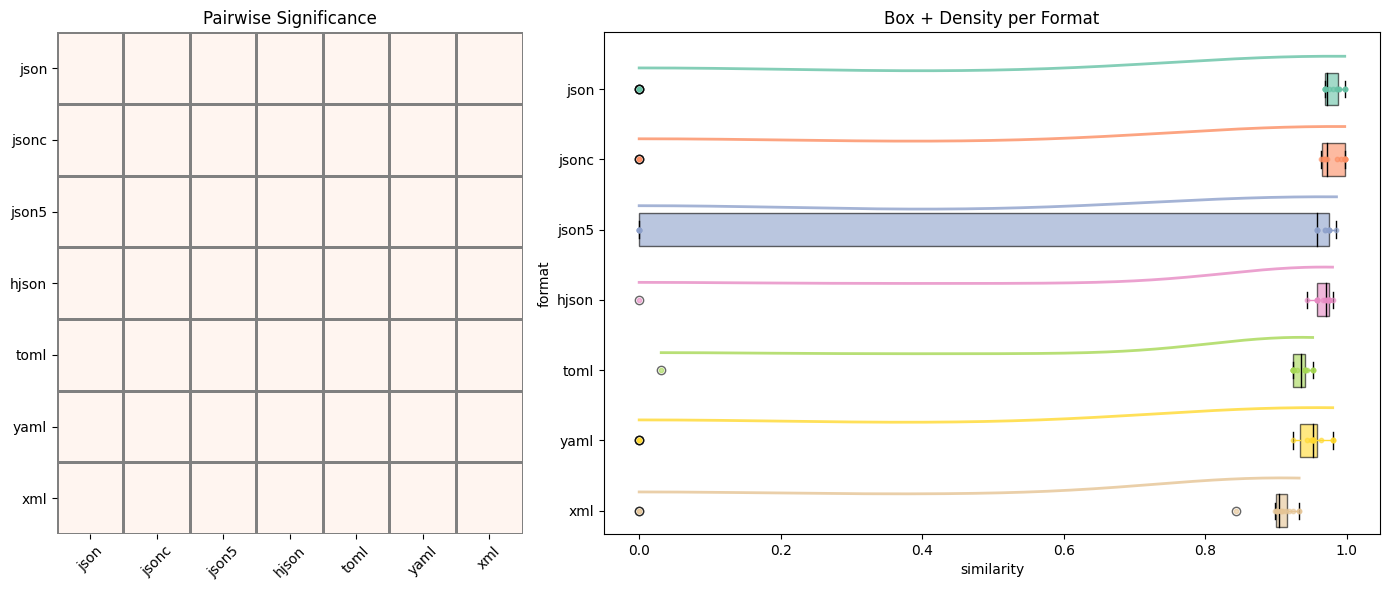

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      16  0.906469  0.241920  0.970093  0.000000  0.979943
 json       18  0.763302  0.419952  0.971671  0.000000  0.997167
 json5      16  0.665702  0.463601  0.957507  0.000000  0.985507
 jsonc      15  0.786780  0.407398  0.971671  0.000000  0.997167
 toml       16  0.878895  0.226337  0.934844  0.031161  0.951841
 xml        16  0.793107  0.310250  0.903738  0.000000  0.932710
 yaml       15  0.765250  0.396339  0.951841  0.000000  0.980170,
 'overall_p': 0.5927345025078621,
 'effect_size': 0.04231053048589078,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [78]:
vis_box_comparasion(
    m_result_2,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_2 = compare_statistically(
    m_result_2,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_2

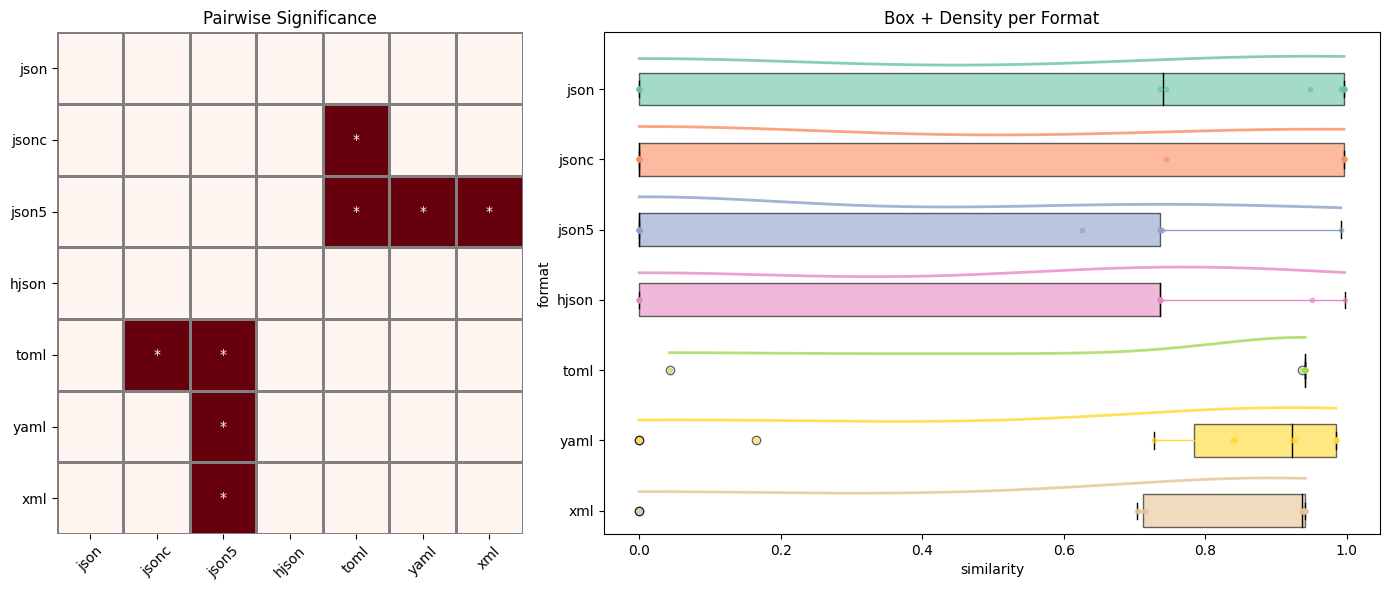

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      16  0.489855  0.399588  0.736232  0.000000  0.997101
 json       18  0.522084  0.486663  0.740550  0.000000  0.996078
 json5      16  0.285326  0.386826  0.000000  0.000000  0.991304
 jsonc      15  0.448089  0.499722  0.000000  0.000000  0.996078
 toml       16  0.884804  0.224447  0.941176  0.043137  0.941176
 xml        16  0.764581  0.314867  0.936387  0.000000  0.941476
 yaml       15  0.744573  0.366701  0.922794  0.000000  0.984314,
 'overall_p': 0.0003582496527293873,
 'effect_size': 0.20761136642651193,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   1.0000        False   hjson vs json is not significant
 1   hjson  json5   0.7625        False  hjson vs json5 is not signi

In [79]:
vis_box_comparasion(
    m_result_3,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_3 = compare_statistically(
    m_result_3,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_3

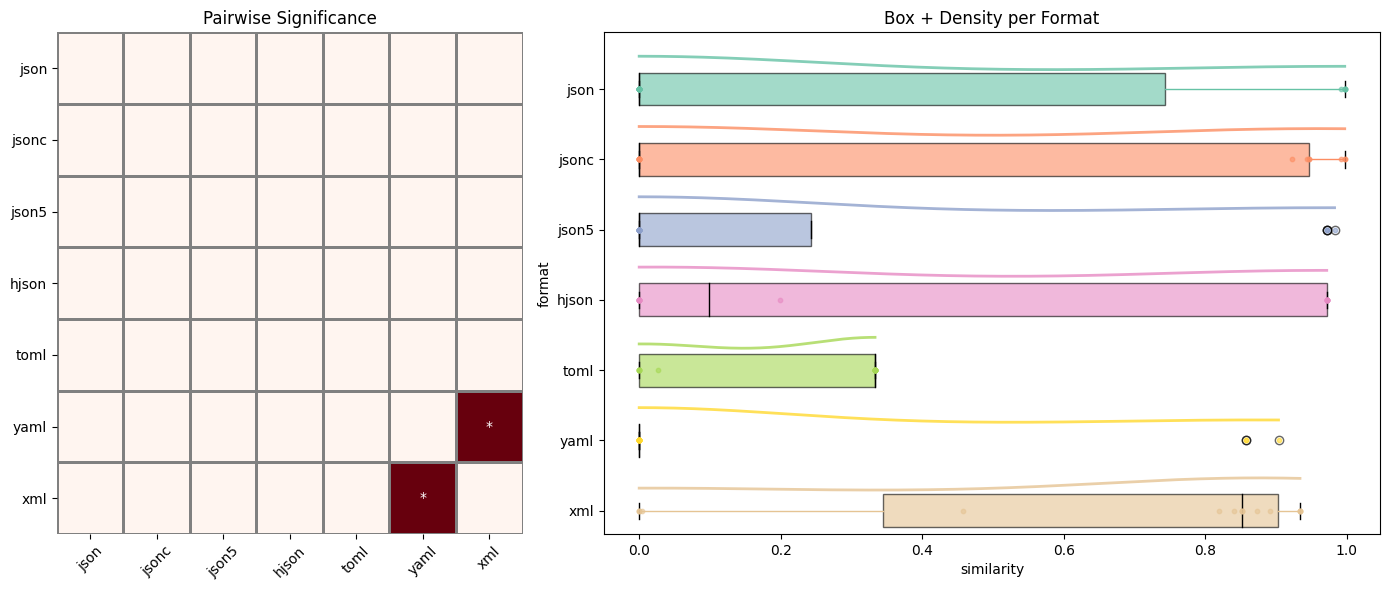

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median  min       max
 format                                                    
 hjson      16  0.437547  0.488968  0.099246  0.0  0.971751
 json       18  0.276679  0.459068  0.000000  0.0  0.997175
 json5      16  0.243629  0.435824  0.000000  0.0  0.982808
 jsonc      15  0.449660  0.497987  0.000000  0.0  0.997175
 toml       16  0.209983  0.164585  0.333333  0.0  0.333333
 xml        16  0.636079  0.394691  0.851376  0.0  0.933945
 yaml       15  0.174576  0.361546  0.000000  0.0  0.903581,
 'overall_p': 0.024033026833551407,
 'effect_size': 0.12720477933851232,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.9178        False   hjson vs json is not significant
 1   hjson  json5   0.8400        False  hjson vs json5 is not significant
 2   hjson  jsonc   1.0000        False

In [80]:
vis_box_comparasion(
    m_result_4,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_4 = compare_statistically(
    m_result_4,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_4

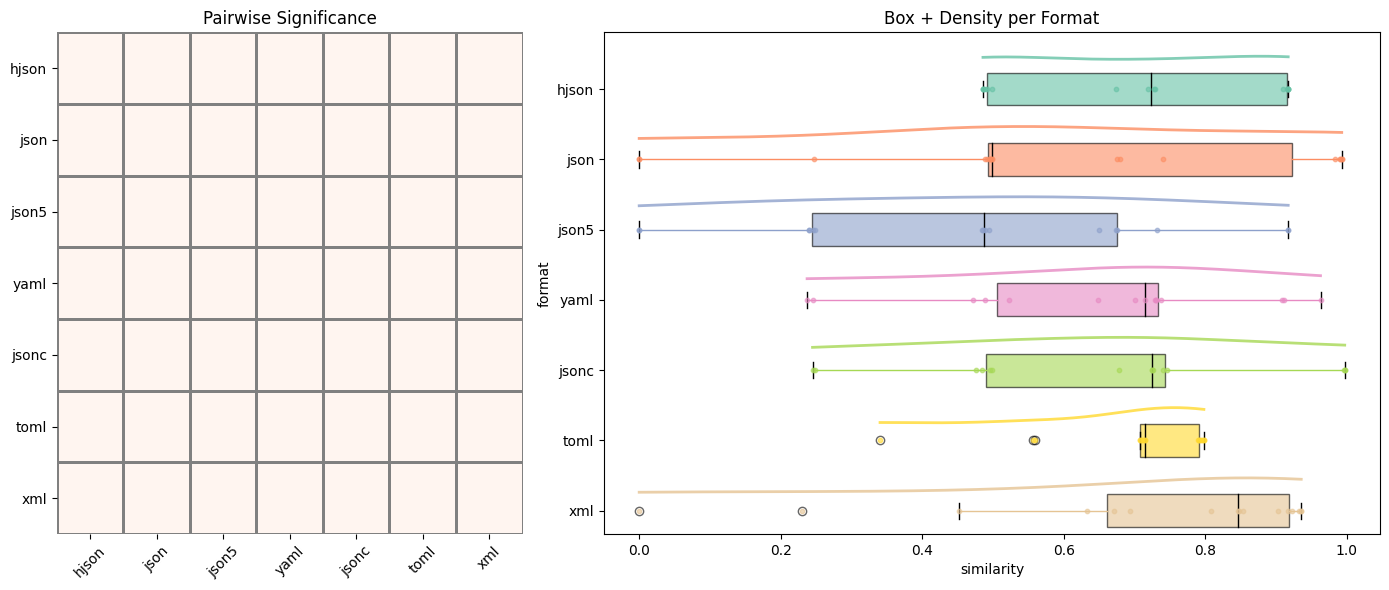

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      16  0.704935  0.190925  0.723205  0.485754  0.916999
 json       18  0.597401  0.317350  0.498431  0.000000  0.992635
 json5      16  0.468184  0.286696  0.487170  0.000000  0.916999
 jsonc      15  0.651857  0.242725  0.725152  0.244928  0.996881
 toml       16  0.704834  0.124318  0.714317  0.340314  0.797892
 xml        16  0.723667  0.276839  0.846779  0.000000  0.935429
 yaml       15  0.648974  0.219395  0.715230  0.237252  0.962668,
 'overall_p': 0.06257918632319684,
 'effect_size': 0.10589094922104035,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [81]:
vis_box_comparasion(
    m_overall_only,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_overall = compare_statistically(
    m_overall_only,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_overall